# ETS MARL — Multi-Agent RL for EU Emissions Trading

**Technology-Specific Energy Mix | Real CapEx | Construction Queues | PPO**

This notebook is a testing playground for the ETS MARL simulation.
It clones the repository, installs dependencies, runs tests, trains agents,
and visualizes results — all within Google Colab.

---

### Model Overview (current)
- **8 learning agents** representing European electricity utilities (10 TWh/year each)
  - 4 archetypes × 2 replicas: coal-heavy, gas-dominant, mixed, near-green
- **5 technologies**: Coal, Gas CCGT, Onshore Wind, Offshore Wind, Solar PV
- **Real-data-grounded** CapEx (IRENA 2024), emission factors (IPCC AR5), deployment delays
- **EU ETS mechanics**: uniform-price auction, MSR, LRF (Fit for 55), 100% auctioning
- **PPO agents** with two-phase decisions (auction + secondary market)
- **Greening-only** constraint: agents can only add renewables, fossil can only decrease
- **MAC fuel-switching**: automatic coal→gas dispatch switching at marginal cost (€65/tCO₂)
- **Electricity revenue**: margin-based reward (output × electricity price)
- **Carry-forward obligations**: non-compliance shortfall added to next year's surrender

## 1. Setup — Clone Repository & Install Dependencies

In [1]:
import os, sys
from pathlib import Path

def _is_project_root(path: str) -> bool:
    return (os.path.isdir(os.path.join(path, "src")) and
            os.path.isdir(os.path.join(path, "configs")))

# Local execution: look for project root relative to notebook location
_local_candidates = [
    "..",             # notebook is in notebooks/ subfolder
    ".",              # notebook opened from project root
    os.path.join("..", ".."),
]
_colab_candidates = [
    os.path.join("Thesis-Energy-Auction", "ets_marl_happo_current"),
    "Thesis-Energy-Auction",
]

_found = _is_project_root(".")
if not _found:
    for _c in _local_candidates + _colab_candidates:
        if _is_project_root(_c):
            os.chdir(_c)
            _found = True
            break
if not _found:
    raise FileNotFoundError(
        f"Cannot find project root (needs src/ + configs/).\n"
        f"CWD: {os.getcwd()}  |  Contents: {os.listdir('.')}"
    )

PROJECT_ROOT = Path.cwd().resolve()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"
RESULTS_DIR = PROJECT_ROOT / "results"
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Working directory: {PROJECT_ROOT}")
print(f"Config path: {CONFIG_PATH}")


Working directory: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction
Config path: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\configs\default.yaml


In [2]:
# Local execution: dependencies should already be installed in your venv
# If not, run: pip install -r requirements.txt
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print(f'Apple Silicon MPS available')


PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Run Tests — Verify Everything Works

In [3]:
!python -m pytest tests/ -v

============================= test session starts =============================
platform win32 -- Python 3.13.12, pytest-9.0.2, pluggy-1.6.0 -- c:\Users\danie\AppData\Local\Programs\Python\Python313\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction
configfile: pyproject.toml
collecting ... collected 298 items

tests/test_anchors.py::TestAuctionAnchors::test_anchored_price_near_target PASSED [  0%]
tests/test_anchors.py::TestAuctionAnchors::test_anchored_qty_near_target PASSED [  0%]
tests/test_anchors.py::TestAuctionAnchors::test_anchored_invest_frac PASSED [  1%]
tests/test_anchors.py::TestAuctionAnchors::test_no_anchors_gives_midpoint PASSED [  1%]
tests/test_anchors.py::TestAuctionAnchors::test_anchors_within_bounds PASSED [  1%]
tests/test_anchors.py::TestSecondaryAnchors::test_anchored_price_abs PASSED [  2%]
tests/test_anchors.py::TestSecondaryAnchors::test_anchored_qty_neutral PASSED [  2%]
tests/test_anchors.

## 3. Explore the Environment

In [4]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.environment.ets_environment import ETSEnvironment
from src.environment.company import TECH_NAMES

with open(CONFIG_PATH, encoding="utf-8") as f:
    config = yaml.safe_load(f)

env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset()

print("=== Environment Summary ===")
print(f"Agents: {env.n_agents}")
print(f"Years: {env.n_years}")
print(f"Technologies: {TECH_NAMES}")
print(f"Phase 1 obs dim: {obs1.shape[1]}")
print(f"Initial cap: {env.cap_schedule.get_cap(0):.2f} Mt")
print()

tech_names = config["technologies"]["names"]
for i, c in enumerate(env.companies):
    mix_str = " | ".join([f"{tech_names[t]}: {c.mix[t]*100:.0f}%" for t in range(5)])
    print(f"A{i+1}: {mix_str}")
    print(f"     Emissions: {c.compute_emissions():.2f} Mt | "
          f"Green: {c.green_frac*100:.0f}% | "
          f"Op. Cost: {c.compute_operational_cost():.0f} M€/yr | "
          f"Avg EF: {c.weighted_emission_factor:.3f} tCO2/MWh")

Market calibration: 8 participants, emissions=20.7 Mt, cap=23.2 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.86, A2=1.91, A3=1.65, A4=1.53, A5=1.03, A6=1.19, A7=0.74, A8=0.88
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.78 MtCO2.
=== Environment Summary ===
Agents: 8
Years: 12
Technologies: ['coal', 'gas', 'onshore_wind', 'offshore_wind', 'solar']
Phase 1 obs dim: 85
Initial cap: 23.23 Mt

A1: coal: 22% | gas: 30% | onshore_wind: 21% | offshore_wind: 15% | solar: 12%
     Emissions: 3.37 Mt | Green: 48% | Op. Cost: 441 M€/yr | Avg EF: 0.337 tCO2/MWh
A2: coal: 16% | gas: 30% | onshore_wind: 22% | offshore_wind: 15% | solar: 16%
     Emissions: 2.94 Mt | Green: 54% | Op. Cost: 408 M€/yr | Avg EF: 0.294 tCO2/MWh
A3: coal: 13% | gas: 35% | onshore_wind: 25% | offshor

## 4. Run a Random-Policy Episode (Baseline)

In [5]:
env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset(seed=42)
n_agents = env.n_agents
rng = np.random.default_rng(42)

aq = config["auction"]
inv = config["investment"]
tr = config.get("trading", {})
sec_price_min = float(tr.get("sec_price_min", 30.0))
sec_price_max = float(tr.get("sec_price_max_mult", 2.0)) * float(config["penalty"]["rate"])
year_data = []

for year in range(config["simulation"]["n_years"]):
    auction_actions = rng.uniform(
        [aq["price_min"], aq.get("qty_mult_low", 0.3), 0.0, -1.0, -1.0, -1.0],
        [aq["price_max"], aq.get("qty_mult_high", 2.0), inv["max_invest_frac"], 1.0, 1.0, 1.0],
        size=(n_agents, 6)
    ).astype(np.float32)
    obs2, _ = env.step_auction(auction_actions)

    secondary_actions = rng.uniform(
        [sec_price_min, -aq["quantity_max"]],
        [sec_price_max, aq["quantity_max"]],
        size=(n_agents, 2)
    ).astype(np.float32)
    obs1, rewards, terminated, _, info = env.step_secondary(secondary_actions)
    log = info["year_log"]

    row = {"year": year, "cap": log["cap"], "price": log["clearing_price"]}
    for i in range(n_agents):
        row[f"green_A{i+1}"] = log["green_fracs"][i]
        row[f"emissions_A{i+1}"] = log["emissions"][i]
        row[f"reward_A{i+1}"] = rewards[i]
    year_data.append(row)
    if terminated:
        break

df = pd.DataFrame(year_data)
print(df[["year", "cap", "price"]].to_string(index=False))

Market calibration: 8 participants, emissions=20.7 Mt, cap=23.2 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.91, A2=1.76, A3=1.75, A4=1.72, A5=1.19, A6=1.02, A7=0.75, A8=0.69
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.78 MtCO2.
 year       cap      price
    0 23.227680 176.992355
    1 22.228890  78.060715
    2 21.206872  66.197609
    3 20.184854  70.165375
    4 19.162836  53.912388
    5 18.140818 187.433609
    6 17.118800 122.153694
    7 16.096782  63.802807
    8 15.074764  56.391422
    9 14.052746  66.520844
   10 13.030728 115.095024
   11 12.008711 113.284302


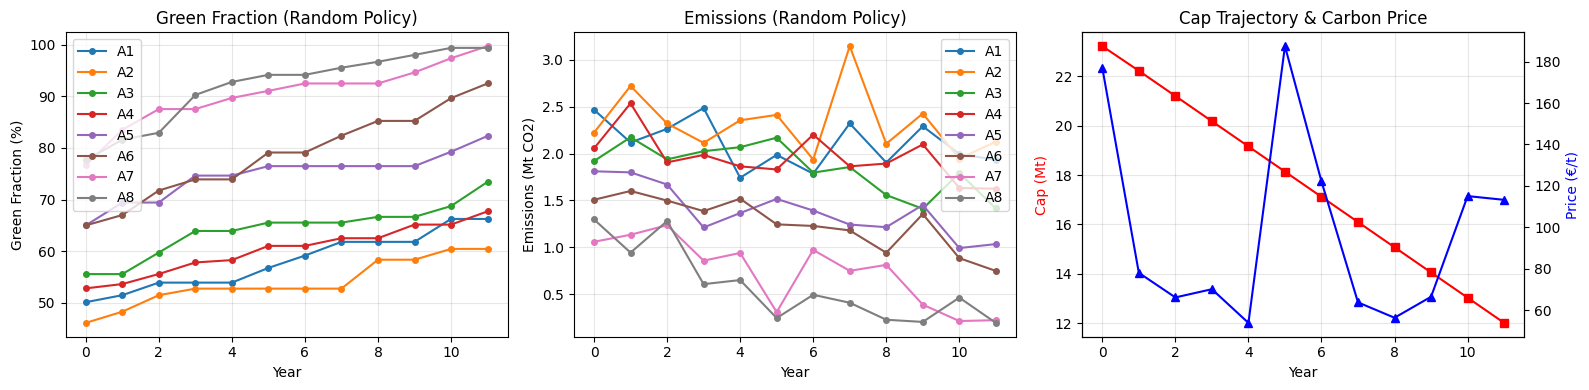

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
for i in range(n_agents):
    ax.plot(df['year'], df[f'green_A{i+1}'] * 100, label=f'A{i+1}', marker='o', ms=4)
ax.set_xlabel('Year'); ax.set_ylabel('Green Fraction (%)')
ax.set_title('Green Fraction (Random Policy)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for i in range(n_agents):
    ax.plot(df['year'], df[f'emissions_A{i+1}'], label=f'A{i+1}', marker='o', ms=4)
ax.set_xlabel('Year'); ax.set_ylabel('Emissions (Mt CO2)')
ax.set_title('Emissions (Random Policy)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(df['year'], df['cap'], label='Cap (Mt)', marker='s', color='red')
ax2 = ax.twinx()
ax2.plot(df['year'], df['price'], label='Price (\u20ac/t)', marker='^', color='blue')
ax.set_xlabel('Year'); ax.set_ylabel('Cap (Mt)', color='red')
ax2.set_ylabel('Price (\u20ac/t)', color='blue')
ax.set_title('Cap Trajectory & Carbon Price'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 5. Train PPO Agents (Short Run)

In [7]:
import copy
from scripts.train import train_one_seed

train_config = copy.deepcopy(config)
train_config["simulation"]["n_episodes"] = 1500
train_config["logging"]["log_interval"] = 50
train_config["logging"]["save_interval"] = 100
train_config["logging"]["snapshot_interval"] = 500  # save log snapshots every 500 episodes

train_one_seed(train_config, seed=42)



Training — seed 42, 8 learning agents, HAPPO (sequential update, centralized critic), two-phase
Carry-forward:  | Clipped Gaussian | ε-greedy 25%→5%
PPO profile: short-run (threshold>20000 episodes) | lr=0.0002 | entropy_final=0.03 | episodes_per_update=8

════════════════════════════════════════════════════════════════════════════════════════════════════
  TRAINING CONSOLE — FIELD GUIDE
════════════════════════════════════════════════════════════════════════════════════════════════════

  ┌─ CONTROL PLANE
  │  Ep / elapsed / ETA    Episode number · wall-clock time · estimated remaining
  │  ent / shp / ε         Entropy coef · shaping weight · ε-greedy rate
  │  [ENT-DECAY]           Entropy coefficient is being annealed down
  │  [cyc=Ax]              Soft cycling — only agent Ax updates its actor this interval
  │  [WARMUP]              Critic-only warmup phase (actor frozen)

  ┌─ MARKET TRAJECTORY  (one value per simulated year, oldest → newest)
  │  Price    Auction clearing pri

## 6. Quick Results Check

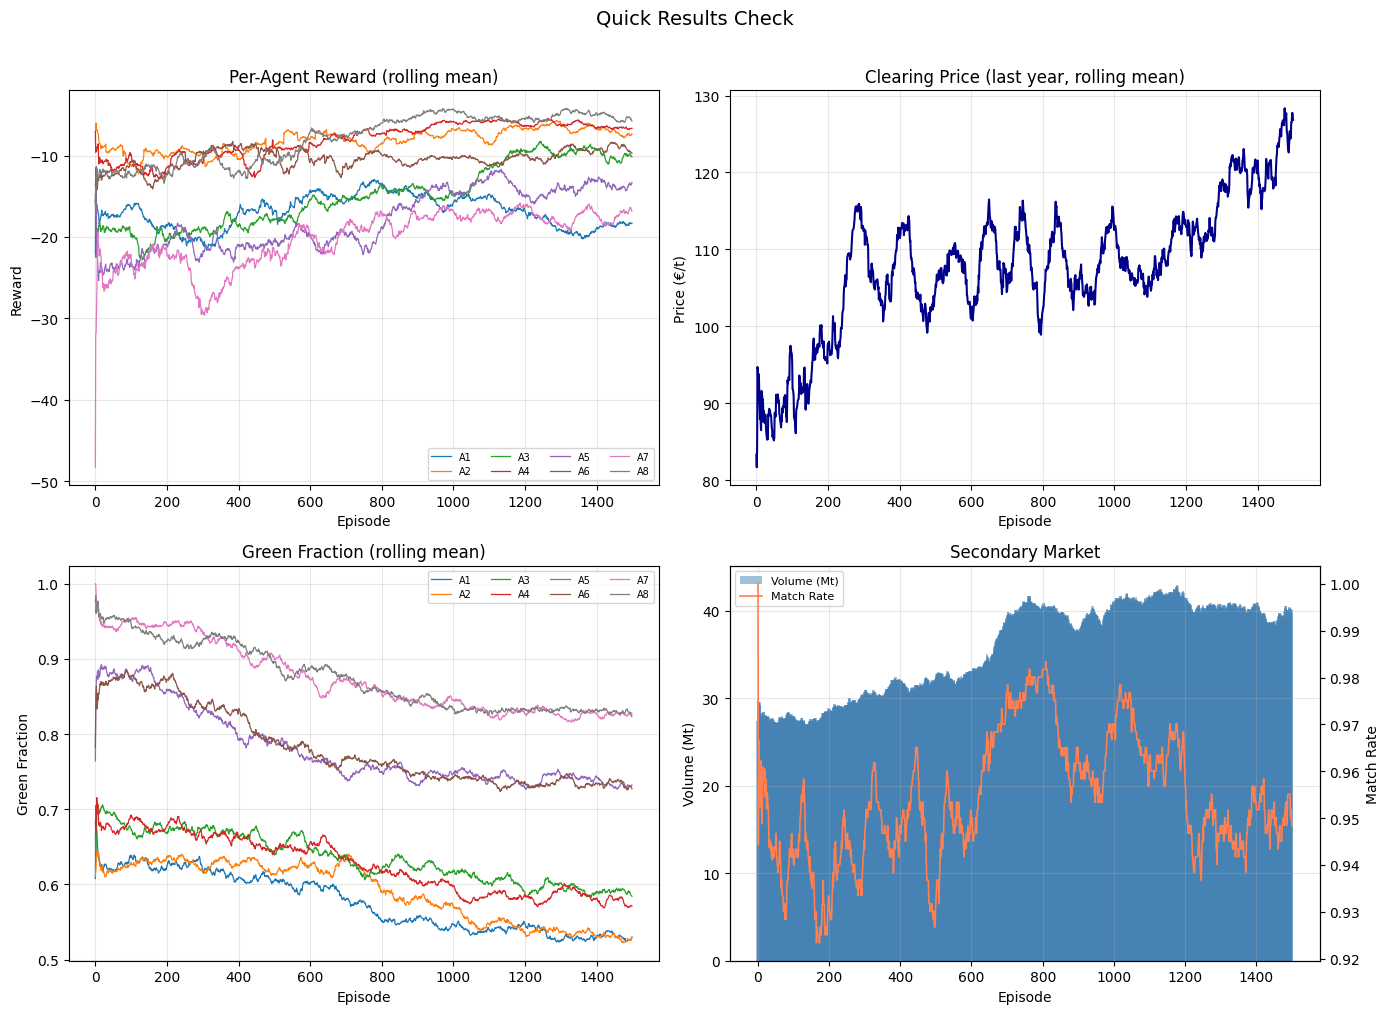

In [8]:
ep_df = pd.read_csv('results/training_log_s42.csv')
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']
agent_colors = [plt.cm.tab10(i) for i in range(n_agents)]
ROLL = 50

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'reward_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], label=f'A{i+1}', lw=0.9)
ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
ax.set_title('Per-Agent Reward (rolling mean)'); ax.legend(fontsize=7, ncol=4); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(ROLL, min_periods=1).mean(), color='darkblue')
ax.set_xlabel('Episode'); ax.set_ylabel('Price (\u20ac/t)')
ax.set_title('Clearing Price (last year, rolling mean)'); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'green_frac_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], label=f'A{i+1}', lw=0.9)
ax.set_xlabel('Episode'); ax.set_ylabel('Green Fraction')
ax.set_title('Green Fraction (rolling mean)'); ax.legend(fontsize=7, ncol=4); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.bar(ep_df['episode'], ep_df['secondary_volume'].rolling(ROLL, min_periods=1).mean(),
       width=max(1, len(ep_df)//200), alpha=0.5, color='steelblue', label='Volume (Mt)')
ax2 = ax.twinx()
ax2.plot(ep_df['episode'], ep_df['secondary_match_rate'].rolling(ROLL, min_periods=1).mean(),
         color='coral', lw=1.2, label='Match Rate')
ax.set_xlabel('Episode'); ax.set_ylabel('Volume (Mt)'); ax2.set_ylabel('Match Rate')
ax.set_title('Secondary Market'); ax.grid(True, alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Quick Results Check', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 7. Full Training Run

Run for more episodes to allow agents to develop meaningful strategies.
The analysis sections below are designed for this longer run.

In [9]:
import copy

full_config = copy.deepcopy(config)
full_config["simulation"]["n_episodes"] = 70000
full_config["logging"]["log_interval"] = 100
full_config["logging"]["results_dir"] = "results/"
full_config["logging"]["snapshot_interval"] = 2500  # save CSV snapshots every 2500 episodes

train_one_seed(full_config, seed=520)



Training — seed 520, 8 learning agents, HAPPO (sequential update, centralized critic), two-phase
Carry-forward:  | Clipped Gaussian | ε-greedy 25%→5%
PPO profile: long-run (threshold>20000 episodes) | lr=0.0003 | entropy_final=0.025 | episodes_per_update=16

════════════════════════════════════════════════════════════════════════════════════════════════════
  TRAINING CONSOLE — FIELD GUIDE
════════════════════════════════════════════════════════════════════════════════════════════════════

  ┌─ CONTROL PLANE
  │  Ep / elapsed / ETA    Episode number · wall-clock time · estimated remaining
  │  ent / shp / ε         Entropy coef · shaping weight · ε-greedy rate
  │  [ENT-DECAY]           Entropy coefficient is being annealed down
  │  [cyc=Ax]              Soft cycling — only agent Ax updates its actor this interval
  │  [WARMUP]              Critic-only warmup phase (actor frozen)

  ┌─ MARKET TRAJECTORY  (one value per simulated year, oldest → newest)
  │  Price    Auction clearing p

---
# Post-Training Analysis

> **Run the data-loading cell below first**, then jump to either part.

| Part | Purpose |
|------|---------|
| **Part I — Diagnostic** | Is the *simulation itself* realistic and mechanically correct? |
| **Part II — Analytical** | What *strategies* did the agents learn? |

In [10]:
# ── Load & Prepare Data (run this first) ─────────────────────────────
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

def _resolve_results_dir(seed=42):
    train_name = f"training_log_s{seed}.csv"
    year_name = f"year_log_s{seed}.csv"

    candidates = []
    if "RESULTS_DIR" in globals():
        candidates.append(Path(RESULTS_DIR))
    if "PROJECT_ROOT" in globals():
        candidates.append(Path(PROJECT_ROOT) / "results")
    candidates.extend([
        Path("results"),
        Path("../results"),
        Path("ets_marl_happo_current/results"),
        Path("../ets_marl_happo_current/results"),
    ])

    # de-duplicate while preserving order
    seen = set()
    unique_candidates = []
    for d in candidates:
        dr = d.resolve()
        if dr not in seen:
            seen.add(dr)
            unique_candidates.append(dr)

    for d in unique_candidates:
        if (d / train_name).exists() and (d / year_name).exists():
            return d

    searched = "\n".join(str(d) for d in unique_candidates)
    raise FileNotFoundError(
        f"Could not find {train_name} and {year_name}.\n"
        f"Current working directory: {Path.cwd()}\n"
        f"Searched:\n{searched}"
    )

SEED = 520
results_dir = _resolve_results_dir(SEED)
ep_df = pd.read_csv(results_dir / f"training_log_s{SEED}.csv")
yr_df = pd.read_csv(results_dir / f"year_log_s{SEED}.csv")

if "config" in globals() and "companies" in config:
    n_agents = int(config["companies"]["n_agents"])
else:
    # Fallback if setup cells were not run: infer from reward columns.
    n_agents = len([c for c in ep_df.columns if c.startswith("reward_A")])

sns.set_style("whitegrid")
agent_colors = [plt.cm.tab10(i) for i in range(n_agents)]
_base_archetypes = ["Coal-Heavy", "Gas-Dominant", "Mixed", "Near-Green"]
agent_labels = []
for arch in _base_archetypes:
    for _ in range(n_agents // 4):
        agent_labels.append(f"A{len(agent_labels)+1} ({arch})")
while len(agent_labels) < n_agents:
    agent_labels.append(f"A{len(agent_labels)+1}")

LAST_N = min(200, max(1, len(ep_df) // 4))
last_episodes = ep_df["episode"].unique()[-LAST_N:]
recent_ep = ep_df[ep_df["episode"].isin(last_episodes)].copy()
recent_yr = yr_df[yr_df["episode"].isin(last_episodes)].copy()
ROLL = 50

n_years_per_ep = yr_df.groupby("episode")["year"].count().mode().iloc[0]

print(f"Loaded data from: {results_dir}")
print(f"Loaded {len(ep_df)} episodes, {len(yr_df)} year-rows")
print(f"Converged window: last {LAST_N} episodes  |  {n_years_per_ep} years/episode")
print(f"Agents: {n_agents}  |  Archetypes: {agent_labels}")

Loaded data from: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results
Loaded 70000 episodes, 840000 year-rows
Converged window: last 200 episodes  |  12 years/episode
Agents: 8  |  Archetypes: ['A1 (Coal-Heavy)', 'A2 (Coal-Heavy)', 'A3 (Gas-Dominant)', 'A4 (Gas-Dominant)', 'A5 (Mixed)', 'A6 (Mixed)', 'A7 (Near-Green)', 'A8 (Near-Green)']


---
# Part I — Diagnostic Analysis

> *Does the simulation produce economically plausible outcomes?*
>
> We check: price levels, cap-emissions alignment, MSR/TNAC dynamics,
> auction & secondary market mechanics, stochastic shocks (P5/P6),
> and training convergence.

### D1. Training Convergence

Check that neural networks are learning stably:
- Losses decreasing
- Entropy decay triggered at the right time
- Rewards stabilizing

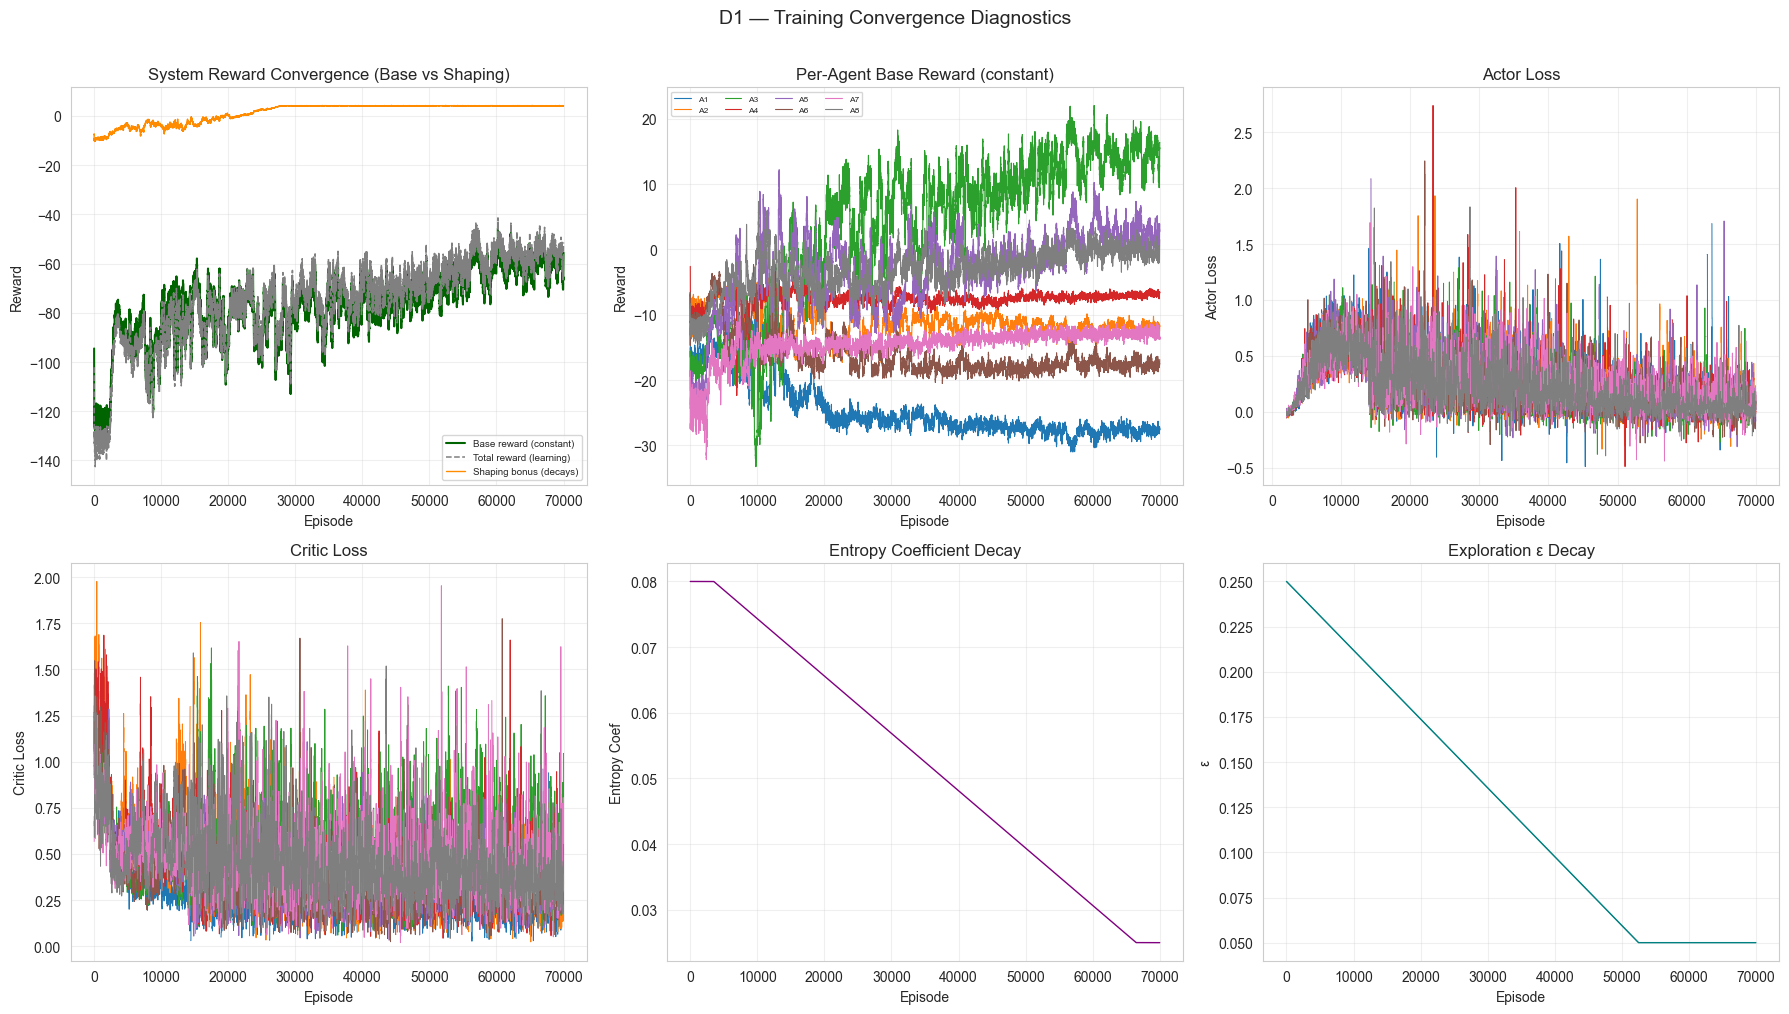

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Support both new (v6.4+) and legacy reward logs
reward_cols_total = [f'reward_A{i+1}' for i in range(n_agents) if f'reward_A{i+1}' in ep_df.columns]
reward_cols_base = [f'reward_base_A{i+1}' for i in range(n_agents) if f'reward_base_A{i+1}' in ep_df.columns]
reward_cols_shaping = [f'reward_shaping_A{i+1}' for i in range(n_agents) if f'reward_shaping_A{i+1}' in ep_df.columns]

# 1 — System reward trajectory
ax = axes[0, 0]
if reward_cols_total:
    total_rew = ep_df[reward_cols_total].sum(axis=1)
    total_roll = total_rew.rolling(ROLL, min_periods=1).mean()

    if reward_cols_base:
        total_base = ep_df[reward_cols_base].sum(axis=1)
        base_roll = total_base.rolling(ROLL, min_periods=1).mean()
        ax.plot(ep_df['episode'], base_roll, color='darkgreen', lw=1.5, label='Base reward (constant)')
        ax.plot(ep_df['episode'], total_roll, color='gray', lw=1.1, ls='--', label='Total reward (learning)')

        if reward_cols_shaping:
            total_shaping = ep_df[reward_cols_shaping].sum(axis=1)
            shape_roll = total_shaping.rolling(ROLL, min_periods=1).mean()
            ax.plot(ep_df['episode'], shape_roll, color='darkorange', lw=1.0, label='Shaping bonus (decays)')
        ax.legend(fontsize=7)
        ax.set_title('System Reward Convergence (Base vs Shaping)')
    else:
        ax.plot(ep_df['episode'], total_roll, color='darkgreen', lw=1.2)
        ax.set_title('System Reward Convergence (Total only)')
else:
    ax.text(0.5, 0.5, 'Reward columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Episode'); ax.set_ylabel('Reward'); ax.grid(True, alpha=0.3)

# 2 — Per-agent reward (constant trajectory when available)
ax = axes[0, 1]
per_agent_cols = reward_cols_base if reward_cols_base else reward_cols_total
for i in range(n_agents):
    col = f'reward_base_A{i+1}' if reward_cols_base else f'reward_A{i+1}'
    if col in ep_df.columns:
        ax.plot(ep_df['episode'], ep_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
if reward_cols_base:
    ax.set_title('Per-Agent Base Reward (constant)')
else:
    ax.set_title('Per-Agent Reward (total)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Actor loss
ax = axes[0, 2]
for i in range(n_agents):
    col = f'actor_loss_A{i+1}'
    if col in ep_df.columns:
        vals = ep_df[col].replace(0, np.nan).rolling(ROLL, min_periods=1).mean()
        ax.plot(ep_df['episode'], vals, color=agent_colors[i], lw=0.7)
ax.set_xlabel('Episode'); ax.set_ylabel('Actor Loss')
ax.set_title('Actor Loss'); ax.grid(True, alpha=0.3)

# 4 — Critic loss
ax = axes[1, 0]
for i in range(n_agents):
    col = f'critic_loss_A{i+1}'
    if col in ep_df.columns:
        vals = ep_df[col].replace(0, np.nan).rolling(ROLL, min_periods=1).mean()
        ax.plot(ep_df['episode'], vals, color=agent_colors[i], lw=0.7)
ax.set_xlabel('Episode'); ax.set_ylabel('Critic Loss')
ax.set_title('Critic Loss'); ax.grid(True, alpha=0.3)

# 5 — Entropy coefficient
ax = axes[1, 1]
ax.plot(ep_df['episode'], ep_df['entropy_coef'], color='purple', lw=1)
ax.set_xlabel('Episode'); ax.set_ylabel('Entropy Coef')
ax.set_title('Entropy Coefficient Decay'); ax.grid(True, alpha=0.3)

# 6 — Epsilon
ax = axes[1, 2]
ax.plot(ep_df['episode'], ep_df['epsilon'], color='teal', lw=1)
ax.set_xlabel('Episode'); ax.set_ylabel('ε')
ax.set_title('Exploration ε Decay'); ax.grid(True, alpha=0.3)

plt.suptitle('D1 — Training Convergence Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D2. Carbon Price & Cap Schedule

The clearing price should broadly reflect real EU ETS dynamics:
- Phase 4 prices in the €50–100 range
- Prices rising as the cap tightens under the LRF
- TNAC declining over time as MSR absorbs surplus

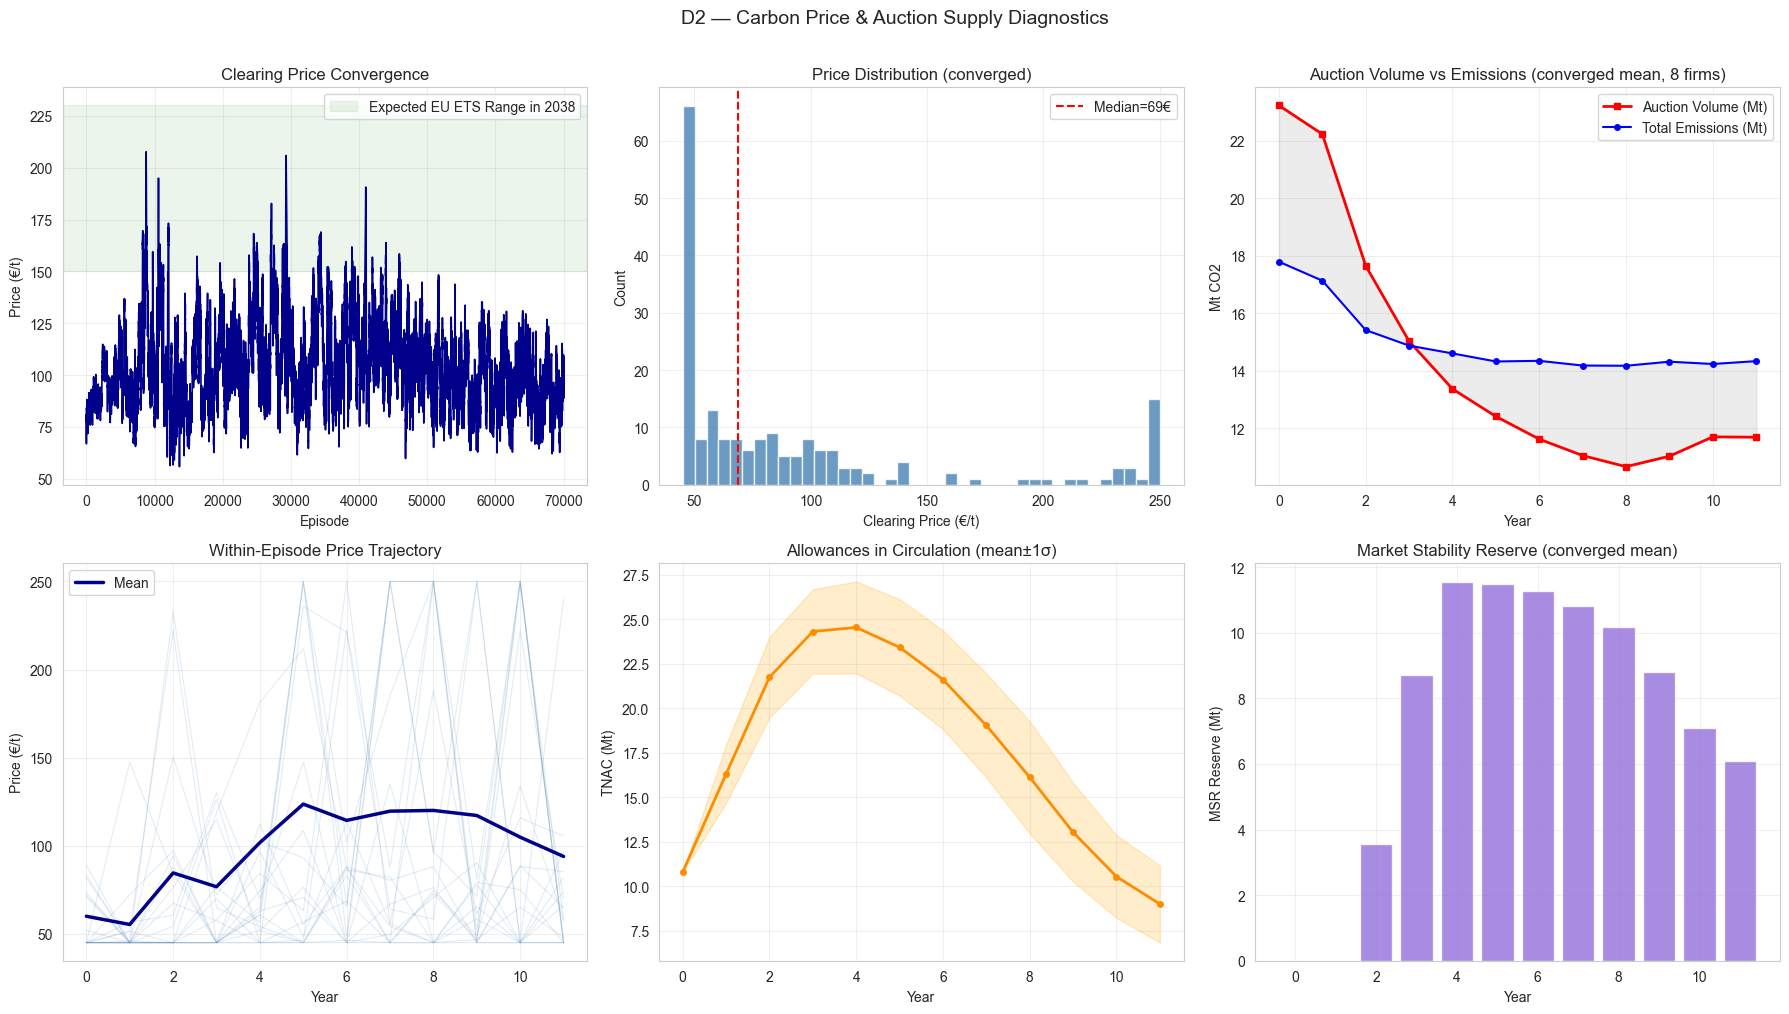

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Clearing price over training
ax = axes[0, 0]
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(ROLL, min_periods=1).mean(),
    color='darkblue', lw=1.2)
ax.axhspan(150, 230, alpha=0.08, color='green', label='Expected EU ETS Range in 2038')
ax.set_xlabel('Episode'); ax.set_ylabel('Price (€/t)')
ax.set_title('Clearing Price Convergence'); ax.legend(); ax.grid(True, alpha=0.3)

# 2 — Price distribution (converged)
ax = axes[0, 1]
prices_conv = recent_yr.groupby('episode')['clearing_price'].last()
ax.hist(prices_conv, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(prices_conv.median(), color='red', ls='--', label=f'Median={prices_conv.median():.0f}€')
ax.set_xlabel('Clearing Price (€/t)'); ax.set_ylabel('Count')
ax.set_title('Price Distribution (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

# 3 — Auctioned volume vs total emissions (ALL companies incl. bots)
ax = axes[0, 2]
auction_by_yr = recent_yr.groupby('year')['auction_volume'].mean()

emis_cols = sorted(
    [c for c in recent_yr.columns if c.startswith('emissions_A')],
    key=lambda c: int(c.split('_A')[1])
)
total_emis_by_row = recent_yr[emis_cols].sum(axis=1)
emis_by_yr = total_emis_by_row.groupby(recent_yr['year']).mean()

ax.plot(auction_by_yr.index, auction_by_yr.values, 'r-s', ms=5, label='Auction Volume (Mt)', lw=2)
ax.plot(emis_by_yr.index, emis_by_yr.values, 'b-o', ms=4, label='Total Emissions (Mt)', lw=1.5)
ax.fill_between(auction_by_yr.index, auction_by_yr.values, emis_by_yr.values, alpha=0.15, color='gray')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2')
ax.set_title(f'Auction Volume vs Emissions (converged mean, {len(emis_cols)} firms)')
ax.legend(); ax.grid(True, alpha=0.3)

# 4 — Within-episode price trajectory
ax = axes[1, 0]
sample_eps = sorted(recent_yr['episode'].unique()[-20:])
for ep in sample_eps:
    ep_data = recent_yr[recent_yr['episode'] == ep]
    ax.plot(ep_data['year'], ep_data['clearing_price'], color='steelblue', alpha=0.15, lw=0.8)
mean_price_yr = recent_yr.groupby('year')['clearing_price'].mean()
ax.plot(mean_price_yr.index, mean_price_yr.values, 'darkblue', lw=2.5, label='Mean')
ax.set_xlabel('Year'); ax.set_ylabel('Price (€/t)')
ax.set_title('Within-Episode Price Trajectory'); ax.legend(); ax.grid(True, alpha=0.3)

# 5 — TNAC over years
ax = axes[1, 1]
tnac_yr = recent_yr.groupby('year')['tnac'].agg(['mean', 'std'])
std_tnac = tnac_yr['std'].fillna(0.0)
ax.plot(tnac_yr.index, tnac_yr['mean'], 'darkorange', lw=2, marker='o', ms=4)
ax.fill_between(tnac_yr.index, tnac_yr['mean'] - std_tnac, tnac_yr['mean'] + std_tnac,
        alpha=0.2, color='orange')
ax.set_xlabel('Year'); ax.set_ylabel('TNAC (Mt)')
ax.set_title('Allowances in Circulation (mean±1σ)'); ax.grid(True, alpha=0.3)

# 6 — MSR reserve
ax = axes[1, 2]
msr_yr = recent_yr.groupby('year')['msr_reserve'].mean()
ax.bar(msr_yr.index, msr_yr.values, color='mediumpurple', alpha=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('MSR Reserve (Mt)')
ax.set_title('Market Stability Reserve (converged mean)'); ax.grid(True, alpha=0.3)

plt.suptitle('D2 — Carbon Price & Auction Supply Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D3. Auction Mechanics

Sanity checks for the uniform-price auction:
- Allocations should sum to roughly the auctioned volume
- Bid prices should bracket the clearing price
- No persistent auction failures

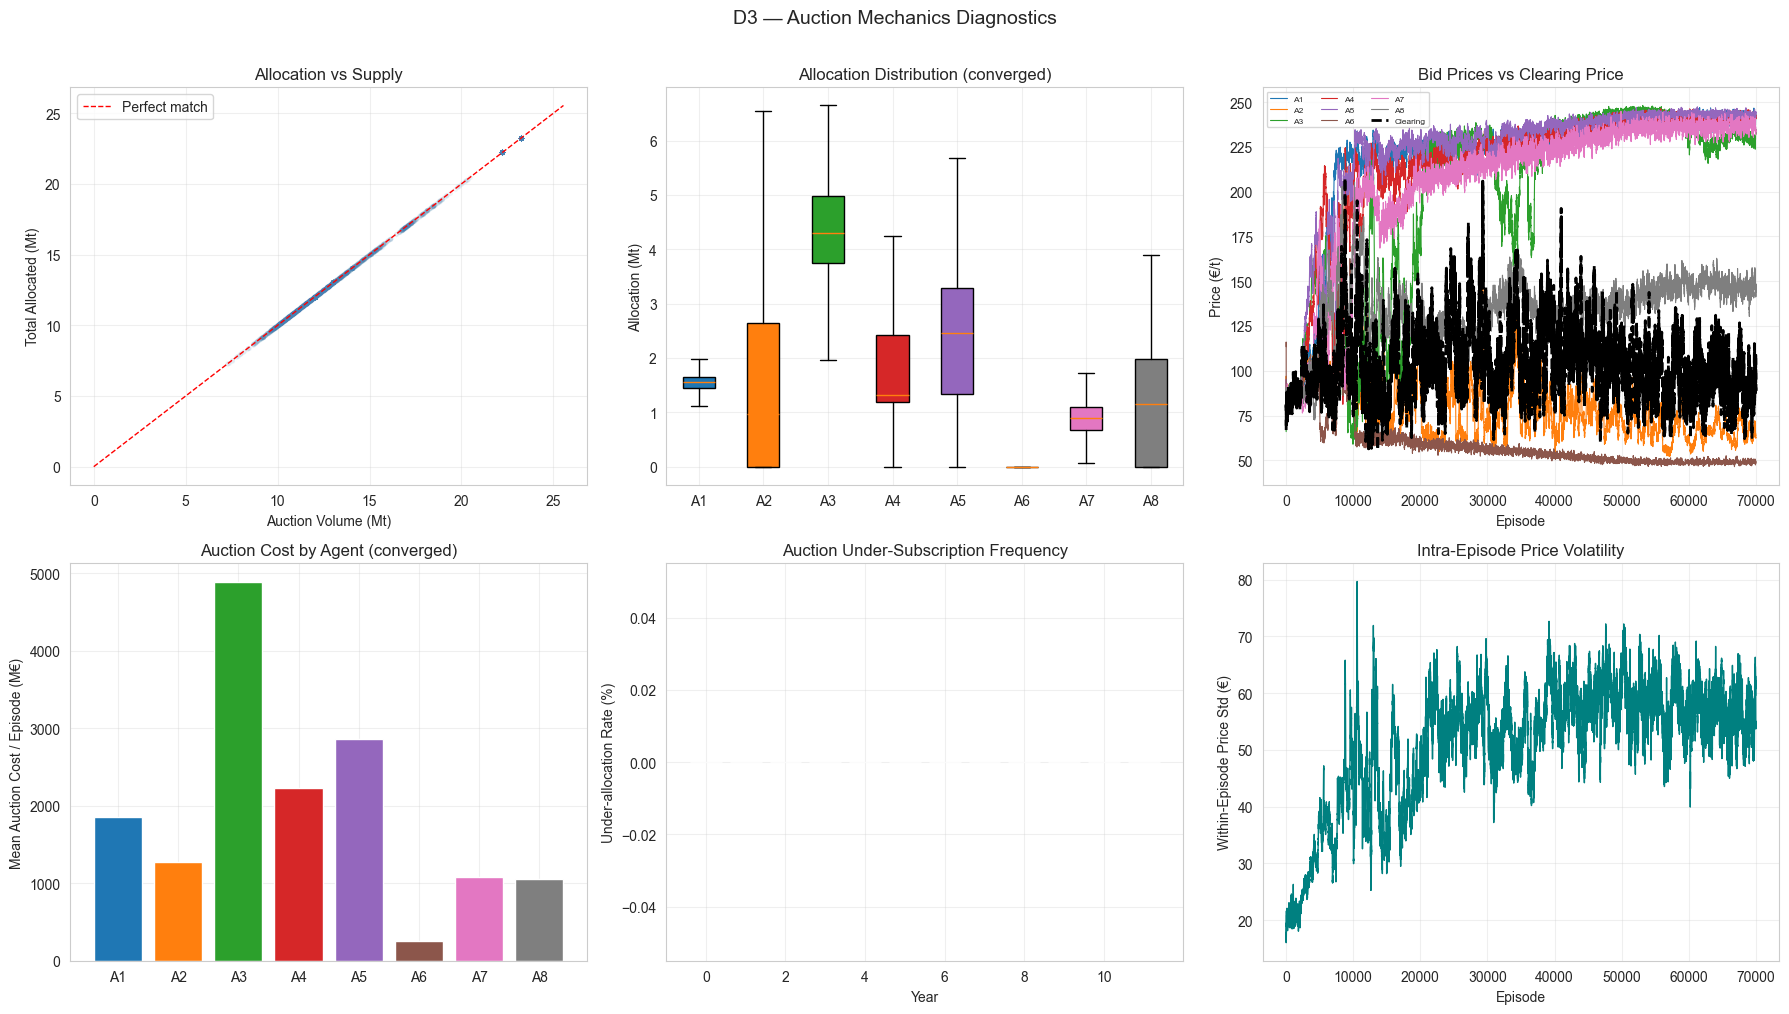

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Total allocation vs auction volume
ax = axes[0, 0]
alloc_cols = [f'alloc_A{i+1}' for i in range(n_agents)]
alloc_total = recent_yr[alloc_cols].sum(axis=1)
ax.scatter(recent_yr['auction_volume'], alloc_total, alpha=0.05, s=8, color='steelblue')
lims = [0, max(recent_yr['auction_volume'].max(), alloc_total.max()) * 1.1]
ax.plot(lims, lims, 'r--', lw=1, label='Perfect match')
ax.set_xlabel('Auction Volume (Mt)'); ax.set_ylabel('Total Allocated (Mt)')
ax.set_title('Allocation vs Supply'); ax.legend(); ax.grid(True, alpha=0.3)

# 2 — Per-agent allocation distribution
ax = axes[0, 1]
alloc_data = [recent_yr[f'alloc_A{i+1}'].values for i in range(n_agents)]
bp = ax.boxplot(alloc_data, tick_labels=[f'A{i+1}' for i in range(n_agents)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(agent_colors[i])
ax.set_ylabel('Allocation (Mt)'); ax.set_title('Allocation Distribution (converged)')
ax.grid(True, alpha=0.3)

# 3 — Bid price vs clearing price
ax = axes[0, 2]
for i in range(n_agents):
    bid_roll = ep_df[f'bid_price_A{i+1}'].rolling(ROLL, min_periods=1).mean()
    ax.plot(ep_df['episode'], bid_roll, color=agent_colors[i], lw=0.8, label=f'A{i+1}')
clr_roll = ep_df['clearing_price_last'].rolling(ROLL, min_periods=1).mean()
ax.plot(ep_df['episode'], clr_roll, 'k--', lw=2, label='Clearing')
ax.set_xlabel('Episode'); ax.set_ylabel('Price (\u20ac/t)')
ax.set_title('Bid Prices vs Clearing Price'); ax.legend(fontsize=6, ncol=3); ax.grid(True, alpha=0.3)

# 4 — Auction cost per agent (converged)
ax = axes[1, 0]
acost_means = [recent_yr.groupby('episode')[f'auction_cost_A{i+1}'].sum().mean() for i in range(n_agents)]
bars = ax.bar([f'A{i+1}' for i in range(n_agents)], acost_means,
              color=agent_colors)
ax.set_ylabel('Mean Auction Cost / Episode (M\u20ac)')
ax.set_title('Auction Cost by Agent (converged)'); ax.grid(True, alpha=0.3)

# 5 — Under-allocation frequency
ax = axes[1, 1]
# Check how often total allocation < 90% of auction volume
under = alloc_total < 0.9 * recent_yr['auction_volume']
under_rate_yr = under.groupby(recent_yr['year']).mean()
ax.bar(under_rate_yr.index, under_rate_yr.values * 100, color='salmon', alpha=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Under-allocation Rate (%)')
ax.set_title('Auction Under-Subscription Frequency'); ax.grid(True, alpha=0.3)

# 6 — Price volatility over training
ax = axes[1, 2]
ax.plot(ep_df['episode'], ep_df['price_std'].rolling(ROLL, min_periods=1).mean(),
        color='teal', lw=1)
ax.set_xlabel('Episode'); ax.set_ylabel('Within-Episode Price Std (\u20ac)')
ax.set_title('Intra-Episode Price Volatility'); ax.grid(True, alpha=0.3)

plt.suptitle('D3 \u2014 Auction Mechanics Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D4. Secondary Market Mechanics

Does the double-auction secondary market function properly?
- Reasonable match rates (not all-or-nothing)
- Secondary prices tracking auction prices
- Both buyers and sellers participating

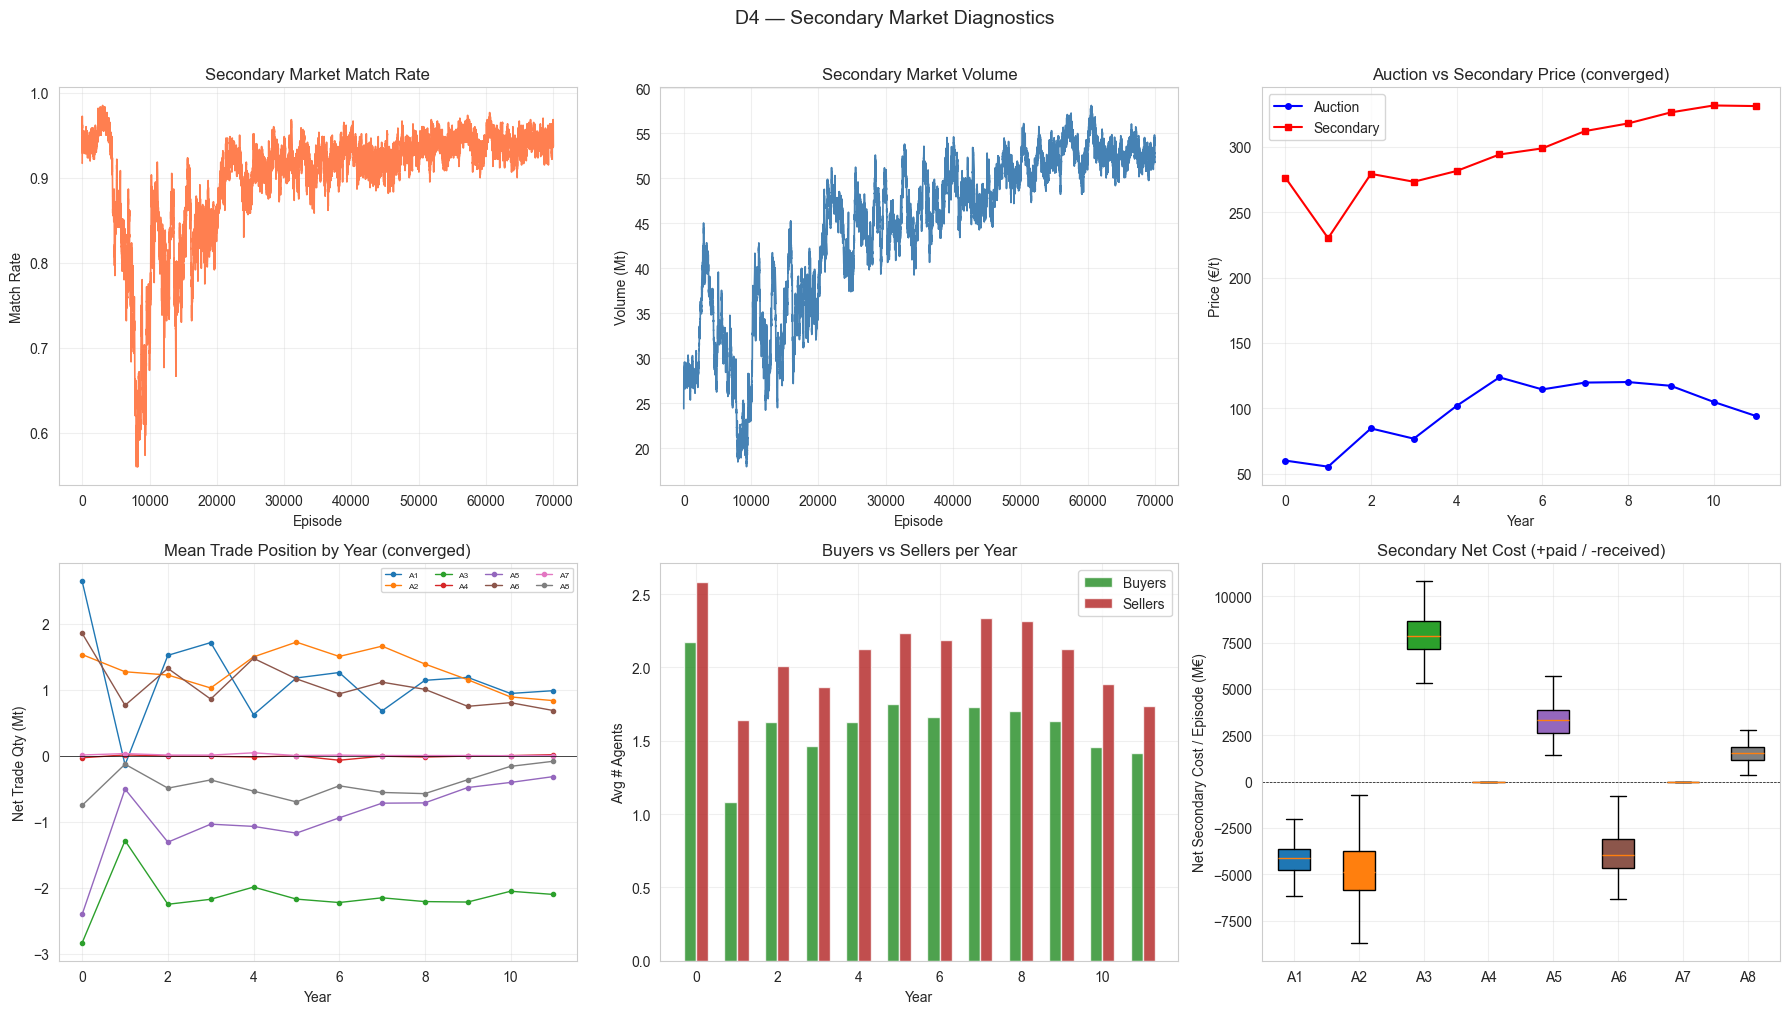

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Match rate over training
ax = axes[0, 0]
ax.plot(ep_df['episode'], ep_df['secondary_match_rate'].rolling(ROLL, min_periods=1).mean(),
        color='coral', lw=1.2)
ax.set_xlabel('Episode'); ax.set_ylabel('Match Rate')
ax.set_title('Secondary Market Match Rate'); ax.grid(True, alpha=0.3)

# 2 — Secondary volume over training
ax = axes[0, 1]
ax.plot(ep_df['episode'], ep_df['secondary_volume'].rolling(ROLL, min_periods=1).mean(),
        color='steelblue', lw=1.2)
ax.set_xlabel('Episode'); ax.set_ylabel('Volume (Mt)')
ax.set_title('Secondary Market Volume'); ax.grid(True, alpha=0.3)

# 3 — Secondary vs Auction price
ax = axes[0, 2]
sec_mean_yr = recent_yr.groupby('year')['secondary_price'].mean()
auc_mean_yr = recent_yr.groupby('year')['clearing_price'].mean()
ax.plot(auc_mean_yr.index, auc_mean_yr.values, 'b-o', ms=4, label='Auction', lw=1.5)
ax.plot(sec_mean_yr.index, sec_mean_yr.values, 'r-s', ms=4, label='Secondary', lw=1.5)
ax.set_xlabel('Year'); ax.set_ylabel('Price (\u20ac/t)')
ax.set_title('Auction vs Secondary Price (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

# 4 — Net trade by agent by year (who buys/sells)
ax = axes[1, 0]
for i in range(n_agents):
    trade_by_yr = recent_yr.groupby('year')[f'trade_qty_A{i+1}'].mean()
    ax.plot(trade_by_yr.index, trade_by_yr.values, color=agent_colors[i],
            marker='o', ms=3, label=f'A{i+1}', lw=1)
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Net Trade Qty (Mt)')
ax.set_title('Mean Trade Position by Year (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Buy/sell balance: count of buyers vs sellers per year
ax = axes[1, 1]
buy_count_yr = []
sell_count_yr = []
for yr in range(n_years_per_ep):
    yr_data = recent_yr[recent_yr['year'] == yr]
    n_buy = sum((yr_data[f'trade_qty_A{i+1}'] > 0.01).mean() for i in range(n_agents))
    n_sell = sum((yr_data[f'trade_qty_A{i+1}'] < -0.01).mean() for i in range(n_agents))
    buy_count_yr.append(n_buy)
    sell_count_yr.append(n_sell)
x = np.arange(n_years_per_ep)
ax.bar(x - 0.15, buy_count_yr, 0.3, color='forestgreen', alpha=0.8, label='Buyers')
ax.bar(x + 0.15, sell_count_yr, 0.3, color='firebrick', alpha=0.8, label='Sellers')
ax.set_xlabel('Year'); ax.set_ylabel('Avg # Agents')
ax.set_title('Buyers vs Sellers per Year'); ax.legend(); ax.grid(True, alpha=0.3)

# 6 — Secondary net cost distribution
ax = axes[1, 2]
snet_data = []
for i in range(n_agents):
    ep_snet = recent_yr.groupby('episode')[f'secondary_net_A{i+1}'].sum()
    snet_data.append(ep_snet.values)
bp = ax.boxplot(snet_data, tick_labels=[f'A{i+1}' for i in range(n_agents)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(agent_colors[i])
ax.axhline(0, color='black', ls='--', lw=0.5)
ax.set_ylabel('Net Secondary Cost / Episode (M\u20ac)')
ax.set_title('Secondary Net Cost (+paid / -received)')
ax.grid(True, alpha=0.3)

plt.suptitle('D4 \u2014 Secondary Market Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D5. Stochastic Shocks (P5 & P6)

Verify that emission demand shocks (P5) and construction uncertainty (P6) are
active and producing the intended distributions.

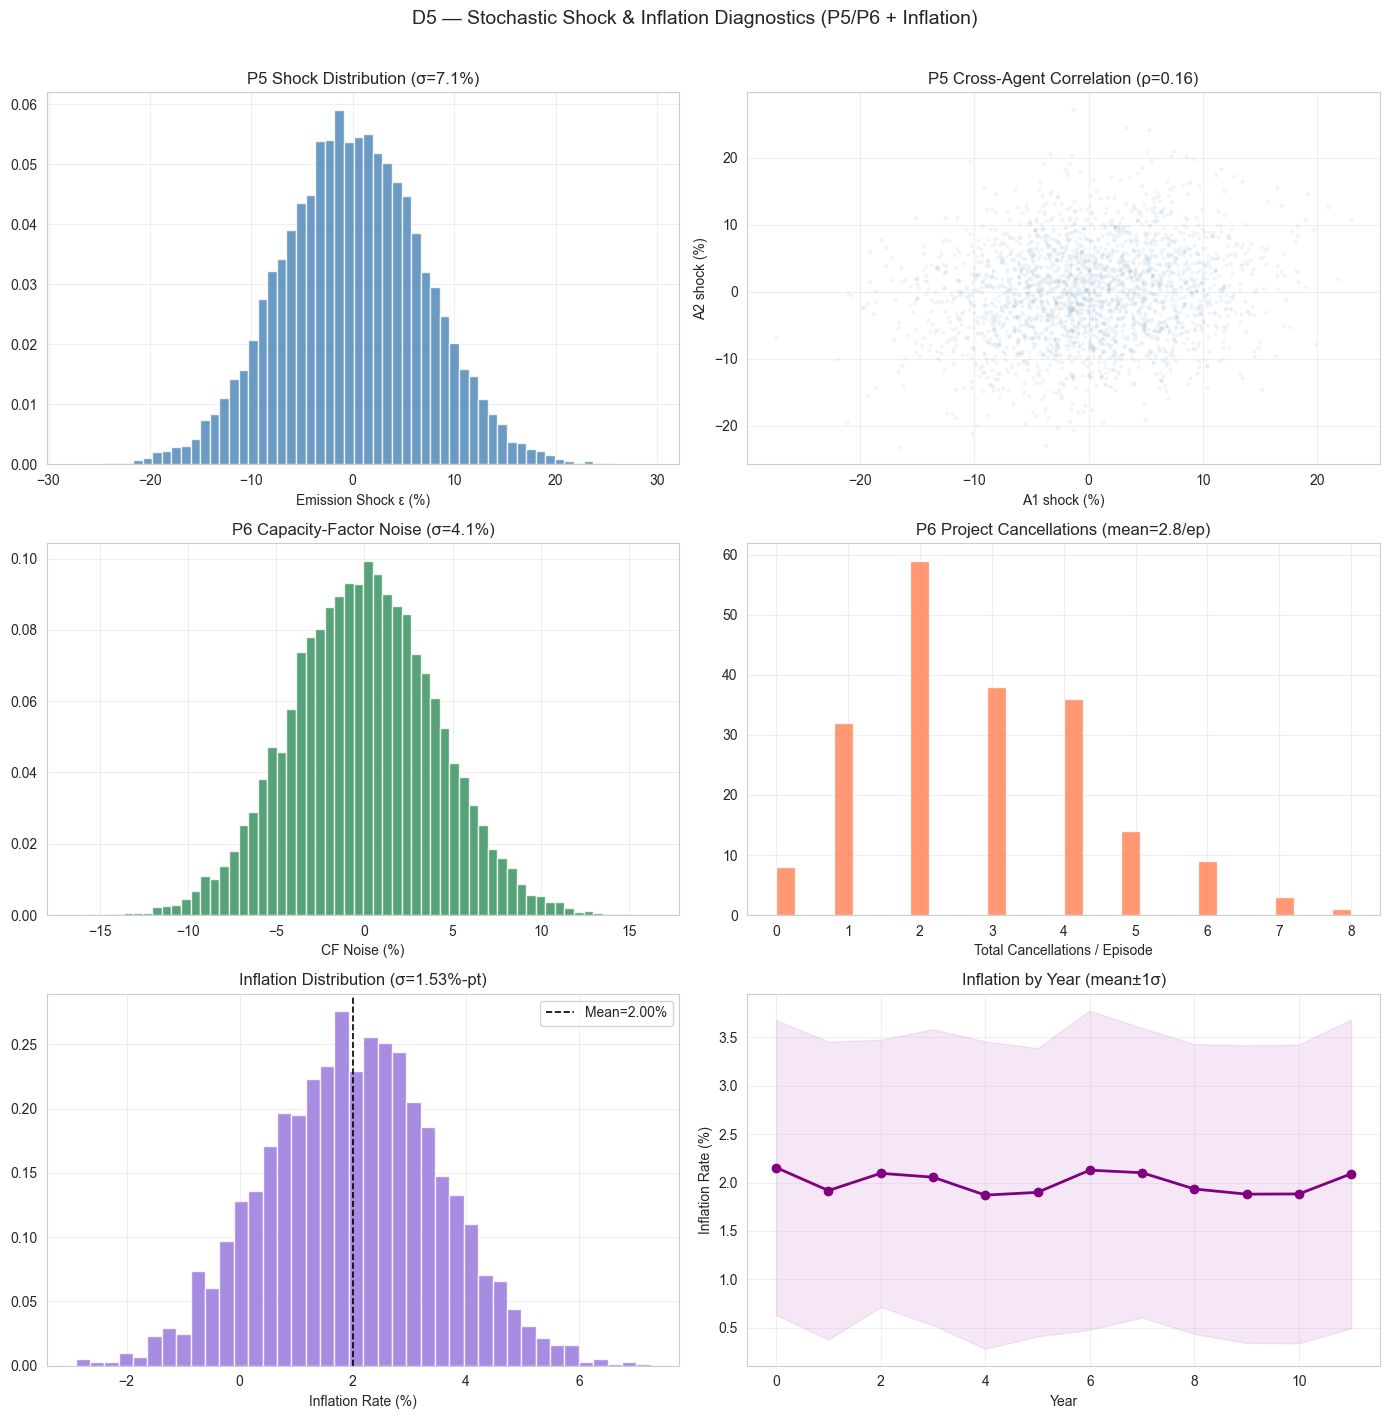

P5 emission shock active: True
P6 CF-noise active:       True
P6 cancellation active:   True
Inflation logged:         True
Inflation mean:           2.001%
Inflation std:            1.531%-pt


In [15]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

shock_cols = [f'emission_shock_A{i+1}' for i in range(n_agents)]
cf_cols = [f'cf_shock_A{i+1}' for i in range(n_agents)]
cancel_cols = [f'cancellation_A{i+1}' for i in range(n_agents)]

has_shocks = any(c in recent_yr.columns for c in shock_cols) and recent_yr[shock_cols[0]].std() > 1e-6

# 1 — P5 shock distribution
ax = axes[0, 0]
if has_shocks:
    all_shocks = pd.concat([recent_yr[c] * 100 for c in shock_cols if c in recent_yr.columns])
    ax.hist(all_shocks, bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    ax.set_xlabel('Emission Shock ε (%)')
    ax.set_title(f'P5 Shock Distribution (σ={all_shocks.std():.1f}%)')
else:
    ax.text(0.5, 0.5, 'P5 shocks inactive', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('P5 — Inactive')
ax.grid(True, alpha=0.3)

# 2 — P5 cross-agent correlation
ax = axes[0, 1]
if has_shocks and n_agents >= 2:
    s1 = recent_yr[shock_cols[0]] * 100
    s2 = recent_yr[shock_cols[1]] * 100
    ax.scatter(s1, s2, alpha=0.05, s=5, color='steelblue')
    corr = s1.corr(s2)
    ax.set_xlabel('A1 shock (%)'); ax.set_ylabel('A2 shock (%)')
    ax.set_title(f'P5 Cross-Agent Correlation (ρ={corr:.2f})')
else:
    ax.text(0.5, 0.5, 'P5 inactive or <2 agents', ha='center', va='center', transform=ax.transAxes)
ax.grid(True, alpha=0.3)

# 3 — P6 CF noise
ax = axes[1, 0]
has_cf = any(c in recent_yr.columns for c in cf_cols) and recent_yr[cf_cols[0]].std() > 1e-8
if has_cf:
    all_cf = pd.concat([recent_yr[c] * 100 for c in cf_cols if c in recent_yr.columns])
    ax.hist(all_cf, bins=60, color='seagreen', edgecolor='white', alpha=0.8, density=True)
    ax.set_xlabel('CF Noise (%)')
    ax.set_title(f'P6 Capacity-Factor Noise (σ={all_cf.std():.1f}%)')
else:
    ax.text(0.5, 0.5, 'P6 CF-noise inactive', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('P6 CF — Inactive')
ax.grid(True, alpha=0.3)

# 4 — P6 cancellations
ax = axes[1, 1]
has_cancel = any(c in recent_yr.columns for c in cancel_cols) and recent_yr[cancel_cols[0]].sum() > 0
if has_cancel:
    cancel_per_ep = recent_yr.groupby('episode')[cancel_cols].sum().sum(axis=1)
    ax.hist(cancel_per_ep, bins=30, color='coral', edgecolor='white', alpha=0.8)
    ax.set_xlabel('Total Cancellations / Episode')
    ax.set_title(f'P6 Project Cancellations (mean={cancel_per_ep.mean():.1f}/ep)')
else:
    ax.text(0.5, 0.5, 'P6 cancellations inactive', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('P6 Cancellations — Inactive')
ax.grid(True, alpha=0.3)

# 5 — Inflation rate distribution
ax = axes[2, 0]
has_infl = 'inflation_rate' in recent_yr.columns and recent_yr['inflation_rate'].notna().any()
if has_infl:
    infl_pct = recent_yr['inflation_rate'] * 100
    ax.hist(infl_pct, bins=40, color='mediumpurple', edgecolor='white', alpha=0.8, density=True)
    ax.axvline(infl_pct.mean(), color='black', ls='--', lw=1.2, label=f'Mean={infl_pct.mean():.2f}%')
    ax.set_xlabel('Inflation Rate (%)')
    ax.set_title(f'Inflation Distribution (σ={infl_pct.std():.2f}%-pt)')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'Inflation not logged in year_log', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Inflation — Not Available')
ax.grid(True, alpha=0.3)

# 6 — Inflation profile by year
ax = axes[2, 1]
if has_infl:
    infl_by_year = recent_yr.groupby('year')['inflation_rate'].agg(['mean', 'std']) * 100
    ax.plot(infl_by_year.index, infl_by_year['mean'], color='purple', marker='o', lw=2)
    std_fill = infl_by_year['std'].fillna(0.0)
    ax.fill_between(
        infl_by_year.index,
        infl_by_year['mean'] - std_fill,
        infl_by_year['mean'] + std_fill,
        color='plum', alpha=0.25
    )
    ax.set_xlabel('Year')
    ax.set_ylabel('Inflation Rate (%)')
    ax.set_title('Inflation by Year (mean±1σ)')
else:
    ax.text(0.5, 0.5, 'Inflation not logged in year_log', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Inflation by Year — Not Available')
ax.grid(True, alpha=0.3)

plt.suptitle('D5 — Stochastic Shock & Inflation Diagnostics (P5/P6 + Inflation)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

# Summary
print(f'P5 emission shock active: {has_shocks}')
print(f'P6 CF-noise active:       {has_cf}')
print(f'P6 cancellation active:   {has_cancel}')
print(f'Inflation logged:         {has_infl}')
if has_infl:
    infl_pct = recent_yr['inflation_rate'] * 100
    print(f'Inflation mean:           {infl_pct.mean():.3f}%')
    print(f'Inflation std:            {infl_pct.std():.3f}%-pt')

### D6. Compliance & Penalty Mechanics

Verify that compliance mechanics work:
- Shortfalls are detected and penalized
- Penalties are proportional to shortfall
- Banking (carry-over) functions correctly

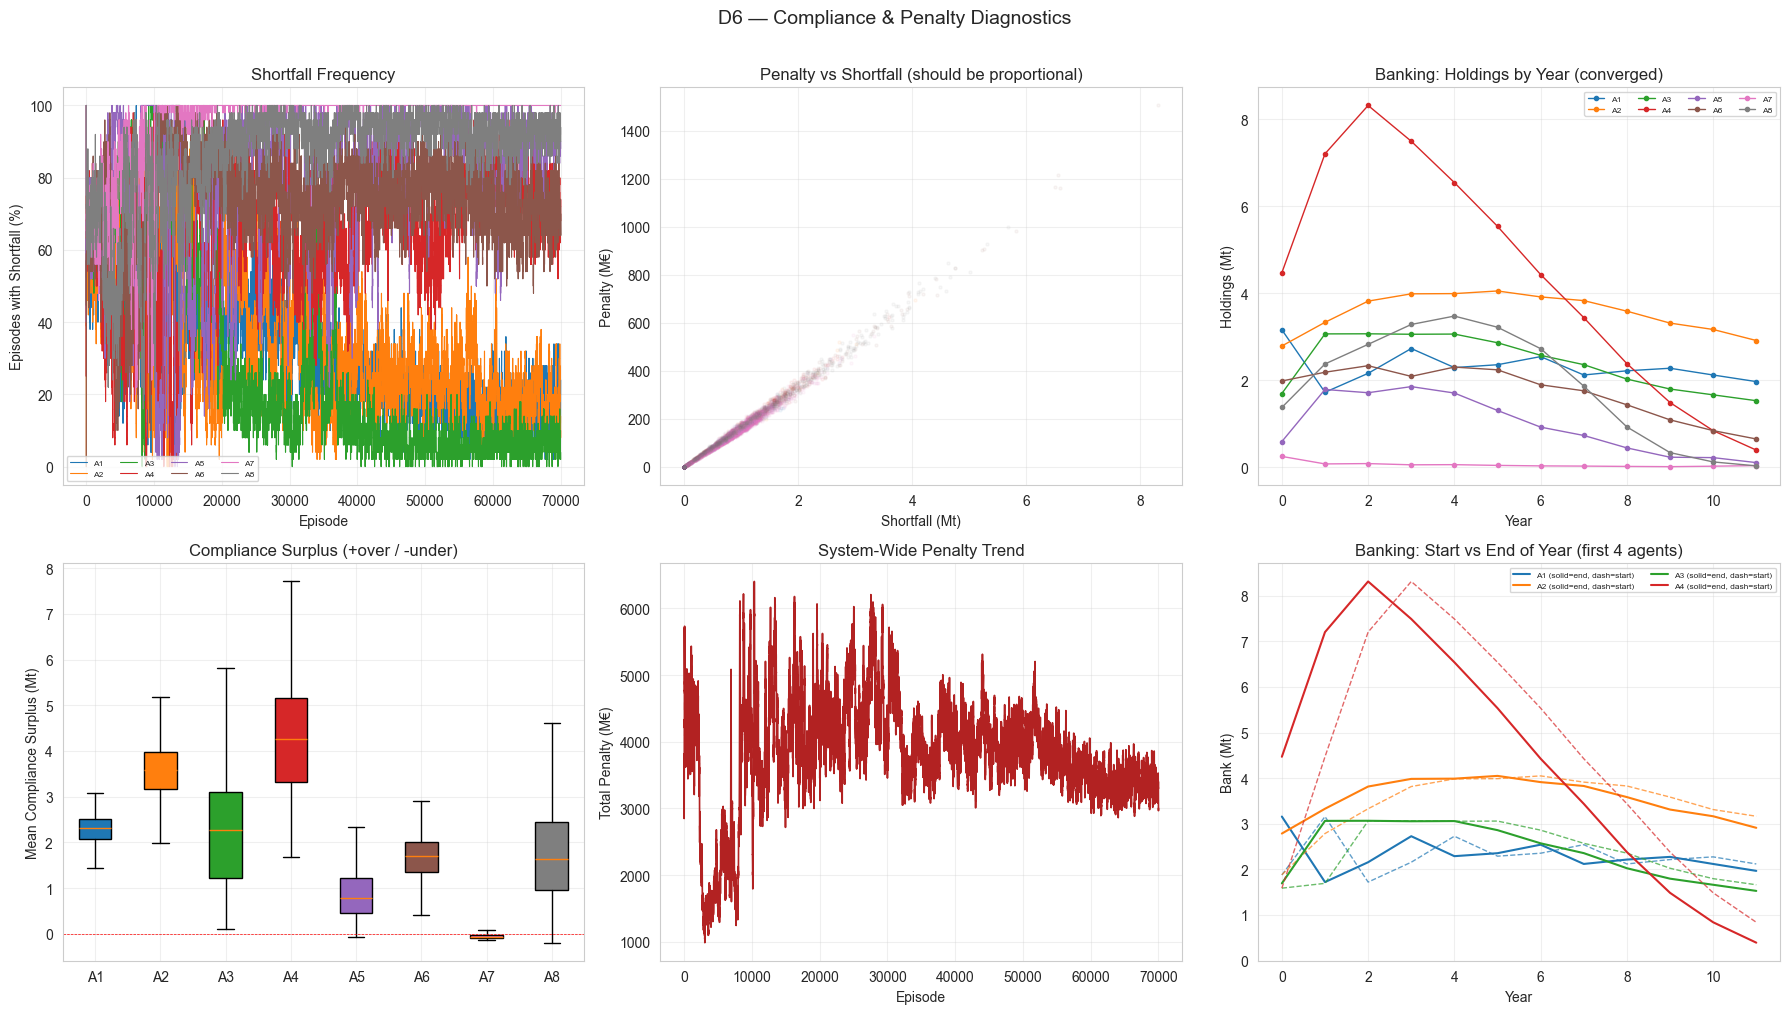

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Shortfall rate over training
ax = axes[0, 0]
for i in range(n_agents):
    sf = (ep_df[f'shortfall_A{i+1}'] > 1e-6).astype(float).rolling(ROLL, min_periods=1).mean()
    ax.plot(ep_df['episode'], sf * 100, color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Episodes with Shortfall (%)')
ax.set_title('Shortfall Frequency'); ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 2 — Penalty vs shortfall (should be correlated)
ax = axes[0, 1]
for i in range(n_agents):
    ax.scatter(recent_yr[f'shortfall_A{i+1}'], recent_yr[f'penalty_A{i+1}'],
               alpha=0.05, s=5, color=agent_colors[i], label=f'A{i+1}')
ax.set_xlabel('Shortfall (Mt)'); ax.set_ylabel('Penalty (M\u20ac)')
ax.set_title('Penalty vs Shortfall (should be proportional)')
ax.grid(True, alpha=0.3)

# 3 — Holdings by year (banking)
ax = axes[0, 2]
for i in range(n_agents):
    hold_yr = recent_yr.groupby('year')[f'holdings_A{i+1}'].mean()
    ax.plot(hold_yr.index, hold_yr.values, color=agent_colors[i], marker='o', ms=3,
            label=f'A{i+1}', lw=1)
ax.set_xlabel('Year'); ax.set_ylabel('Holdings (Mt)')
ax.set_title('Banking: Holdings by Year (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Compliance surplus distribution
ax = axes[1, 0]
if f'compliance_surplus_A1' in recent_yr.columns:
    surp_data = [recent_yr.groupby('episode')[f'compliance_surplus_A{i+1}'].mean().values
                 for i in range(n_agents)]
    bp = ax.boxplot(surp_data, tick_labels=[f'A{i+1}' for i in range(n_agents)],
                    patch_artist=True, showfliers=False)
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(agent_colors[i])
    ax.axhline(0, color='red', ls='--', lw=0.5)
    ax.set_ylabel('Mean Compliance Surplus (Mt)')
    ax.set_title('Compliance Surplus (+over / -under)')
else:
    ax.text(0.5, 0.5, 'compliance_surplus not logged', ha='center', va='center',
            transform=ax.transAxes)
ax.grid(True, alpha=0.3)

# 5 — Total penalty over training
ax = axes[1, 1]
pen_cols = [f'penalty_A{i+1}' for i in range(n_agents)]
total_pen = ep_df[pen_cols].sum(axis=1)
ax.plot(ep_df['episode'], total_pen.rolling(ROLL, min_periods=1).mean(), color='firebrick', lw=1.2)
ax.set_xlabel('Episode'); ax.set_ylabel('Total Penalty (M\u20ac)')
ax.set_title('System-Wide Penalty Trend'); ax.grid(True, alpha=0.3)

# 6 — Carry-forward: bank_end vs bank_start
ax = axes[1, 2]
if 'bank_end_A1' in recent_yr.columns and 'bank_start_A1' in recent_yr.columns:
    for i in range(min(4, n_agents)):
        bs = recent_yr.groupby('year')[f'bank_start_A{i+1}'].mean()
        be = recent_yr.groupby('year')[f'bank_end_A{i+1}'].mean()
        ax.plot(bs.index, bs.values, color=agent_colors[i], ls='--', lw=1, alpha=0.7)
        ax.plot(be.index, be.values, color=agent_colors[i], ls='-', lw=1.5,
                label=f'A{i+1} (solid=end, dash=start)')
    ax.set_xlabel('Year'); ax.set_ylabel('Bank (Mt)')
    ax.set_title('Banking: Start vs End of Year (first 4 agents)')
    ax.legend(fontsize=6, ncol=2)
else:
    ax.text(0.5, 0.5, 'bank_end not logged', ha='center', va='center', transform=ax.transAxes)
ax.grid(True, alpha=0.3)

plt.suptitle('D6 \u2014 Compliance & Penalty Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D7. Green Investing

Overall green investment behavior across training (trend, distribution, and efficiency).

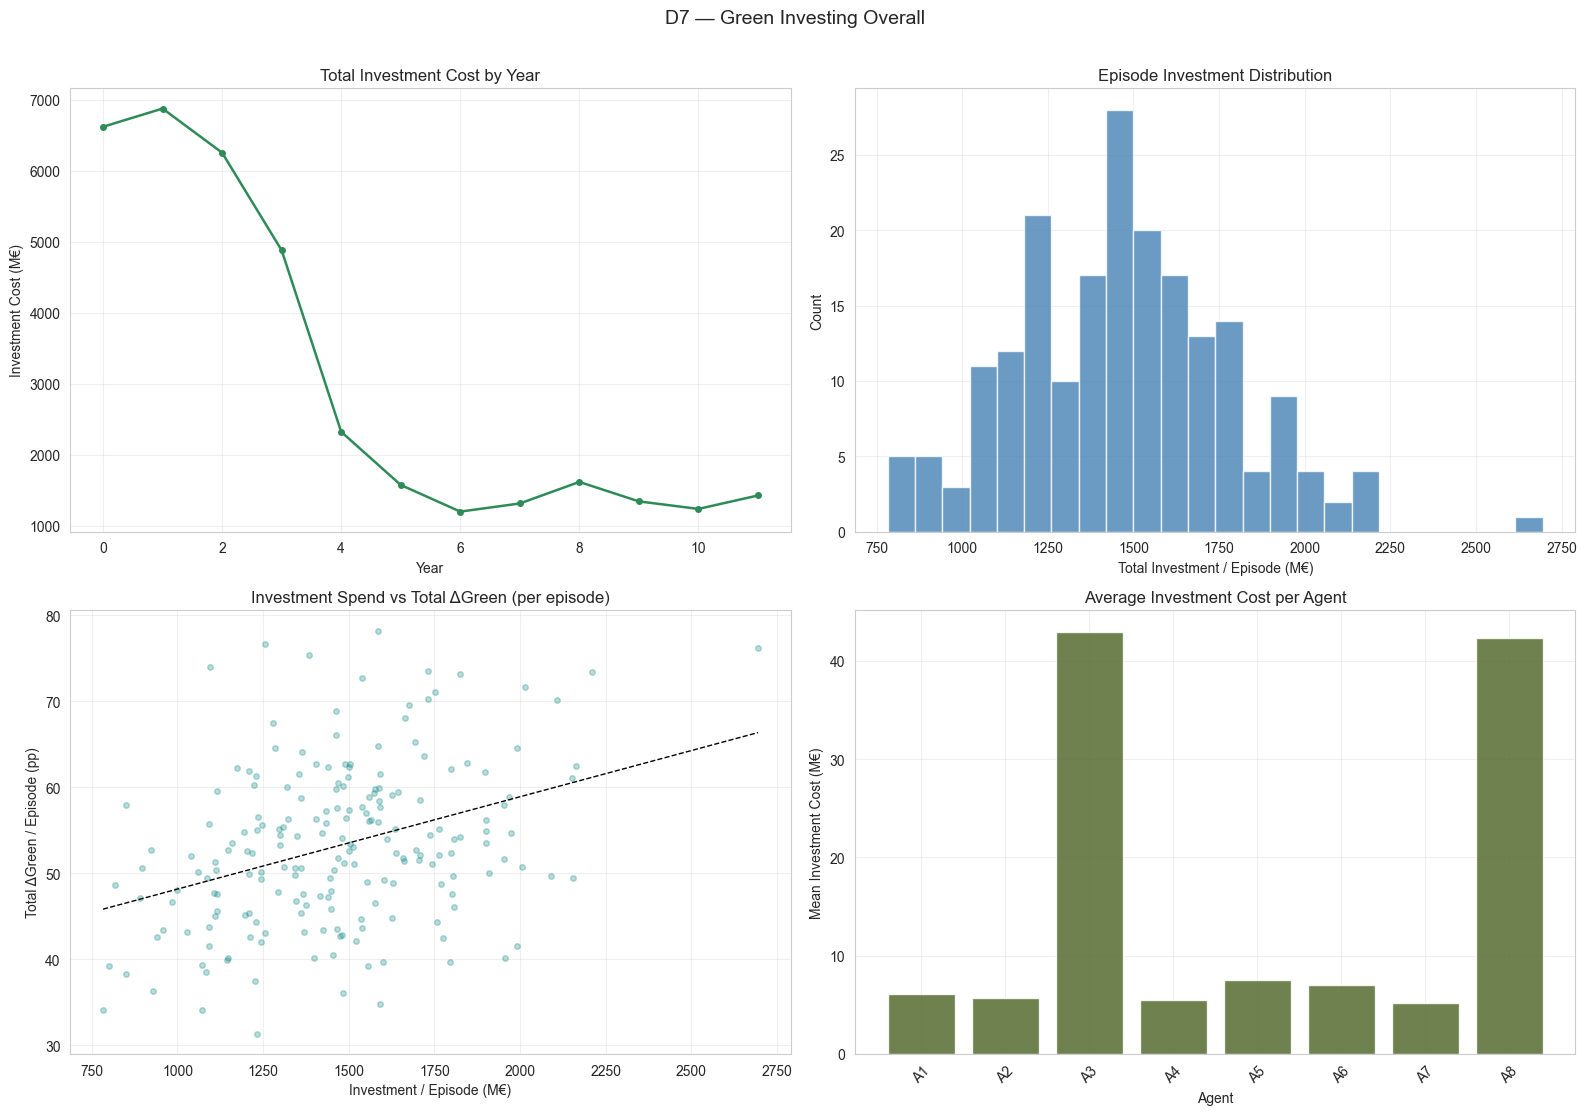

D7 SUMMARY — GREEN INVESTING OVERALL
Mean investment / episode: 1467.68 M€
Median investment / episode: 1467.51 M€
P90 investment / episode: 1897.40 M€
Corr(episode investment, episode Δgreen): 0.360


In [17]:
# ── D7: Green Investing   ───────────────────────────
reward_cols_all = sorted(
    [c for c in recent_yr.columns if c.startswith('reward_A')],
    key=lambda x: int(x.split('_A')[1])
)
n_logged = max(int(c.split('_A')[1]) for c in reward_cols_all) if reward_cols_all else n_agents
agent_ids_logged = list(range(1, n_logged + 1))

invest_cols = [f'invest_cost_A{i}' for i in agent_ids_logged if f'invest_cost_A{i}' in recent_yr.columns]
dgreen_cols = [f'delta_green_A{i}' for i in agent_ids_logged if f'delta_green_A{i}' in recent_yr.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1) System investment trend by year
ax = axes[0, 0]
if invest_cols:
    invest_by_year = recent_yr.groupby('year')[invest_cols].sum().mean(axis=1)
    ax.plot(invest_by_year.index, invest_by_year.values, 'o-', color='seagreen', lw=1.8, ms=4)
    ax.set_title('Total Investment Cost by Year')
else:
    ax.text(0.5, 0.5, 'Investment columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Year'); ax.set_ylabel('Investment Cost (M€)'); ax.grid(True, alpha=0.3)

# 2) Investment distribution per episode
ax = axes[0, 1]
if invest_cols:
    ep_invest = recent_yr.groupby('episode')[invest_cols].sum().sum(axis=1)
    ax.hist(ep_invest.values, bins=24, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title('Episode Investment Distribution')
else:
    ax.text(0.5, 0.5, 'Investment columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Total Investment / Episode (M€)'); ax.set_ylabel('Count'); ax.grid(True, alpha=0.3)

# 3) Investment vs greening efficiency
ax = axes[1, 0]
if invest_cols and dgreen_cols:
    ep_invest = recent_yr.groupby('episode')[invest_cols].sum().sum(axis=1)
    ep_dgreen = recent_yr.groupby('episode')[dgreen_cols].sum().sum(axis=1) * 100
    ax.scatter(ep_invest, ep_dgreen, alpha=0.28, s=16, color='teal')
    if len(ep_invest) > 2:
        m = np.polyfit(ep_invest.values, ep_dgreen.values, 1)
        xfit = np.linspace(ep_invest.min(), ep_invest.max(), 60)
        ax.plot(xfit, m[0] * xfit + m[1], 'k--', lw=1)
    ax.set_title('Investment Spend vs Total ΔGreen (per episode)')
else:
    ax.text(0.5, 0.5, 'Need invest_cost + delta_green logs', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Investment / Episode (M€)'); ax.set_ylabel('Total ΔGreen / Episode (pp)'); ax.grid(True, alpha=0.3)

# 4) Mean investment by agent
ax = axes[1, 1]
if invest_cols:
    per_agent_inv = []
    labels = []
    for i in agent_ids_logged:
        col = f'invest_cost_A{i}'
        if col in recent_yr.columns:
            per_agent_inv.append(recent_yr[col].mean())
            labels.append(f'A{i}')
    x = np.arange(len(labels))
    ax.bar(x, per_agent_inv, color='darkolivegreen', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
    ax.set_title('Average Investment Cost per Agent')
else:
    ax.text(0.5, 0.5, 'Investment columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Mean Investment Cost (M€)'); ax.grid(True, alpha=0.3)

plt.suptitle('D7 — Green Investing Overall', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

print('=' * 110)
print('D7 SUMMARY — GREEN INVESTING OVERALL')
print('=' * 110)
if invest_cols:
    ep_invest = recent_yr.groupby('episode')[invest_cols].sum().sum(axis=1)
    print(f'Mean investment / episode: {ep_invest.mean():.2f} M€')
    print(f'Median investment / episode: {ep_invest.median():.2f} M€')
    print(f'P90 investment / episode: {ep_invest.quantile(0.90):.2f} M€')
if invest_cols and dgreen_cols:
    ep_dgreen = recent_yr.groupby('episode')[dgreen_cols].sum().sum(axis=1)
    corr_inv_green = ep_invest.corr(ep_dgreen) if len(ep_invest) > 1 else np.nan
    print(f'Corr(episode investment, episode Δgreen): {corr_inv_green:.3f}')

### D8. Final-Year Invested Assets, Queue State, and Liquidation Payoff

> This cell now prioritizes liquidation values logged directly from the environment reward computation into year_log CSV.

> Fallback behavior:
> - If `terminal_*_value_A*` columns are absent (older logs), bank liquidation is reconstructed from bank_end × clearing_price / 1000.
> - Queue liquidation is shown only if logged columns exist.

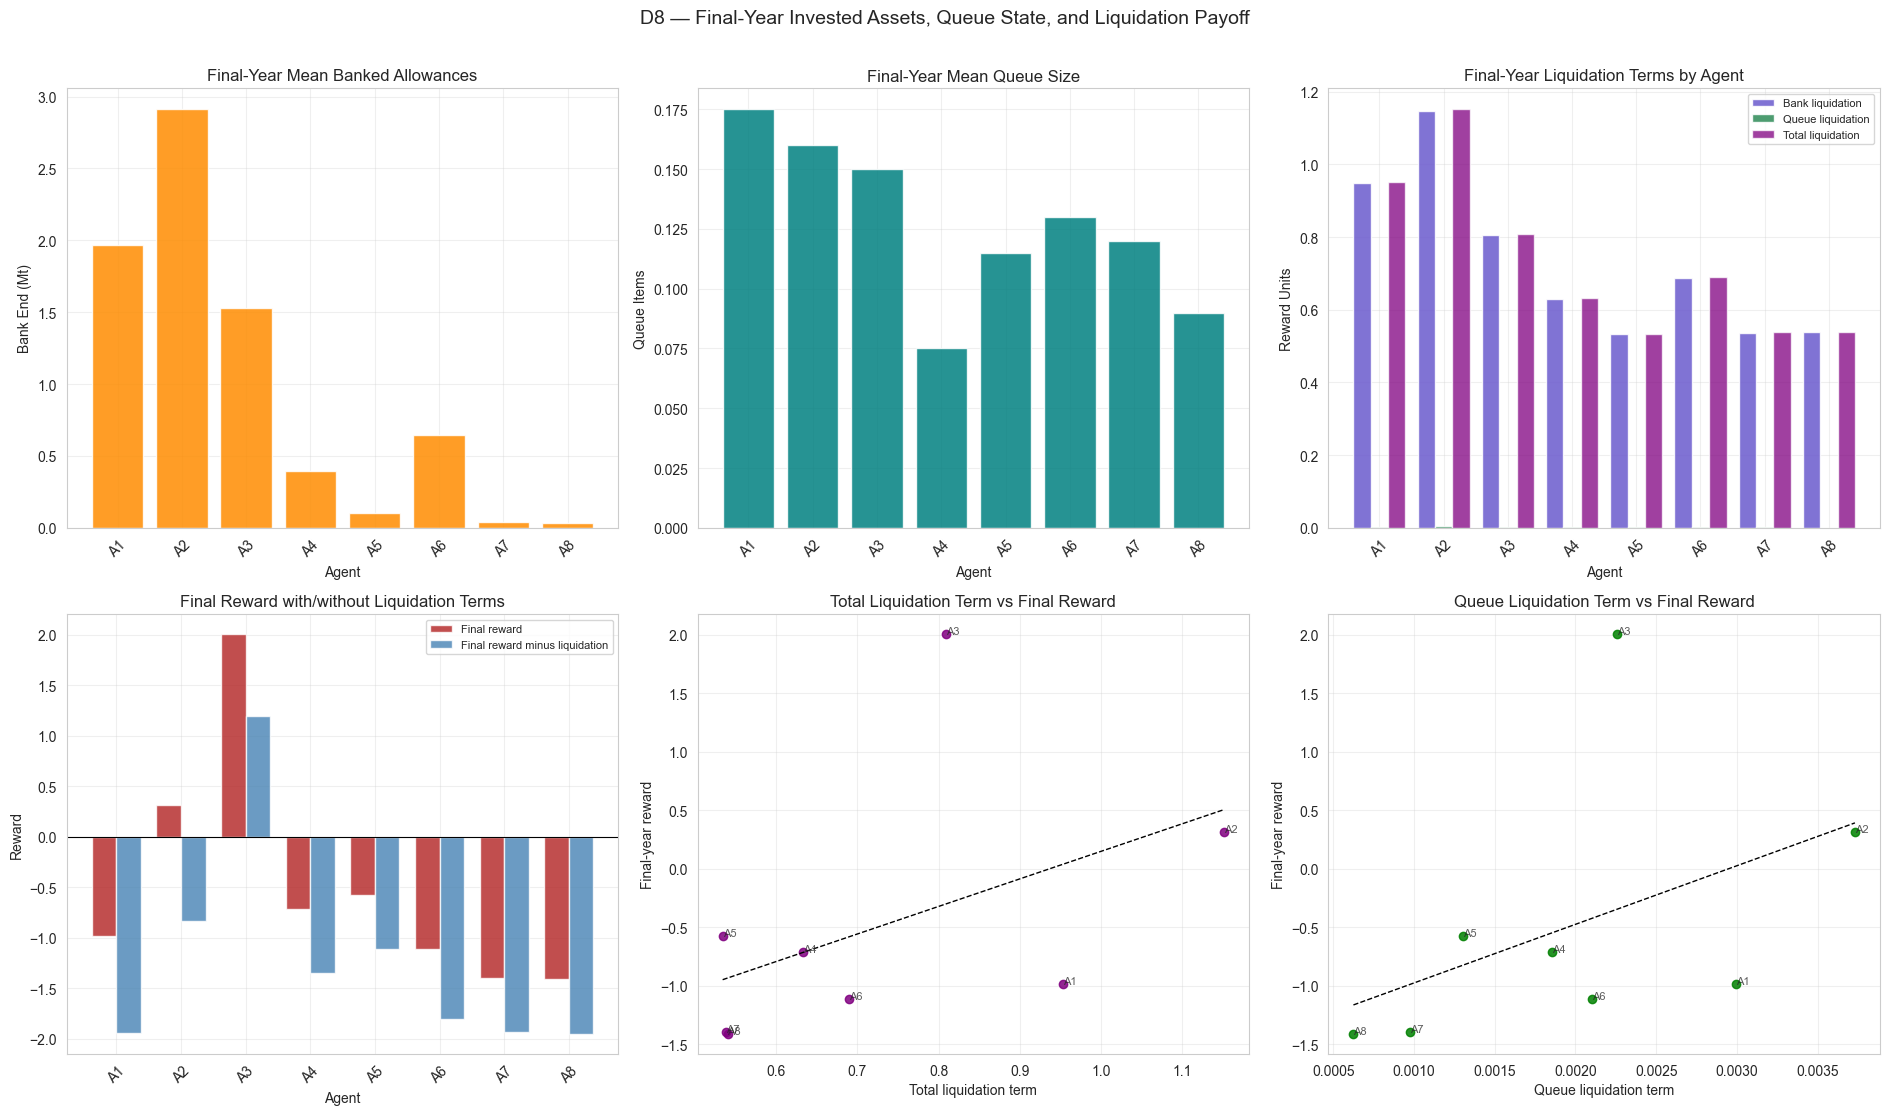

D8 SUMMARY — FINAL-YEAR INVESTED ASSETS, QUEUE STATE, AND LIQUIDATION PAYOFF
terminal_bank_value enabled (config): True
terminal_queue_value enabled (config): True
terminal_payoff_years: 5, gamma: 0.99
Liquidation source: logged terminal_*_value columns
Final-year system reward: -3.88
Pre-final mean system reward: -5.06
Final-year payoff uplift: +1.18
Final-year total bank_end (mean over episodes): 7.62 Mt
Final-year total queue size (mean over episodes): 1.01
Final-year total investment cost (mean over episodes): 57.15 M€
Final-year total liquidation term (mean over episodes): 5.849
 - Bank component: 5.833
 - Queue component: 0.016


In [18]:
# ── D8: Final-Year Invested Assets, Queue State, and Liquidation Payoff ─────
reward_cols_all = sorted(
    [c for c in recent_yr.columns if c.startswith('reward_A')],
    key=lambda x: int(x.split('_A')[1])
)
n_logged = max(int(c.split('_A')[1]) for c in reward_cols_all) if reward_cols_all else n_agents
agent_ids_logged = list(range(1, n_logged + 1))

reward_cols = [f'reward_A{i}' for i in agent_ids_logged if f'reward_A{i}' in recent_yr.columns]
invest_cols = [f'invest_cost_A{i}' for i in agent_ids_logged if f'invest_cost_A{i}' in recent_yr.columns]
bank_cols = [f'bank_end_A{i}' for i in agent_ids_logged if f'bank_end_A{i}' in recent_yr.columns]
queue_cols = [f'queue_size_A{i}' for i in agent_ids_logged if f'queue_size_A{i}' in recent_yr.columns]

# Resolve config robustly so this cell works even if earlier config-loading cells were not run.
config_obj = None
if isinstance(globals().get('config', None), dict):
    config_obj = globals()['config']
elif isinstance(globals().get('cfg', None), dict):
    config_obj = globals()['cfg']
else:
    try:
        from pathlib import Path
        import yaml

        cfg_path = globals().get('CONFIG_PATH', None)
        if cfg_path is not None and Path(cfg_path).exists():
            with open(cfg_path, 'r', encoding='utf-8') as f:
                loaded_cfg = yaml.safe_load(f) or {}
            if isinstance(loaded_cfg, dict):
                config_obj = loaded_cfg
    except Exception:
        config_obj = None

if config_obj is None:
    config_obj = {}

reward_cfg = config_obj.get('reward', {})
terminal_bank_enabled = bool(reward_cfg.get('terminal_bank_value', False))
terminal_queue_enabled = bool(reward_cfg.get('terminal_queue_value', False))
terminal_payoff_years = reward_cfg.get('terminal_payoff_years', 5)
gamma_discount = config_obj.get('ppo', {}).get('gamma', 0.99)

y_last = int(recent_yr['year'].max())
final_slice = recent_yr[recent_yr['year'] == y_last].copy()

# Logged liquidation columns (new schema)
bank_liq_cols = [f'terminal_bank_value_A{i}' for i in agent_ids_logged if f'terminal_bank_value_A{i}' in final_slice.columns]
queue_liq_cols = [f'terminal_queue_value_A{i}' for i in agent_ids_logged if f'terminal_queue_value_A{i}' in final_slice.columns]
total_liq_cols = [f'terminal_liquidation_value_A{i}' for i in agent_ids_logged if f'terminal_liquidation_value_A{i}' in final_slice.columns]

has_logged_liq = len(total_liq_cols) > 0 or (len(bank_liq_cols) > 0 and len(queue_liq_cols) > 0)

agent_labels = []
final_reward_vals = []
bank_end_vals = []
queue_end_vals = []
bank_liq_vals = []
queue_liq_vals = []
total_liq_vals = []

for i in agent_ids_logged:
    a = f'A{i}'
    r_col = f'reward_A{i}'
    b_col = f'bank_end_A{i}'
    q_col = f'queue_size_A{i}'
    b_liq_col = f'terminal_bank_value_A{i}'
    q_liq_col = f'terminal_queue_value_A{i}'
    t_liq_col = f'terminal_liquidation_value_A{i}'

    if r_col not in final_slice.columns:
        continue

    rf = final_slice[r_col].mean()
    be = final_slice[b_col].mean() if b_col in final_slice.columns else np.nan
    qe = final_slice[q_col].mean() if q_col in final_slice.columns else np.nan

    # Prefer directly logged liquidation terms (auto-tracks formula changes).
    if t_liq_col in final_slice.columns:
        t_liq = final_slice[t_liq_col].mean()
        b_liq = final_slice[b_liq_col].mean() if b_liq_col in final_slice.columns else np.nan
        q_liq = final_slice[q_liq_col].mean() if q_liq_col in final_slice.columns else np.nan
    else:
        # Fallback for old logs: only bank term can be reconstructed exactly.
        if terminal_bank_enabled and b_col in final_slice.columns and 'clearing_price' in final_slice.columns:
            b_liq = (final_slice[b_col] * final_slice['clearing_price'] / 1000.0).mean()
        else:
            b_liq = 0.0
        q_liq = 0.0
        t_liq = b_liq + q_liq

    agent_labels.append(a)
    final_reward_vals.append(rf)
    bank_end_vals.append(be)
    queue_end_vals.append(qe)
    bank_liq_vals.append(b_liq)
    queue_liq_vals.append(q_liq)
    total_liq_vals.append(t_liq)

fig, axes = plt.subplots(2, 3, figsize=(19, 11))

# 1) Final-year banked allowances by agent
ax = axes[0, 0]
if len(bank_end_vals) > 0:
    x = np.arange(len(agent_labels))
    ax.bar(x, bank_end_vals, color='darkorange', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(agent_labels, rotation=45)
    ax.set_title('Final-Year Mean Banked Allowances')
else:
    ax.text(0.5, 0.5, 'bank_end columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Bank End (Mt)'); ax.grid(True, alpha=0.3)

# 2) Final-year queue size by agent (end-of-simulation queue look)
ax = axes[0, 1]
if len(queue_end_vals) > 0:
    x = np.arange(len(agent_labels))
    ax.bar(x, queue_end_vals, color='teal', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(agent_labels, rotation=45)
    ax.set_title('Final-Year Mean Queue Size')
else:
    ax.text(0.5, 0.5, 'queue_size columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Queue Items'); ax.grid(True, alpha=0.3)

# 3) Liquidation decomposition (bank / queue / total)
ax = axes[0, 2]
if len(total_liq_vals) > 0:
    x = np.arange(len(agent_labels))
    w = 0.27
    ax.bar(x - w, bank_liq_vals, w, color='slateblue', alpha=0.85, label='Bank liquidation')
    ax.bar(x, queue_liq_vals, w, color='seagreen', alpha=0.85, label='Queue liquidation')
    ax.bar(x + w, total_liq_vals, w, color='purple', alpha=0.75, label='Total liquidation')
    ax.set_xticks(x); ax.set_xticklabels(agent_labels, rotation=45)
    ax.set_title('Final-Year Liquidation Terms by Agent')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'No liquidation values available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Reward Units'); ax.grid(True, alpha=0.3)

# 4) Final reward with/without total liquidation
ax = axes[1, 0]
if len(final_reward_vals) > 0:
    rew_minus_liq = [r - l for r, l in zip(final_reward_vals, total_liq_vals)]
    x = np.arange(len(agent_labels))
    w = 0.38
    ax.bar(x - w / 2, final_reward_vals, w, color='firebrick', alpha=0.8, label='Final reward')
    ax.bar(x + w / 2, rew_minus_liq, w, color='steelblue', alpha=0.8, label='Final reward minus liquidation')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(agent_labels, rotation=45)
    ax.set_title('Final Reward with/without Liquidation Terms')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'reward columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Reward'); ax.grid(True, alpha=0.3)

# 5) Total liquidation term vs final reward
ax = axes[1, 1]
if len(total_liq_vals) > 0 and len(final_reward_vals) > 0:
    tmp = pd.DataFrame({
        'agent': agent_labels,
        'total_liquidation': total_liq_vals,
        'final_reward': final_reward_vals,
    })
    ax.scatter(tmp['total_liquidation'], tmp['final_reward'], s=36, color='purple', alpha=0.85)
    for _, r in tmp.iterrows():
        ax.text(r['total_liquidation'], r['final_reward'], r['agent'], fontsize=8, alpha=0.75)
    if len(tmp) > 2 and tmp['total_liquidation'].std() > 1e-12:
        m = np.polyfit(tmp['total_liquidation'].values, tmp['final_reward'].values, 1)
        xfit = np.linspace(tmp['total_liquidation'].min(), tmp['total_liquidation'].max(), 50)
        ax.plot(xfit, m[0] * xfit + m[1], 'k--', lw=1)
    ax.set_title('Total Liquidation Term vs Final Reward')
else:
    ax.text(0.5, 0.5, 'Need liquidation + reward values', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Total liquidation term'); ax.set_ylabel('Final-year reward'); ax.grid(True, alpha=0.3)

# 6) Queue liquidation term vs final reward
ax = axes[1, 2]
has_queue_liq_signal = np.isfinite(np.array(queue_liq_vals, dtype=float)).any() and np.nansum(np.abs(queue_liq_vals)) > 0
if len(queue_liq_vals) > 0 and len(final_reward_vals) > 0 and has_queue_liq_signal:
    tmpq = pd.DataFrame({
        'agent': agent_labels,
        'queue_liquidation': queue_liq_vals,
        'final_reward': final_reward_vals,
    })
    ax.scatter(tmpq['queue_liquidation'], tmpq['final_reward'], s=36, color='green', alpha=0.85)
    for _, r in tmpq.iterrows():
        ax.text(r['queue_liquidation'], r['final_reward'], r['agent'], fontsize=8, alpha=0.75)
    if len(tmpq) > 2 and tmpq['queue_liquidation'].std() > 1e-12:
        m = np.polyfit(tmpq['queue_liquidation'].values, tmpq['final_reward'].values, 1)
        xfit = np.linspace(tmpq['queue_liquidation'].min(), tmpq['queue_liquidation'].max(), 50)
        ax.plot(xfit, m[0] * xfit + m[1], 'k--', lw=1)
    ax.set_title('Queue Liquidation Term vs Final Reward')
else:
    if has_logged_liq:
        ax.text(0.5, 0.5, 'Queue liquidation logged but near-zero in this run', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, 'Queue liquidation not available in old logs', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Queue liquidation term'); ax.set_ylabel('Final-year reward'); ax.grid(True, alpha=0.3)

plt.suptitle('D8 — Final-Year Invested Assets, Queue State, and Liquidation Payoff', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

print('=' * 118)
print('D8 SUMMARY — FINAL-YEAR INVESTED ASSETS, QUEUE STATE, AND LIQUIDATION PAYOFF')
print('=' * 118)
print(f'terminal_bank_value enabled (config): {terminal_bank_enabled}')
print(f'terminal_queue_value enabled (config): {terminal_queue_enabled}')
print(f'terminal_payoff_years: {terminal_payoff_years}, gamma: {gamma_discount}')
liq_src = 'logged terminal_*_value columns' if has_logged_liq else 'fallback reconstruction (bank only)'
print(f'Liquidation source: {liq_src}')

if reward_cols:
    final_sys_rew = final_slice[reward_cols].sum(axis=1).mean()
    pre_sys_rew = recent_yr[recent_yr['year'] < y_last][reward_cols].sum(axis=1).mean()
    print(f'Final-year system reward: {final_sys_rew:.2f}')
    print(f'Pre-final mean system reward: {pre_sys_rew:.2f}')
    print(f'Final-year payoff uplift: {final_sys_rew - pre_sys_rew:+.2f}')

if len(bank_end_vals) > 0:
    print(f'Final-year total bank_end (mean over episodes): {np.nansum(bank_end_vals):.2f} Mt')
if len(queue_end_vals) > 0:
    print(f'Final-year total queue size (mean over episodes): {np.nansum(queue_end_vals):.2f}')
if invest_cols:
    final_inv = final_slice[invest_cols].sum(axis=1).mean()
    print(f'Final-year total investment cost (mean over episodes): {final_inv:.2f} M€')

if len(total_liq_vals) > 0:
    print(f'Final-year total liquidation term (mean over episodes): {np.nansum(total_liq_vals):.3f}')
    print(f' - Bank component: {np.nansum(bank_liq_vals):.3f}')
    print(f' - Queue component: {np.nansum(queue_liq_vals):.3f}')

if (not has_logged_liq) and terminal_queue_enabled:
    print('Queue liquidation is enabled in config but not available in old logs; rerun training after logger patch to capture it exactly.')

### D9. Collateral Cost & Green Finance (System Diagnostic)

Quick diagnostics for:
- **Collateral costs** (`collateral_cost_A*`) from year-level logs
- **Green-finance usage** (loan utilization / loan interest columns, when available)

This cell is robust to schema differences and reports clearly when a metric is not logged in the current run.

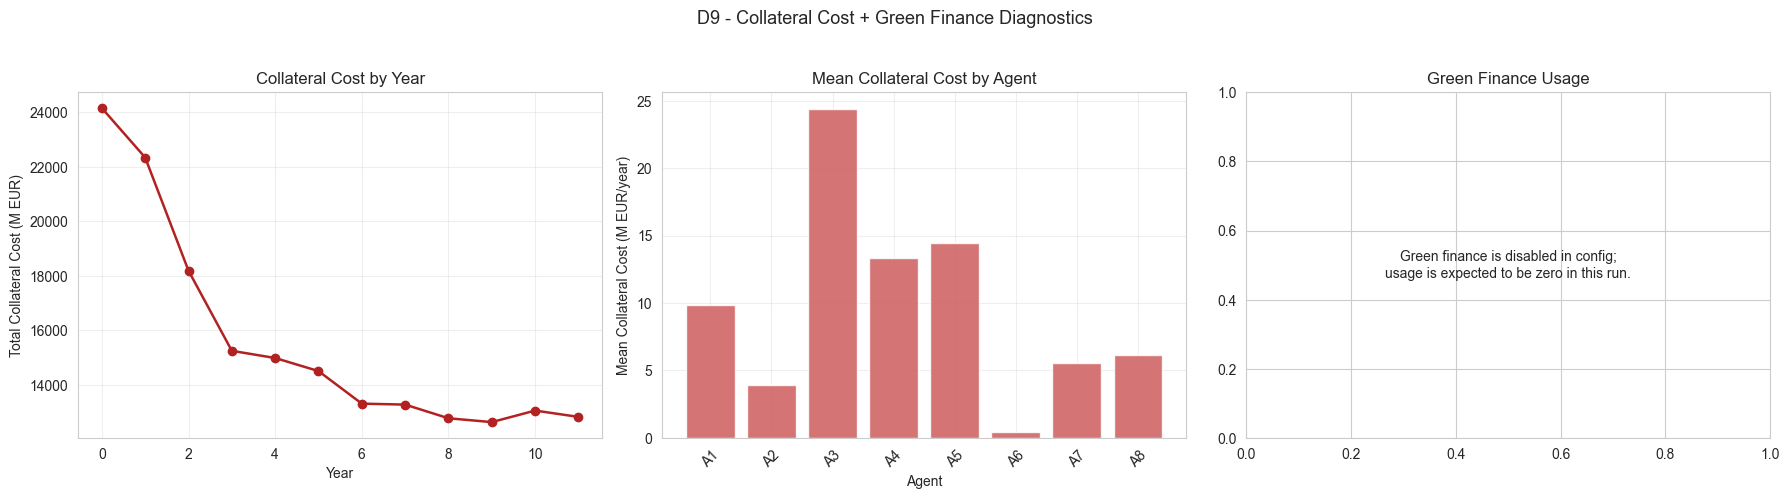

D9 SUMMARY - COLLATERAL + GREEN FINANCE
Collateral columns found: 8
Total collateral cost in window: 187334.969 M EUR
Mean collateral cost per simulated year: 15611.247 M EUR
Green finance enabled in config: False
Green finance is disabled, so usage is expected to be zero.


In [19]:
# ── D9: Green Finance + Collateral Cost Check ─────────────────────────────
import re
import yaml

def _extract_agent_ids(df, stem):
    rx = re.compile(rf"^{re.escape(stem)}_A(\d+)$")
    ids = []
    for c in df.columns:
        m = rx.match(c)
        if m:
            ids.append(int(m.group(1)))
    return sorted(set(ids))

def _green_finance_enabled_from_config():
    if "config" in globals() and isinstance(config, dict):
        return bool(config.get("green_finance", {}).get("enabled", False))
    if "CONFIG_PATH" in globals():
        try:
            with open(CONFIG_PATH, encoding="utf-8") as f:
                cfg = yaml.safe_load(f) or {}
            return bool(cfg.get("green_finance", {}).get("enabled", False))
        except Exception:
            return False
    return False

if "recent_yr" not in globals():
    raise RuntimeError("Run the 'Load & Prepare Data' cell first.")

# 1) Collateral columns from year-level CSV
coll_agent_ids = _extract_agent_ids(recent_yr, "collateral_cost")
coll_cols = [f"collateral_cost_A{i}" for i in coll_agent_ids if f"collateral_cost_A{i}" in recent_yr.columns]

# 2) Green-finance usage columns (if present)
gf_source_df = recent_yr
gf_source_name = "year_log"
gf_cols = [
    c for c in recent_yr.columns
    if ("green_loan" in c.lower() or "loan_interest" in c.lower() or "green_finance" in c.lower())
]

if (not gf_cols) and ("eval_df" in globals()) and isinstance(eval_df, pd.DataFrame):
    gf_eval_cols = [
        c for c in eval_df.columns
        if ("green_loan" in c.lower() or "loan_interest" in c.lower() or "green_finance" in c.lower())
    ]
    if gf_eval_cols:
        gf_cols = gf_eval_cols
        gf_source_df = eval_df
        gf_source_name = "eval_df"

gf_enabled_cfg = _green_finance_enabled_from_config()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# Panel A: system collateral trend by year
ax = axes[0]
if coll_cols:
    coll_total_by_year = recent_yr.groupby("year")[coll_cols].sum().sum(axis=1)
    ax.plot(coll_total_by_year.index, coll_total_by_year.values, "o-", color="firebrick", lw=1.8)
    ax.set_title("Collateral Cost by Year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Total Collateral Cost (M EUR)")
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, "No collateral_cost_A* columns found", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Collateral Cost by Year")

# Panel B: mean collateral by participant
ax = axes[1]
if coll_cols:
    coll_means = [recent_yr[c].mean() for c in coll_cols]
    labels = [f"A{i}" for i in coll_agent_ids]
    ax.bar(labels, coll_means, color="indianred", alpha=0.85)
    ax.set_title("Mean Collateral Cost by Agent")
    ax.set_xlabel("Agent")
    ax.set_ylabel("Mean Collateral Cost (M EUR/year)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, "Collateral not logged in this run", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Mean Collateral Cost by Agent")

# Panel C: green-finance usage/interest (if available)
ax = axes[2]
if gf_cols and ("year" in gf_source_df.columns):
    gf_total_by_year = gf_source_df.groupby("year")[gf_cols].sum().sum(axis=1)
    ax.plot(gf_total_by_year.index, gf_total_by_year.values, "o-", color="seagreen", lw=1.8)
    ax.set_title(f"Green Finance Usage ({gf_source_name})")
    ax.set_xlabel("Year")
    ax.set_ylabel("Total Green-Finance Metric")
    ax.grid(True, alpha=0.3)
elif gf_cols:
    gf_total = gf_source_df[gf_cols].sum().sum()
    ax.bar(["total"], [gf_total], color="seagreen", alpha=0.85)
    ax.set_title(f"Green Finance Usage ({gf_source_name})")
    ax.set_ylabel("Total Green-Finance Metric")
    ax.grid(True, alpha=0.3)
else:
    if gf_enabled_cfg:
        msg = "Green finance enabled in config, but no\nusage/interest columns were logged.\nCollateral checks remain available."
    else:
        msg = "Green finance is disabled in config;\nusage is expected to be zero in this run."
    ax.text(0.5, 0.5, msg, ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Green Finance Usage")

plt.suptitle("D9 - Collateral Cost + Green Finance Diagnostics", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

# Console summary
print("=" * 100)
print("D9 SUMMARY - COLLATERAL + GREEN FINANCE")
print("=" * 100)

if coll_cols:
    coll_total = float(recent_yr[coll_cols].sum().sum())
    coll_mean_year = float(recent_yr.groupby("year")[coll_cols].sum().sum(axis=1).mean())
    print(f"Collateral columns found: {len(coll_cols)}")
    print(f"Total collateral cost in window: {coll_total:.3f} M EUR")
    print(f"Mean collateral cost per simulated year: {coll_mean_year:.3f} M EUR")
else:
    print("Collateral: no collateral_cost_A* columns found in year_log CSV.")

if gf_cols:
    gf_total = float(gf_source_df[gf_cols].sum().sum())
    print(f"Green-finance columns found ({gf_source_name}): {len(gf_cols)}")
    print(f"Total green-finance metric in available data: {gf_total:.3f}")
    print("Columns:")
    for c in gf_cols:
        print(f"  - {c}")
else:
    print(f"Green finance enabled in config: {gf_enabled_cfg}")
    if gf_enabled_cfg:
        print("No green-loan usage/interest columns are currently logged in this run.")
        print("If needed, run an instrumented evaluation cell that records company.green_loan_utilized each year.")
    else:
        print("Green finance is disabled, so usage is expected to be zero.")

### D9b. Runtime Probe Fallback (Works Even With Old CSV Logs)

Runs a short simulation directly from the environment and reports:
- total collateral cost per year
- total green-loan utilization per year
- total green-loan interest cost per year

Use this when `year_log_s*.csv` does not contain collateral or green-finance columns.

Market calibration: 8 participants, emissions=20.7 Mt, cap=23.2 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.93, A2=1.91, A3=1.72, A4=1.42, A5=1.16, A6=1.13, A7=0.70, A8=0.81
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.78 MtCO2.


,episode,year,collateral_total,collateral_learners,collateral_bots,green_loan_util_total,green_loan_interest_total
0,0,0,59.852267,59.852267,0.0,0.0,0.0
1,0,1,83.885340,83.885340,0.0,0.0,0.0
2,0,2,37.905151,37.905151,0.0,0.0,0.0
3,0,3,58.276854,58.276854,0.0,0.0,0.0
4,0,4,70.258285,70.258285,0.0,0.0,0.0
5,0,5,91.072823,91.072823,0.0,0.0,0.0
6,0,6,31.091590,31.091590,0.0,0.0,0.0
7,0,7,47.771885,47.771885,0.0,0.0,0.0
8,0,8,55.197311,55.197311,0.0,0.0,0.0
9,0,9,27.610623,27.610623,0.0,0.0,0.0


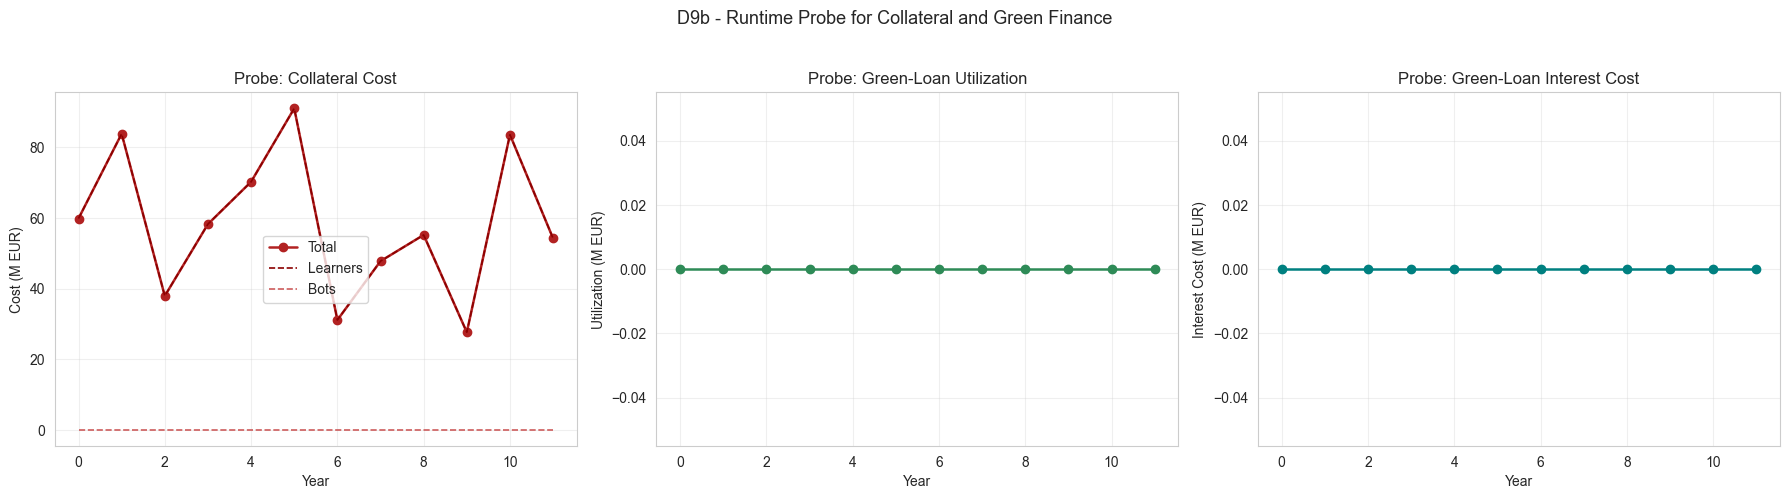

D9B PROBE SUMMARY
Probe episodes: 1
Mean yearly collateral total: 58.3954 M EUR
Mean yearly green-loan utilization total: 0.0000 M EUR
Mean yearly green-loan interest total: 0.000000 M EUR


In [20]:
# ── D9b: Runtime probe for collateral + green-finance usage ───────────────
import copy
import yaml
from src.environment.ets_environment import ETSEnvironment

RUN_D9_PROBE = True         # set False to skip probe execution
PROBE_SEED = 2026
PROBE_EPISODES = 1           # keep small for quick diagnostics

def _load_probe_config():
    if "config" in globals() and isinstance(config, dict):
        return copy.deepcopy(config)
    if "CONFIG_PATH" in globals():
        with open(CONFIG_PATH, encoding="utf-8") as f:
            return yaml.safe_load(f)
    raise RuntimeError("Could not resolve config. Run setup/data-loading cells first.")

if not RUN_D9_PROBE:
    print("D9b probe skipped (RUN_D9_PROBE=False).")
else:
    probe_cfg = _load_probe_config()
    rng = np.random.default_rng(PROBE_SEED)
    probe_rows = []

    for ep in range(PROBE_EPISODES):
        env_probe = ETSEnvironment(probe_cfg, seed=PROBE_SEED + ep)
        obs1_probe, _ = env_probe.reset(seed=PROBE_SEED + ep)

        aq = probe_cfg["auction"]
        inv = probe_cfg["investment"]
        tr = probe_cfg.get("trading", {})
        sec_price_min = float(tr.get("sec_price_min", 30.0))
        sec_price_max = float(tr.get("sec_price_max_mult", 2.0)) * float(probe_cfg["penalty"]["rate"])

        for y in range(probe_cfg["simulation"]["n_years"]):
            auction_actions_probe = rng.uniform(
                [aq["price_min"], aq.get("qty_mult_low", 0.3), 0.0, -1.0, -1.0, -1.0],
                [aq["price_max"], aq.get("qty_mult_high", 2.0), inv["max_invest_frac"], 1.0, 1.0, 1.0],
                size=(env_probe.n_agents, 6),
            ).astype(np.float32)

            obs2_probe, _ = env_probe.step_auction(auction_actions_probe)

            secondary_actions_probe = rng.uniform(
                [sec_price_min, -aq["quantity_max"]],
                [sec_price_max, aq["quantity_max"]],
                size=(env_probe.n_agents, 2),
            ).astype(np.float32)

            obs1_probe, rewards_probe, done_probe, _, info_probe = env_probe.step_secondary(secondary_actions_probe)
            yl_probe = info_probe.get("year_log", {})

            collateral_arr = np.array(yl_probe.get("collateral_costs", [0.0] * env_probe.n_total), dtype=float)
            loan_util_arr = np.array([c.green_loan_utilized for c in env_probe.companies], dtype=float)
            loan_interest_arr = np.array([c.compute_green_loan_cost() for c in env_probe.companies], dtype=float)

            probe_rows.append({
                "episode": ep,
                "year": y,
                "collateral_total": float(collateral_arr.sum()),
                "collateral_learners": float(collateral_arr[:env_probe.n_agents].sum()),
                "collateral_bots": float(collateral_arr[env_probe.n_agents:].sum()),
                "green_loan_util_total": float(loan_util_arr.sum()),
                "green_loan_interest_total": float(loan_interest_arr.sum()),
            })

            if done_probe:
                break

    d9b_probe_df = pd.DataFrame(probe_rows)
    display(d9b_probe_df.head(12))

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

    by_year = d9b_probe_df.groupby("year", as_index=True).mean(numeric_only=True)

    ax = axes[0]
    ax.plot(by_year.index, by_year["collateral_total"], "o-", color="firebrick", lw=1.8, label="Total")
    ax.plot(by_year.index, by_year["collateral_learners"], "--", color="darkred", lw=1.2, label="Learners")
    ax.plot(by_year.index, by_year["collateral_bots"], "--", color="indianred", lw=1.2, label="Bots")
    ax.set_title("Probe: Collateral Cost")
    ax.set_xlabel("Year")
    ax.set_ylabel("Cost (M EUR)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(by_year.index, by_year["green_loan_util_total"], "o-", color="seagreen", lw=1.8)
    ax.set_title("Probe: Green-Loan Utilization")
    ax.set_xlabel("Year")
    ax.set_ylabel("Utilization (M EUR)")
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax.plot(by_year.index, by_year["green_loan_interest_total"], "o-", color="teal", lw=1.8)
    ax.set_title("Probe: Green-Loan Interest Cost")
    ax.set_xlabel("Year")
    ax.set_ylabel("Interest Cost (M EUR)")
    ax.grid(True, alpha=0.3)

    plt.suptitle("D9b - Runtime Probe for Collateral and Green Finance", fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()

    print("=" * 100)
    print("D9B PROBE SUMMARY")
    print("=" * 100)
    print(f"Probe episodes: {PROBE_EPISODES}")
    print(f"Mean yearly collateral total: {by_year['collateral_total'].mean():.4f} M EUR")
    print(f"Mean yearly green-loan utilization total: {by_year['green_loan_util_total'].mean():.4f} M EUR")
    print(f"Mean yearly green-loan interest total: {by_year['green_loan_interest_total'].mean():.6f} M EUR")

---
# Part II — Analytical: Agent Strategy Analysis

> *What strategies did the agents learn and why?*
>
> We decompose agent behaviour across the five decision phases:
> auction bidding, secondary-market trading, green investment,
> compliance/banking, and overall reward structure.

### A1. Auction Bidding Strategy

How agents bid in the primary EUA auction:
- **Price discovery** — do bids converge to a common clearing price?
- **Quantity strategy** — do agents bid for what they need or over/under-bid?
- **Archetype differences** — do coal-heavy agents bid differently from near-green?

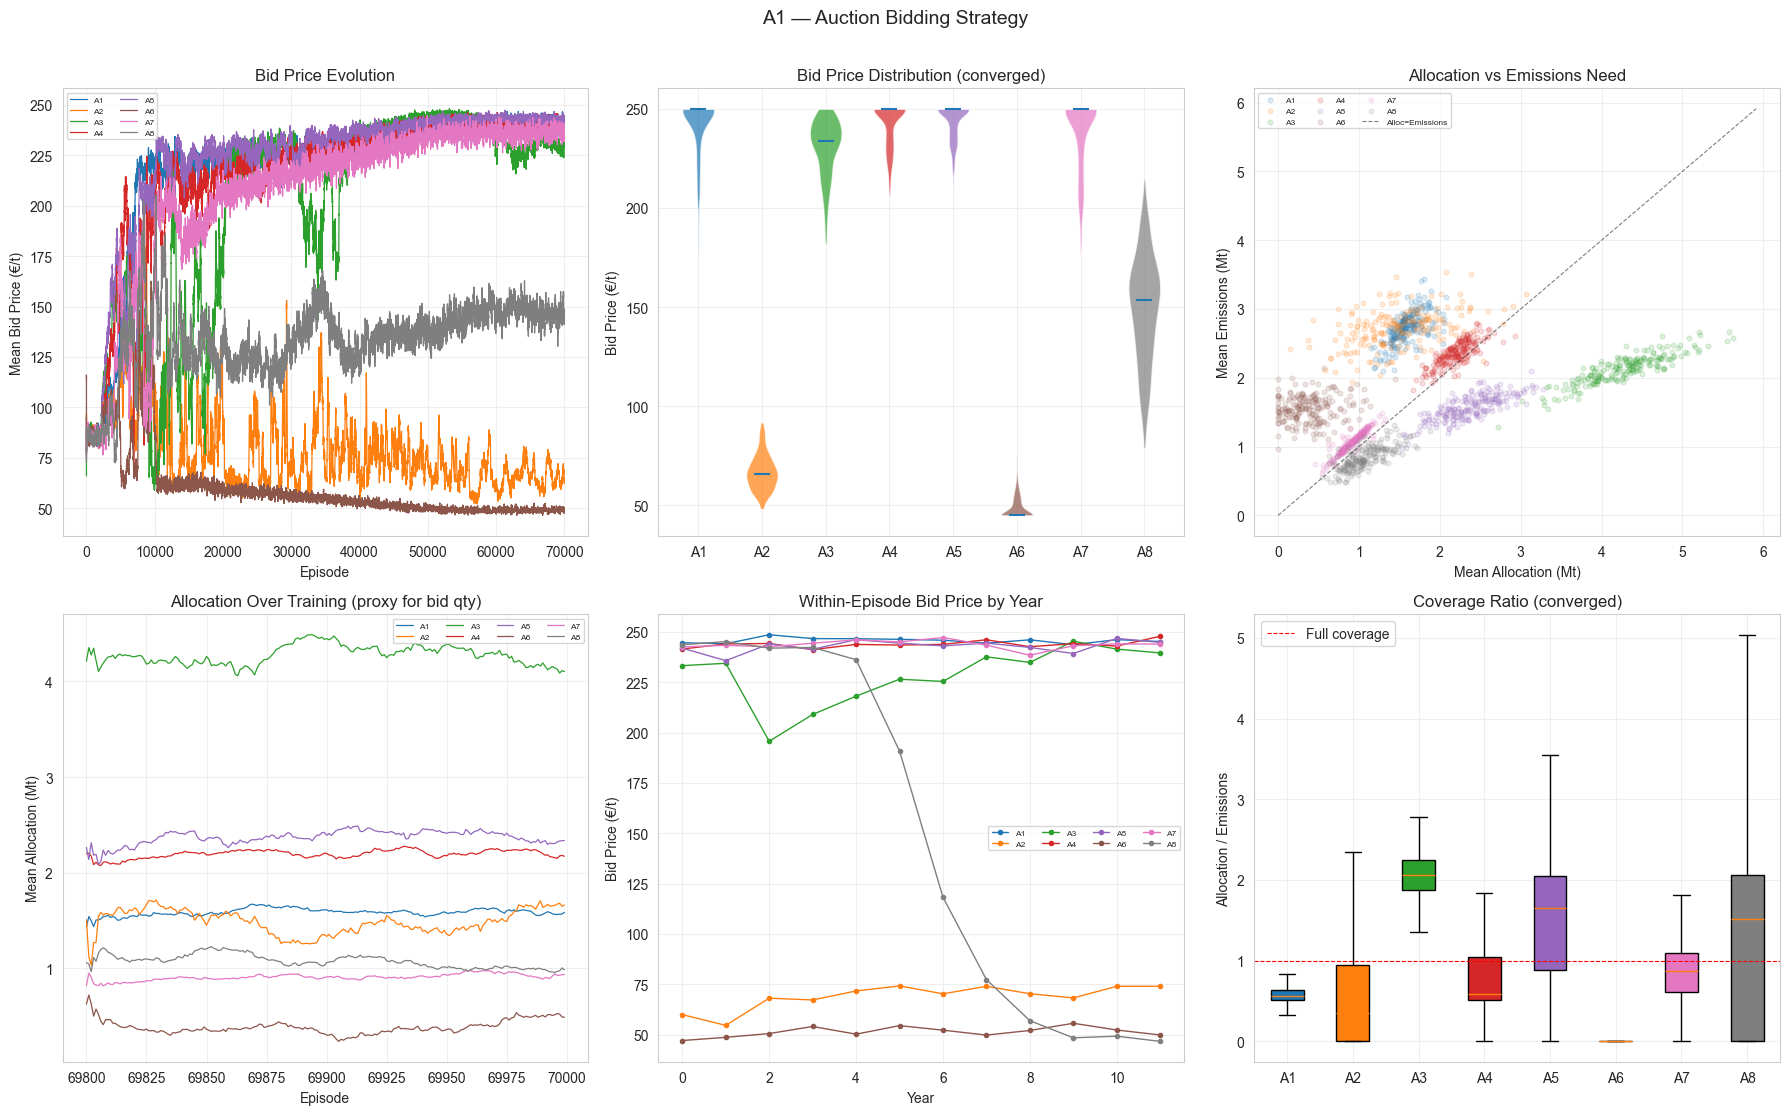

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Bid price evolution per agent
ax = axes[0, 0]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'bid_price_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.9, label=agent_labels[i])
ax.set_xlabel('Episode'); ax.set_ylabel('Mean Bid Price (\u20ac/t)')
ax.set_title('Bid Price Evolution'); ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

# 2 — Bid price distribution (converged)
ax = axes[0, 1]
bid_data = [recent_ep[f'bid_price_A{i+1}'].values for i in range(n_agents)]
parts = ax.violinplot(bid_data, positions=range(n_agents), showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(agent_colors[i]); pc.set_alpha(0.7)
ax.set_xticks(range(n_agents)); ax.set_xticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set_ylabel('Bid Price (\u20ac/t)')
ax.set_title('Bid Price Distribution (converged)'); ax.grid(True, alpha=0.3)

# 3 — Allocation vs Emissions scatter (converged)
ax = axes[0, 2]
for i in range(n_agents):
    allocs = recent_yr.groupby('episode')[f'alloc_A{i+1}'].mean()
    emiss = recent_yr.groupby('episode')[f'emissions_A{i+1}'].mean()
    ax.scatter(allocs, emiss, alpha=0.15, s=12, color=agent_colors[i], label=f'A{i+1}')
lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5, label='Alloc=Emissions')
ax.set_xlabel('Mean Allocation (Mt)'); ax.set_ylabel('Mean Emissions (Mt)')
ax.set_title('Allocation vs Emissions Need')
ax.legend(fontsize=6, ncol=3); ax.grid(True, alpha=0.3)

# 4 — Bid quantity evolution
ax = axes[1, 0]
for i in range(n_agents):
    alloc_roll = recent_yr.groupby('episode')[f'alloc_A{i+1}'].mean()
    alloc_smooth = alloc_roll.rolling(ROLL // 2, min_periods=1).mean()
    ax.plot(alloc_smooth.index, alloc_smooth.values, color=agent_colors[i], lw=0.9, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Mean Allocation (Mt)')
ax.set_title('Allocation Over Training (proxy for bid qty)'); ax.legend(fontsize=6, ncol=4)
ax.grid(True, alpha=0.3)

# 5 — Bid price by year within episode (converged)
ax = axes[1, 1]
for i in range(n_agents):
    bid_yr = recent_yr.groupby('year')[f'bid_price_A{i+1}'].mean()
    ax.plot(bid_yr.index, bid_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Bid Price (\u20ac/t)')
ax.set_title('Within-Episode Bid Price by Year')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Coverage ratio: allocation / emissions
ax = axes[1, 2]
cov_data = []
for i in range(n_agents):
    a = recent_yr[f'alloc_A{i+1}']
    e = recent_yr[f'emissions_A{i+1}'].replace(0, np.nan)
    cov_data.append((a / e).dropna().values)
bp = ax.boxplot(cov_data, tick_labels=[f'A{i+1}' for i in range(n_agents)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(agent_colors[i])
ax.axhline(1.0, color='red', ls='--', lw=0.8, label='Full coverage')
ax.set_ylabel('Allocation / Emissions')
ax.set_title('Coverage Ratio (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('A1 \u2014 Auction Bidding Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A2. Secondary Market Strategy

How agents trade on the secondary market:
- **Role evolution** — who becomes a net buyer vs seller over training?
- **Year-by-year patterns** — do roles shift within an episode as the cap tightens?
- **Price premiums** — secondary vs auction price spread
- **Cost/revenue** — who profits from secondary trading?

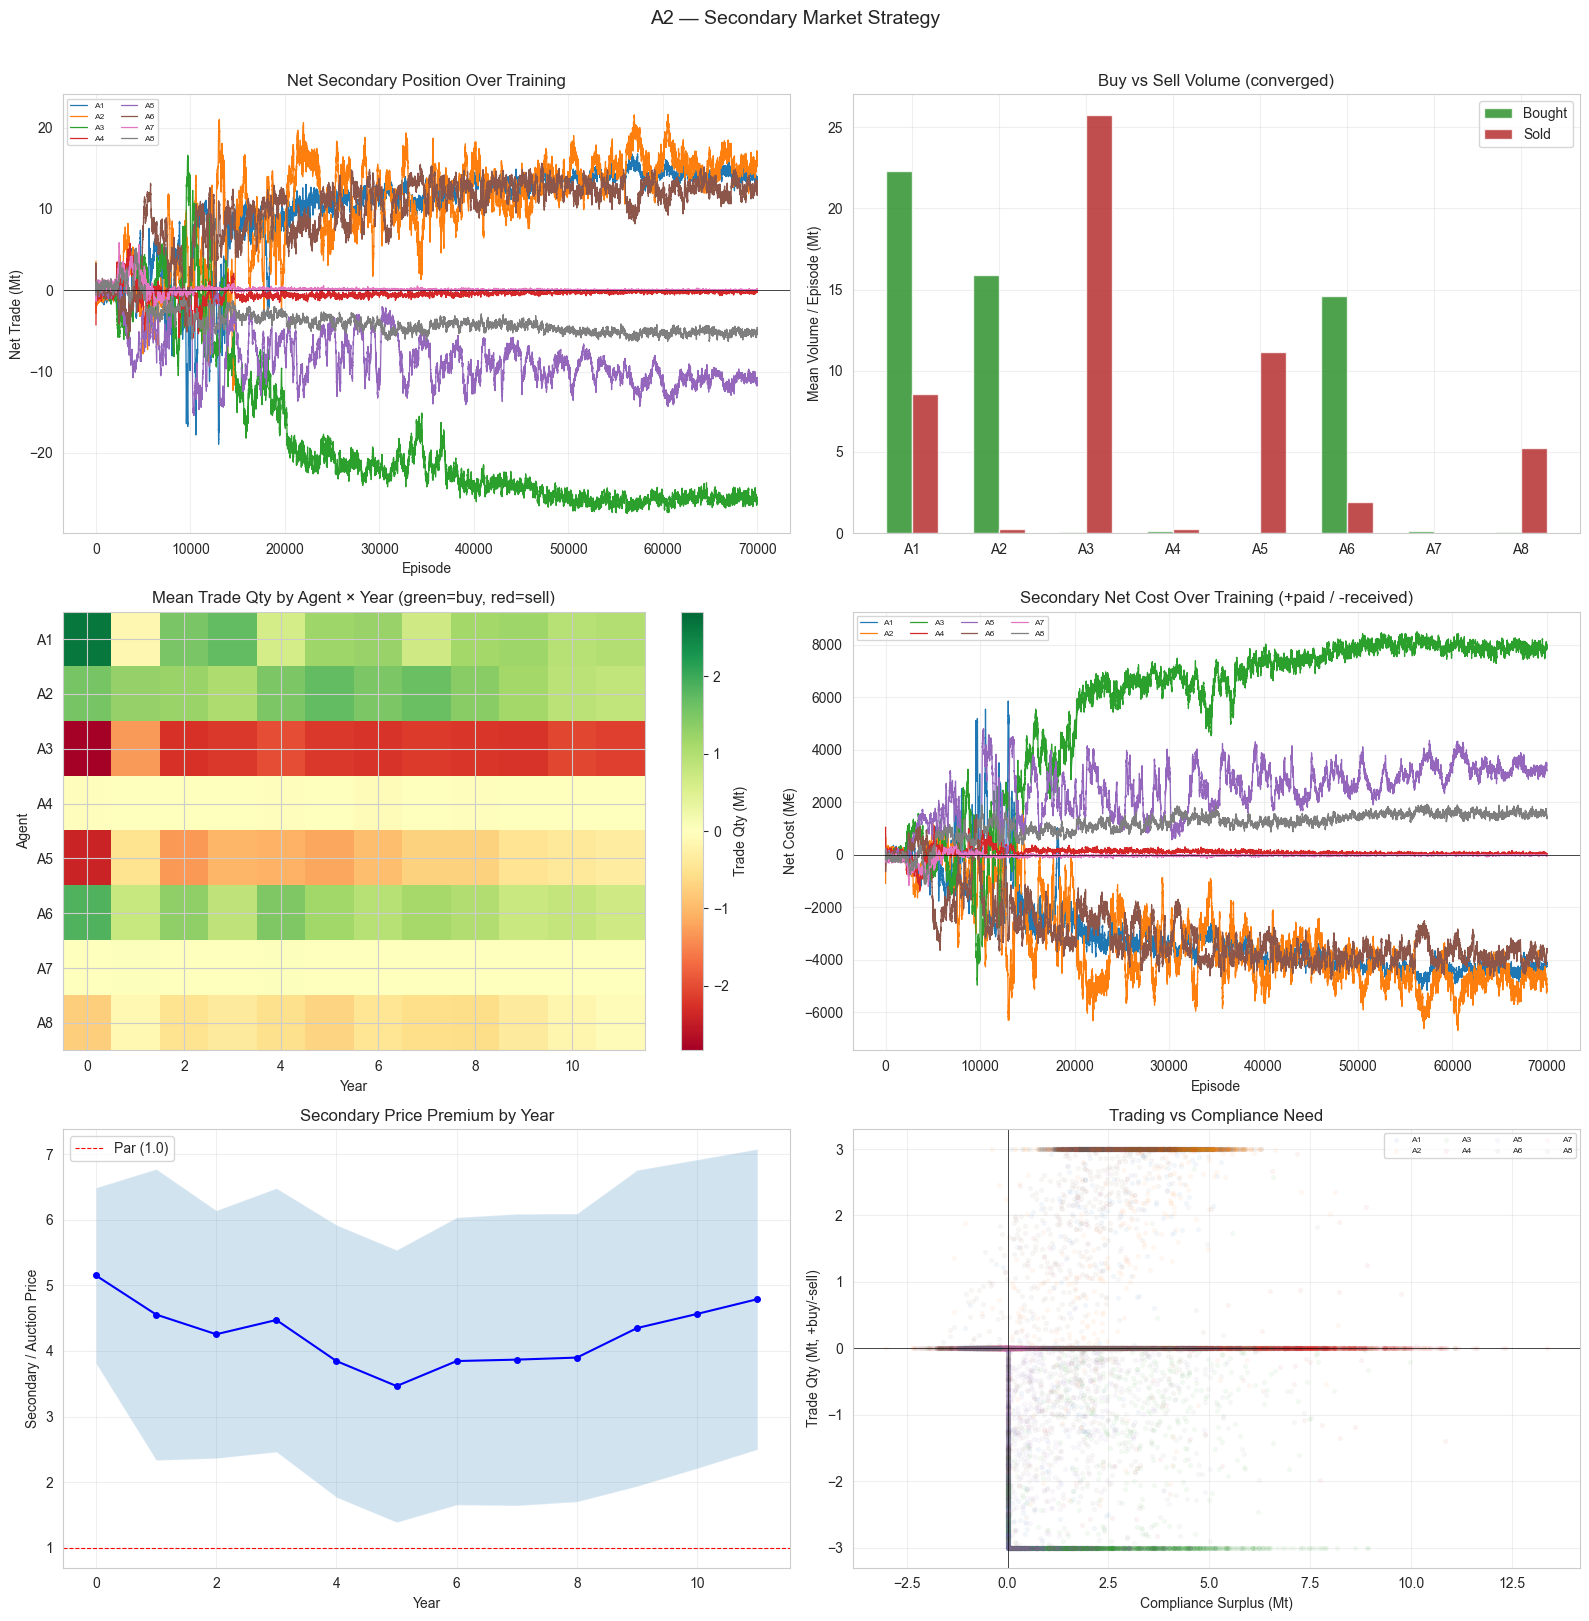

In [22]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# 1 — Net trade position over training (rolling)
ax = axes[0, 0]
for i in range(n_agents):
    net_trade = yr_df.groupby('episode')[f'trade_qty_A{i+1}'].sum()
    ax.plot(net_trade.index, net_trade.rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.9, label=agent_labels[i])
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Episode'); ax.set_ylabel('Net Trade (Mt)')
ax.set_title('Net Secondary Position Over Training')
ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

# 2 — Buy vs Sell volume per agent (converged)
ax = axes[0, 1]
buy_vols = []
sell_vols = []
for i in range(n_agents):
    tq = recent_yr[f'trade_qty_A{i+1}']
    buy_vols.append(tq[tq > 0.01].sum() / LAST_N)
    sell_vols.append(abs(tq[tq < -0.01].sum()) / LAST_N)
x = np.arange(n_agents)
ax.bar(x - 0.15, buy_vols, 0.3, color='forestgreen', alpha=0.8, label='Bought')
ax.bar(x + 0.15, sell_vols, 0.3, color='firebrick', alpha=0.8, label='Sold')
ax.set_xticks(x); ax.set_xticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set_ylabel('Mean Volume / Episode (Mt)')
ax.set_title('Buy vs Sell Volume (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

# 3 — Trade position by year within episode (heatmap)
ax = axes[1, 0]
trade_matrix = np.zeros((n_agents, n_years_per_ep))
for i in range(n_agents):
    trade_by_yr = recent_yr.groupby('year')[f'trade_qty_A{i+1}'].mean()
    trade_matrix[i, :len(trade_by_yr)] = trade_by_yr.values
vmax = max(abs(trade_matrix.min()), abs(trade_matrix.max()))
im = ax.imshow(trade_matrix, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
ax.set_xlabel('Year'); ax.set_ylabel('Agent')
ax.set_yticks(range(n_agents)); ax.set_yticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set_title('Mean Trade Qty by Agent \u00d7 Year (green=buy, red=sell)')
plt.colorbar(im, ax=ax, label='Trade Qty (Mt)')

# 4 — Net secondary cost over training
ax = axes[1, 1]
for i in range(n_agents):
    snet = yr_df.groupby('episode')[f'secondary_net_A{i+1}'].sum()
    ax.plot(snet.index, snet.rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.9, label=f'A{i+1}')
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Episode'); ax.set_ylabel('Net Cost (M\u20ac)')
ax.set_title('Secondary Net Cost Over Training (+paid / -received)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Secondary price premium over auction
ax = axes[2, 0]
premium = recent_yr['secondary_price'] / recent_yr['clearing_price'].replace(0, np.nan)
premium_yr = premium.groupby(recent_yr['year']).agg(['mean', 'std'])
ax.plot(premium_yr.index, premium_yr['mean'], 'b-o', ms=4, lw=1.5)
ax.fill_between(premium_yr.index,
                premium_yr['mean'] - premium_yr['std'],
                premium_yr['mean'] + premium_yr['std'], alpha=0.2)
ax.axhline(1.0, color='red', ls='--', lw=0.8, label='Par (1.0)')
ax.set_xlabel('Year'); ax.set_ylabel('Secondary / Auction Price')
ax.set_title('Secondary Price Premium by Year'); ax.legend(); ax.grid(True, alpha=0.3)

# 6 — Trade qty vs compliance surplus (who trades based on need?)
ax = axes[2, 1]
if 'compliance_surplus_A1' in recent_yr.columns:
    for i in range(n_agents):
        ax.scatter(recent_yr[f'compliance_surplus_A{i+1}'],
                   recent_yr[f'trade_qty_A{i+1}'],
                   alpha=0.04, s=8, color=agent_colors[i], label=f'A{i+1}')
    ax.axhline(0, color='black', ls='-', lw=0.5)
    ax.axvline(0, color='black', ls='-', lw=0.5)
    ax.set_xlabel('Compliance Surplus (Mt)')
    ax.set_ylabel('Trade Qty (Mt, +buy/-sell)')
    ax.set_title('Trading vs Compliance Need')
    ax.legend(fontsize=6, ncol=4)
else:
    ax.text(0.5, 0.5, 'compliance_surplus not logged', ha='center', va='center',
            transform=ax.transAxes)
ax.grid(True, alpha=0.3)

plt.suptitle('A2 \u2014 Secondary Market Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A3. Green Transition Strategy

Investment patterns in renewable energy:
- **Transition speed** — how quickly does each archetype green its portfolio?
- **Investment intensity** — how aggressively do agents invest?
- **Technology preference** — onshore wind, offshore wind, or solar?
- **Construction pipeline** — queuing effects and timing

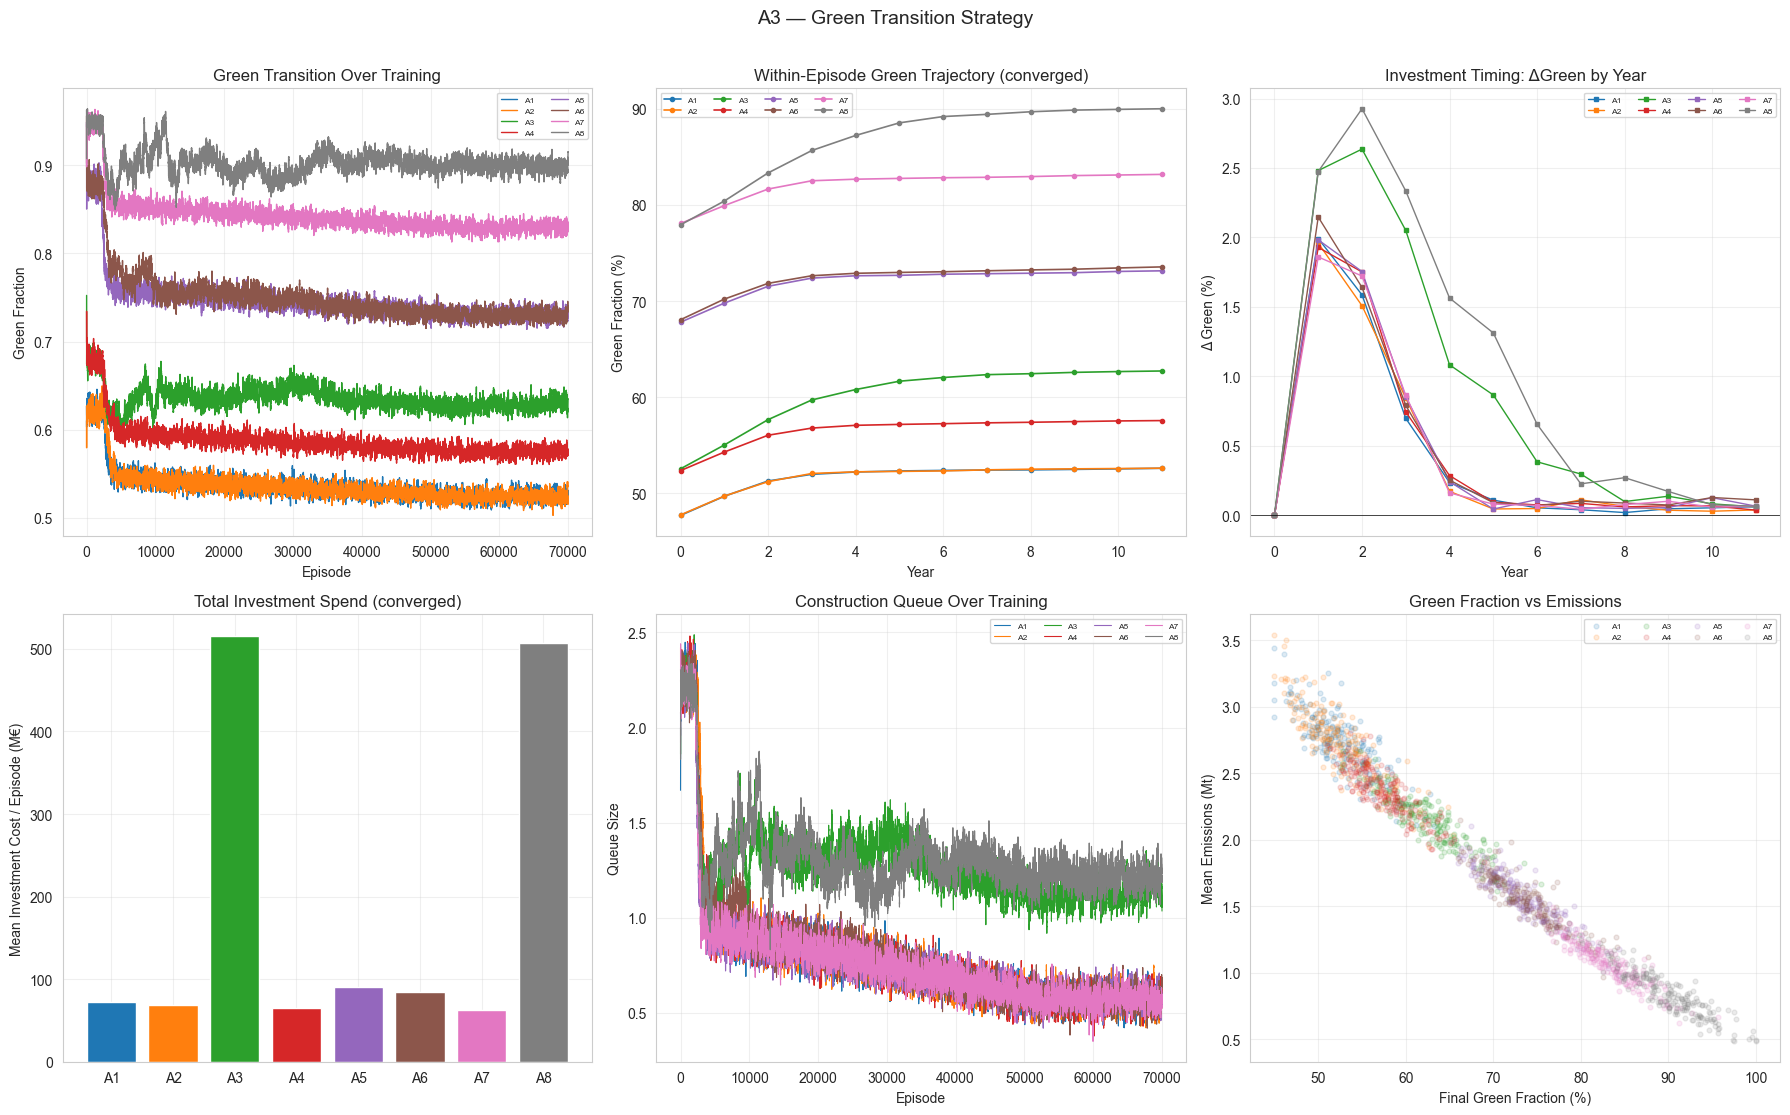

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Green fraction evolution over training
ax = axes[0, 0]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'green_frac_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=1, label=agent_labels[i])
ax.set_xlabel('Episode'); ax.set_ylabel('Green Fraction')
ax.set_title('Green Transition Over Training')
ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

# 2 — Green fraction by year within episode (converged)
ax = axes[0, 1]
for i in range(n_agents):
    gf_yr = recent_yr.groupby('year')[f'green_frac_A{i+1}'].mean()
    ax.plot(gf_yr.index, gf_yr.values * 100, color=agent_colors[i], marker='o', ms=3,
            lw=1.2, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Green Fraction (%)')
ax.set_title('Within-Episode Green Trajectory (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Delta green by year (when do agents invest?)
ax = axes[0, 2]
for i in range(n_agents):
    dg_yr = recent_yr.groupby('year')[f'delta_green_A{i+1}'].mean() * 100
    ax.plot(dg_yr.index, dg_yr.values, color=agent_colors[i], marker='s', ms=3,
            lw=1, label=f'A{i+1}')
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('\u0394 Green (%)')
ax.set_title('Investment Timing: \u0394Green by Year')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Investment cost per agent (converged)
ax = axes[1, 0]
inv_means = [recent_yr.groupby('episode')[f'invest_cost_A{i+1}'].sum().mean()
             for i in range(n_agents)]
ax.bar([f'A{i+1}' for i in range(n_agents)], inv_means, color=agent_colors)
ax.set_ylabel('Mean Investment Cost / Episode (M\u20ac)')
ax.set_title('Total Investment Spend (converged)'); ax.grid(True, alpha=0.3)

# 5 — Construction queue over training
ax = axes[1, 1]
for i in range(n_agents):
    col = f'queue_size_A{i+1}'
    if col in ep_df.columns:
        ax.plot(ep_df['episode'], ep_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Queue Size')
ax.set_title('Construction Queue Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Green fraction vs emissions (converged)
ax = axes[1, 2]
for i in range(n_agents):
    gf = recent_yr.groupby('episode')[f'green_frac_A{i+1}'].last()
    em = recent_yr.groupby('episode')[f'emissions_A{i+1}'].mean()
    ax.scatter(gf * 100, em, alpha=0.15, s=12, color=agent_colors[i], label=f'A{i+1}')
ax.set_xlabel('Final Green Fraction (%)'); ax.set_ylabel('Mean Emissions (Mt)')
ax.set_title('Green Fraction vs Emissions')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A3 \u2014 Green Transition Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A4. Compliance & Banking Strategy

How agents manage their allowance portfolio:
- **Banking** — accumulating surplus for future compliance
- **Shortfall avoidance** — learning to stay compliant
- **Risk management** — holdings buffer vs cost minimization

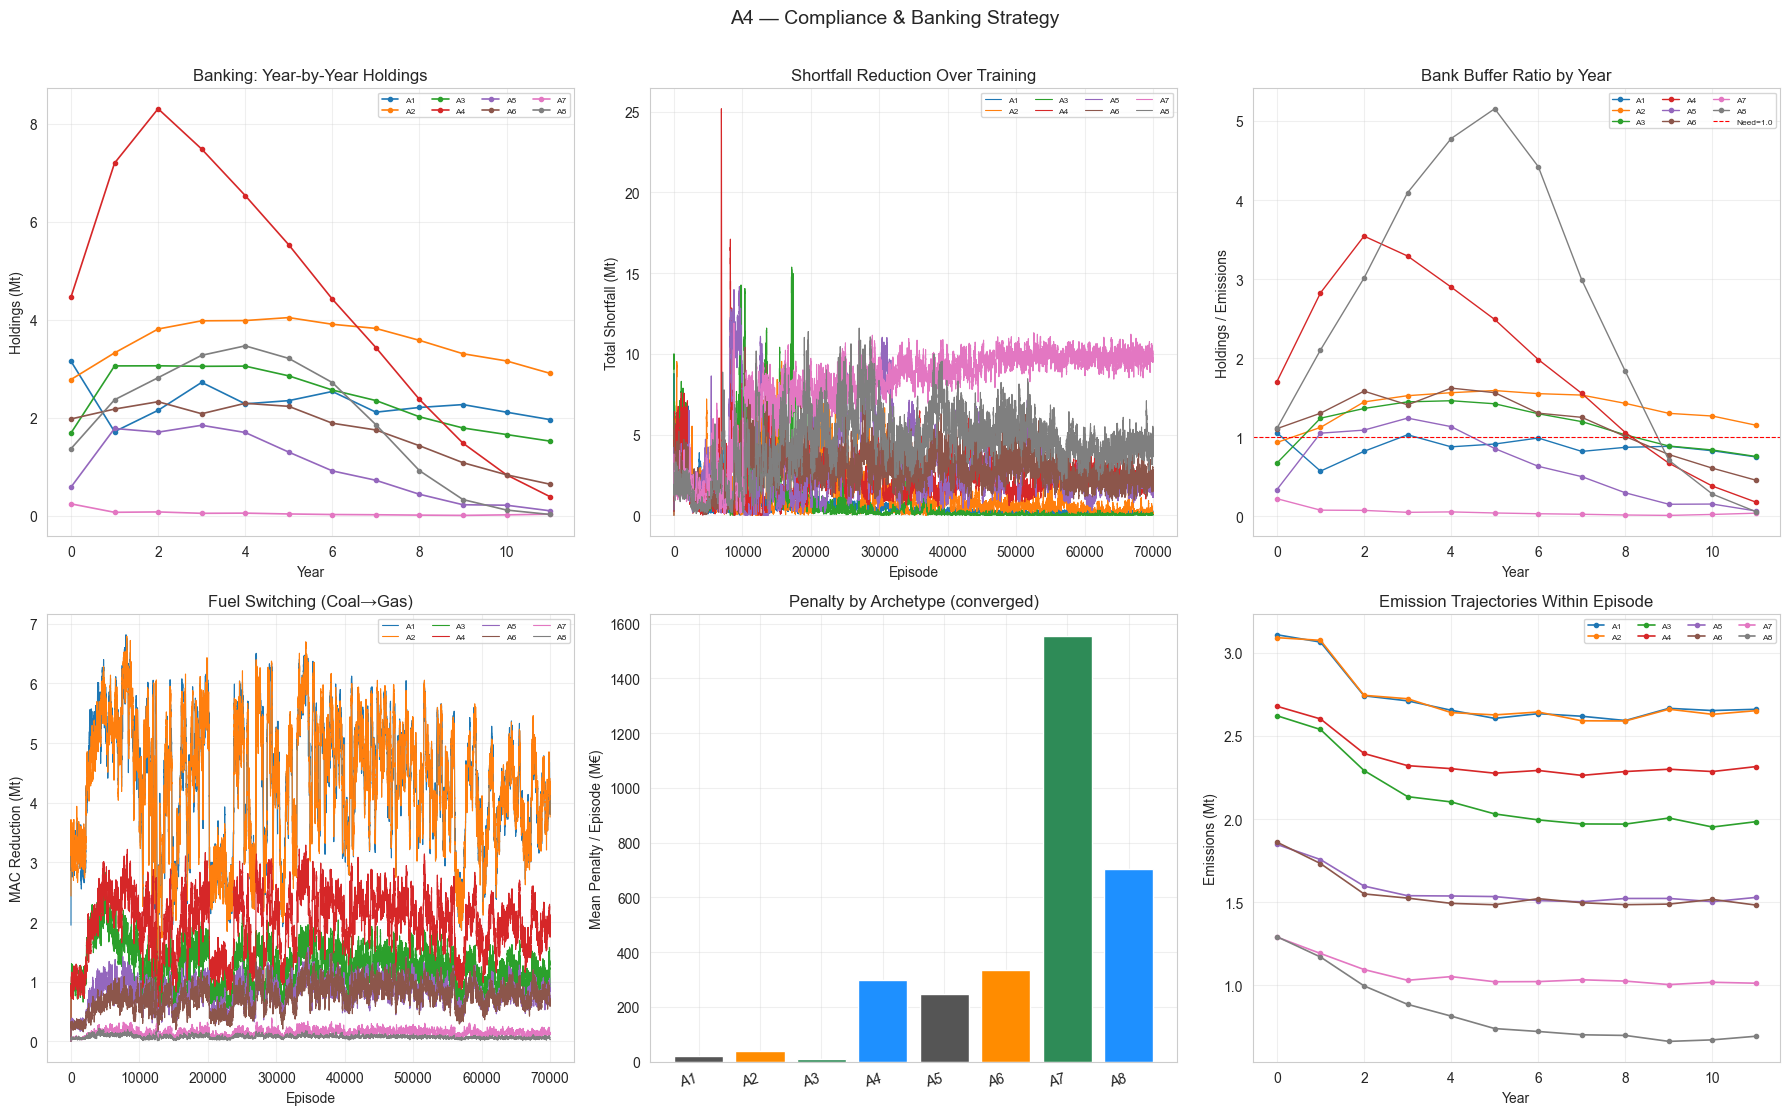

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Holdings trajectory by year (converged)
ax = axes[0, 0]
for i in range(n_agents):
    h_yr = recent_yr.groupby('year')[f'holdings_A{i+1}'].mean()
    ax.plot(h_yr.index, h_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1.2, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Holdings (Mt)')
ax.set_title('Banking: Year-by-Year Holdings')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 2 — Shortfall per agent over training
ax = axes[0, 1]
for i in range(n_agents):
    sf = ep_df[f'shortfall_A{i+1}'].rolling(ROLL, min_periods=1).mean()
    ax.plot(ep_df['episode'], sf, color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Total Shortfall (Mt)')
ax.set_title('Shortfall Reduction Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Holdings vs emissions need (buffer ratio)
ax = axes[0, 2]
for i in range(n_agents):
    h = recent_yr[f'holdings_A{i+1}']
    e = recent_yr[f'emissions_A{i+1}'].replace(0, np.nan)
    buffer = (h / e).dropna()
    buf_yr = buffer.groupby(recent_yr.loc[buffer.index, 'year']).mean()
    ax.plot(buf_yr.index, buf_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1, label=f'A{i+1}')
ax.axhline(1.0, color='red', ls='--', lw=0.8, label='Need=1.0')
ax.set_xlabel('Year'); ax.set_ylabel('Holdings / Emissions')
ax.set_title('Bank Buffer Ratio by Year')
ax.legend(fontsize=6, ncol=3); ax.grid(True, alpha=0.3)

# 4 — MAC fuel-switching usage
ax = axes[1, 0]
mac_cols_ep = [f'total_mac_reduction_A{i+1}' for i in range(n_agents)
               if f'total_mac_reduction_A{i+1}' in ep_df.columns]
if mac_cols_ep:
    for i, col in enumerate(mac_cols_ep):
        ax.plot(ep_df['episode'], ep_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
    ax.set_xlabel('Episode'); ax.set_ylabel('MAC Reduction (Mt)')
    ax.set_title('Fuel Switching (Coal\u2192Gas)')
    ax.legend(fontsize=6, ncol=4)
else:
    ax.text(0.5, 0.5, 'MAC data not available', ha='center', va='center',
            transform=ax.transAxes)
ax.grid(True, alpha=0.3)

# 5 — Penalty by archetype
ax = axes[1, 1]
pen_by_arch = {}
for i in range(n_agents):
    arch = agent_labels[i].split('(')[1].rstrip(')') if '(' in agent_labels[i] else f'A{i+1}'
    pen = recent_ep[f'penalty_A{i+1}'].mean()
    pen_by_arch.setdefault(arch, []).append(pen)
arch_names = list(pen_by_arch.keys())
arch_means = [np.mean(v) for v in pen_by_arch.values()]
ax.bar(arch_names, arch_means, color=['#555555', '#FF8C00', '#2E8B57', '#1E90FF'][:len(arch_names)])
ax.set_ylabel('Mean Penalty / Episode (M\u20ac)')
ax.set_title('Penalty by Archetype (converged)')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
ax.grid(True, alpha=0.3)

# 6 — Emissions trajectory by year (converged)
ax = axes[1, 2]
for i in range(n_agents):
    em_yr = recent_yr.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(em_yr.index, em_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1.2, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Emissions (Mt)')
ax.set_title('Emission Trajectories Within Episode')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A4 \u2014 Compliance & Banking Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A5. Reward Decomposition & Cost Structure

What drives agent rewards? Decompose into cost components to understand
the economic trade-offs agents face.

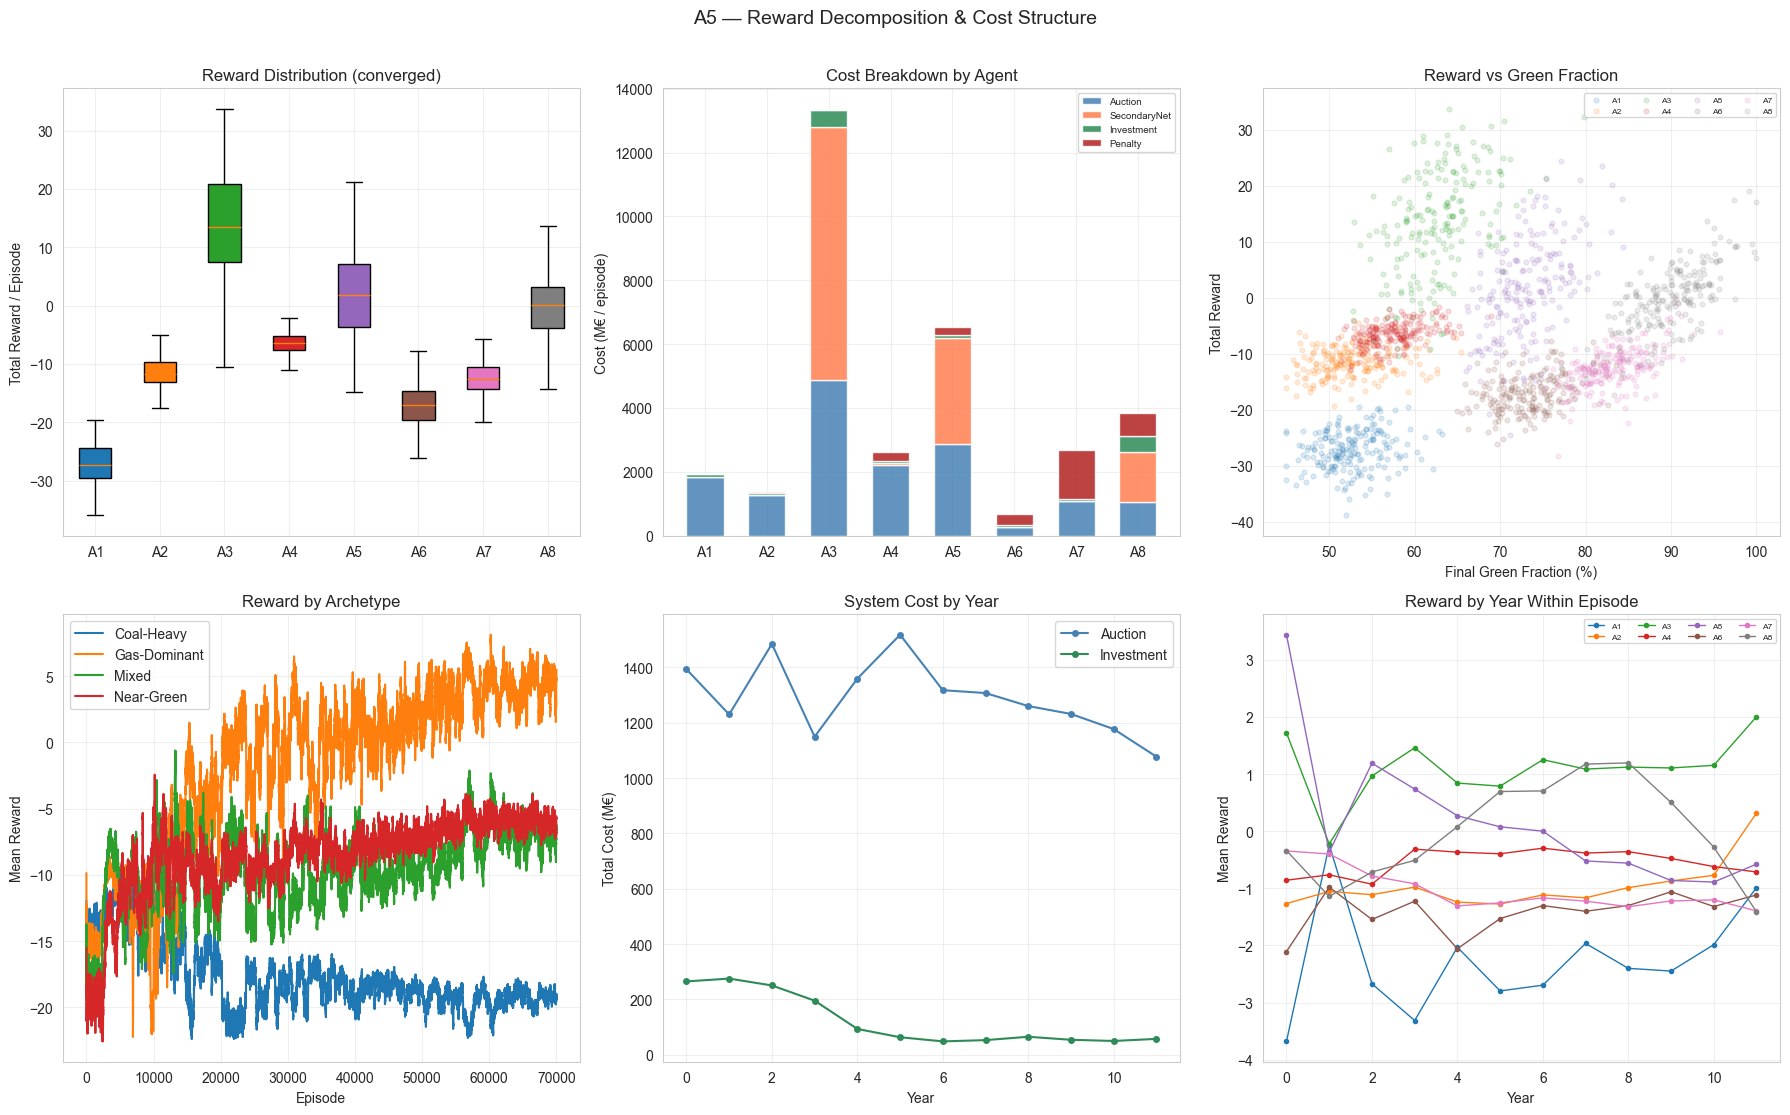

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Reward distribution (converged)
ax = axes[0, 0]
rew_data = [recent_ep[f'reward_A{i+1}'].values for i in range(n_agents)]
bp = ax.boxplot(rew_data, tick_labels=[f'A{i+1}' for i in range(n_agents)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(agent_colors[i])
ax.set_ylabel('Total Reward / Episode')
ax.set_title('Reward Distribution (converged)'); ax.grid(True, alpha=0.3)

# 2 — Cost breakdown per agent (converged means)
ax = axes[0, 1]
cost_components = {}
for comp, col_tmpl in [('Auction', 'auction_cost_A{}'),
                        ('SecondaryNet', 'secondary_net_A{}'),
                        ('Investment', 'invest_cost_A{}'),
                        ('Penalty', 'penalty_A{}')]:
    means = []
    for i in range(n_agents):
        col = col_tmpl.format(i+1)
        if col in recent_yr.columns:
            means.append(recent_yr.groupby('episode')[col].sum().mean())
        else:
            means.append(0)
    cost_components[comp] = means

x = np.arange(n_agents)
bottom = np.zeros(n_agents)
comp_colors = {'Auction': 'steelblue', 'SecondaryNet': 'coral',
               'Investment': 'seagreen', 'Penalty': 'firebrick'}
for comp, vals in cost_components.items():
    vals_pos = np.maximum(vals, 0)
    ax.bar(x, vals_pos, 0.6, bottom=bottom, label=comp, color=comp_colors[comp], alpha=0.85)
    bottom += vals_pos
ax.set_xticks(x); ax.set_xticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set_ylabel('Cost (M\u20ac / episode)')
ax.set_title('Cost Breakdown by Agent'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# 3 — Reward vs green fraction
ax = axes[0, 2]
for i in range(n_agents):
    gf = recent_ep[f'green_frac_A{i+1}']
    rw = recent_ep[f'reward_A{i+1}']
    ax.scatter(gf * 100, rw, alpha=0.15, s=12, color=agent_colors[i], label=f'A{i+1}')
ax.set_xlabel('Final Green Fraction (%)'); ax.set_ylabel('Total Reward')
ax.set_title('Reward vs Green Fraction')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Reward by archetype over training
ax = axes[1, 0]
n_per_arch = n_agents // 4
for a_idx, arch in enumerate(_base_archetypes):
    agent_ids = list(range(a_idx * n_per_arch, (a_idx + 1) * n_per_arch))
    if not agent_ids:
        continue
    arch_rew = sum(ep_df[f'reward_A{i+1}'] for i in agent_ids) / len(agent_ids)
    ax.plot(ep_df['episode'], arch_rew.rolling(ROLL, min_periods=1).mean(),
            lw=1.5, label=arch)
ax.set_xlabel('Episode'); ax.set_ylabel('Mean Reward')
ax.set_title('Reward by Archetype'); ax.legend(); ax.grid(True, alpha=0.3)

# 5 — Cost by year within episode
ax = axes[1, 1]
if 'auction_cost_A1' in recent_yr.columns:
    for comp, col_tmpl, color in [('Auction', 'auction_cost_A{}', 'steelblue'),
                                   ('Investment', 'invest_cost_A{}', 'seagreen')]:
        total = sum(recent_yr[col_tmpl.format(i+1)] for i in range(n_agents))
        by_yr = total.groupby(recent_yr['year']).mean()
        ax.plot(by_yr.index, by_yr.values, marker='o', ms=4, lw=1.5, color=color, label=comp)
    ax.set_xlabel('Year'); ax.set_ylabel('Total Cost (M\u20ac)')
    ax.set_title('System Cost by Year'); ax.legend(); ax.grid(True, alpha=0.3)

# 6 — Reward per year within episode
ax = axes[1, 2]
for i in range(n_agents):
    rew_yr = recent_yr.groupby('year')[f'reward_A{i+1}'].mean()
    ax.plot(rew_yr.index, rew_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Mean Reward')
ax.set_title('Reward by Year Within Episode')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A5 \u2014 Reward Decomposition & Cost Structure', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A5b. Collateral & Green-Finance Cost Behavior

Actor-level view of financing behavior in the converged window:
- Which agents carry the highest collateral burden
- Which agents use green-loan financing (if enabled/logged)
- Which agents pay the most green-loan interest

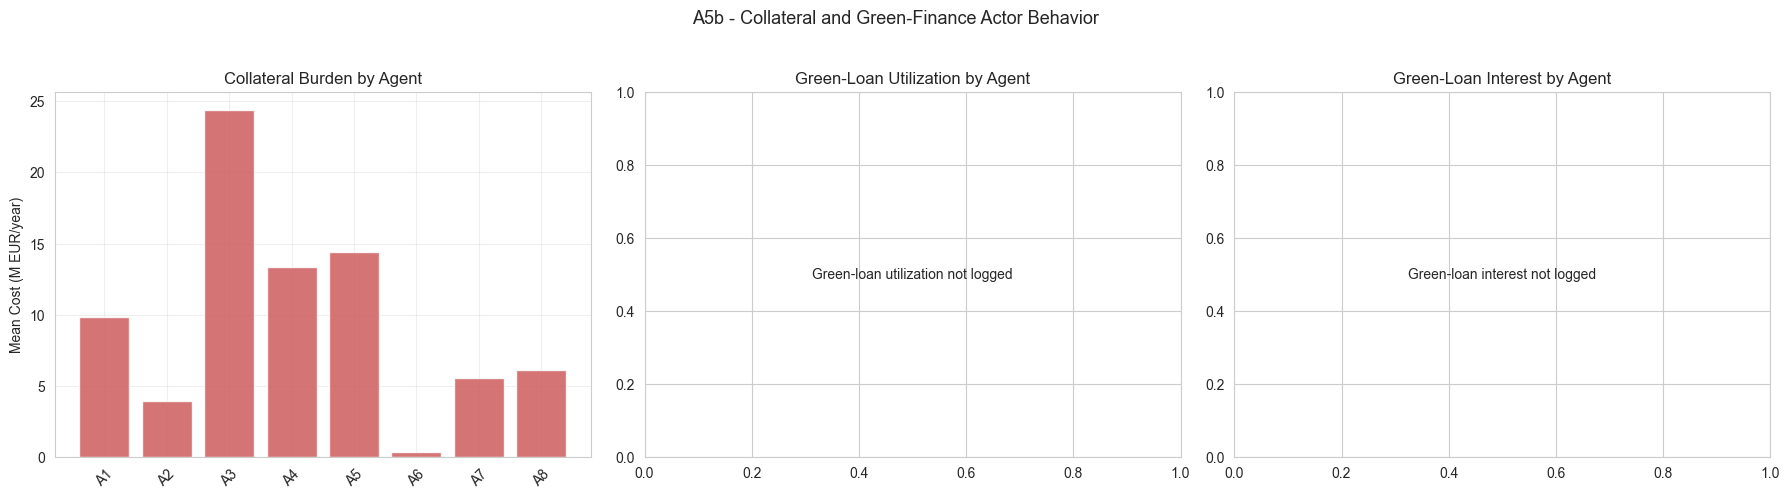

A5B SUMMARY - COLLATERAL AND GREEN-FINANCE ACTOR BEHAVIOR
Top collateral-burden agents:
  A3: 24.3962 M EUR/year
  A5: 14.4230 M EUR/year
  A4: 13.3318 M EUR/year
No green-loan utilization columns found.
No green-loan interest columns found.


In [26]:
import re

if "recent_yr" not in globals():
    raise RuntimeError("Run the 'Load & Prepare Data' cell first.")

def _mean_by_agent(df, prefixes):
    out = {}
    for col in df.columns:
        lower = col.lower()
        if not any(p in lower for p in prefixes):
            continue
        m = re.search(r"_a(\d+)$", lower)
        if not m:
            continue
        aid = int(m.group(1))
        out[aid] = float(pd.to_numeric(df[col], errors="coerce").mean())
    return out

collateral_mean = _mean_by_agent(recent_yr, ["collateral_cost"])
loan_util_mean = _mean_by_agent(recent_yr, ["green_loan_util", "greenloan_util", "green_loan_usage", "green_finance_util"])
loan_interest_mean = _mean_by_agent(recent_yr, ["green_loan_interest", "green_loan_cost", "green_finance_interest"])

if not loan_interest_mean:
    loan_interest_mean = _mean_by_agent(recent_yr, ["loan_interest"])

agent_ids = sorted(set(collateral_mean) | set(loan_util_mean) | set(loan_interest_mean))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

if not agent_ids:
    for ax in axes:
        ax.text(0.5, 0.5, "No collateral/green-finance agent columns found", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
else:
    labels = [f"A{i}" for i in agent_ids]

    ax = axes[0]
    vals = [collateral_mean.get(i, np.nan) for i in agent_ids]
    if np.isfinite(np.array(vals, dtype=float)).any():
        ax.bar(labels, vals, color="indianred", alpha=0.85)
        ax.set_ylabel("Mean Cost (M EUR/year)")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Collateral columns not logged", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Collateral Burden by Agent")

    ax = axes[1]
    vals = [loan_util_mean.get(i, np.nan) for i in agent_ids]
    if np.isfinite(np.array(vals, dtype=float)).any():
        ax.bar(labels, vals, color="seagreen", alpha=0.85)
        ax.set_ylabel("Mean Utilization (M EUR/year)")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Green-loan utilization not logged", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Green-Loan Utilization by Agent")

    ax = axes[2]
    vals = [loan_interest_mean.get(i, np.nan) for i in agent_ids]
    if np.isfinite(np.array(vals, dtype=float)).any():
        ax.bar(labels, vals, color="teal", alpha=0.85)
        ax.set_ylabel("Mean Interest Cost (M EUR/year)")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Green-loan interest not logged", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Green-Loan Interest by Agent")

plt.suptitle("A5b - Collateral and Green-Finance Actor Behavior", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

print("=" * 100)
print("A5B SUMMARY - COLLATERAL AND GREEN-FINANCE ACTOR BEHAVIOR")
print("=" * 100)
if collateral_mean:
    top_coll = sorted(collateral_mean.items(), key=lambda kv: kv[1], reverse=True)[:3]
    print("Top collateral-burden agents:")
    for aid, val in top_coll:
        print(f"  A{aid}: {val:.4f} M EUR/year")
else:
    print("No collateral agent columns found.")

if loan_util_mean:
    active = sum(v > 1e-9 for v in loan_util_mean.values())
    print(f"Agents with non-zero green-loan utilization: {active}/{len(loan_util_mean)}")
else:
    print("No green-loan utilization columns found.")

if loan_interest_mean:
    total_interest = float(np.nansum(list(loan_interest_mean.values())))
    print(f"Total mean green-loan interest across agents: {total_interest:.6f} M EUR/year")
else:
    print("No green-loan interest columns found.")

### A6. Deterministic Evaluation of Best Agents

Load the best checkpoint and run a single deterministic episode to see
learned strategies without exploration noise.

In [27]:
from scripts.train import build_agents

eval_env = ETSEnvironment(config, seed=0)
eval_agents = build_agents(eval_env, config, seed=0)
n_agents = config['companies']['n_agents']
tech_names = config['technologies']['names']

ckpt_dir = 'results/checkpoints_s42'
for i, agent in enumerate(eval_agents):
    ckpt_path = os.path.join(ckpt_dir, f'agent_{i}_best.pt')
    if os.path.exists(ckpt_path):
        agent.load(ckpt_path)
        print(f'Loaded agent {i}')
    else:
        print(f'No checkpoint for agent {i}')

obs1, _ = eval_env.reset(seed=0)
eval_data = []

for year in range(config['simulation']['n_years']):
    auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_auction_action(obs1[i], deterministic=True)
        auction_actions[i] = action
    obs2, _ = eval_env.step_auction(auction_actions)

    secondary_actions = np.zeros((n_agents, 2), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_secondary_action(obs2[i], deterministic=True)
        secondary_actions[i] = action

    obs1, rewards, terminated, _, info = eval_env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price'],
           'secondary_price': log.get('secondary_clearing', 0), 'tnac': log.get('tnac', 0)}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        row[f'alloc_A{i+1}'] = log['allocations'][i]
        row[f'holdings_A{i+1}'] = log['holdings'][i]
        row[f'trade_qty_A{i+1}'] = log['trade_qtys'][i]
        row[f'trade_cost_A{i+1}'] = log['trade_costs'][i]
        row[f'shortfall_A{i+1}'] = log['shortfalls'][i]
        row[f'penalty_A{i+1}'] = log['penalties'][i]
        row[f'reward_A{i+1}'] = log['rewards'][i]
        row[f'invest_cost_A{i+1}'] = log['invest_costs'][i]
        for t in range(5):
            row[f'mix_A{i+1}_{tech_names[t]}'] = log['tech_mixes'][i][t]
    eval_data.append(row)
    if terminated:
        break

eval_df = pd.DataFrame(eval_data)
print(f'Evaluation: {len(eval_df)} years')
print(eval_df[['year', 'cap', 'price', 'tnac']].to_string(index=False))

Market calibration: 8 participants, emissions=20.7 Mt, cap=23.2 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
Loaded agent 0
Loaded agent 1
Loaded agent 2
Loaded agent 3
Loaded agent 4
Loaded agent 5
Loaded agent 6
Loaded agent 7
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.66, A2=1.70, A3=1.66, A4=1.67, A5=1.17, A6=1.09, A7=0.93, A8=0.91
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.78 MtCO2.
Evaluation: 12 years
 year       cap      price      tnac
    0 23.227680 108.878494 10.779678
    1 22.228890  62.984123 16.988943
    2 21.206872  94.546402 23.515195
    3 20.184854 110.231049 25.614919
    4 19.162836 114.477928 24.381437
    5 18.140818 117.774956 22.659065
    6 17.118800 112.804550 21.440738
    7 16.096782 105.957642 20.230940
    8 15.074764 110.124588 19.172839
    9 14.052746 112.501053 15.66

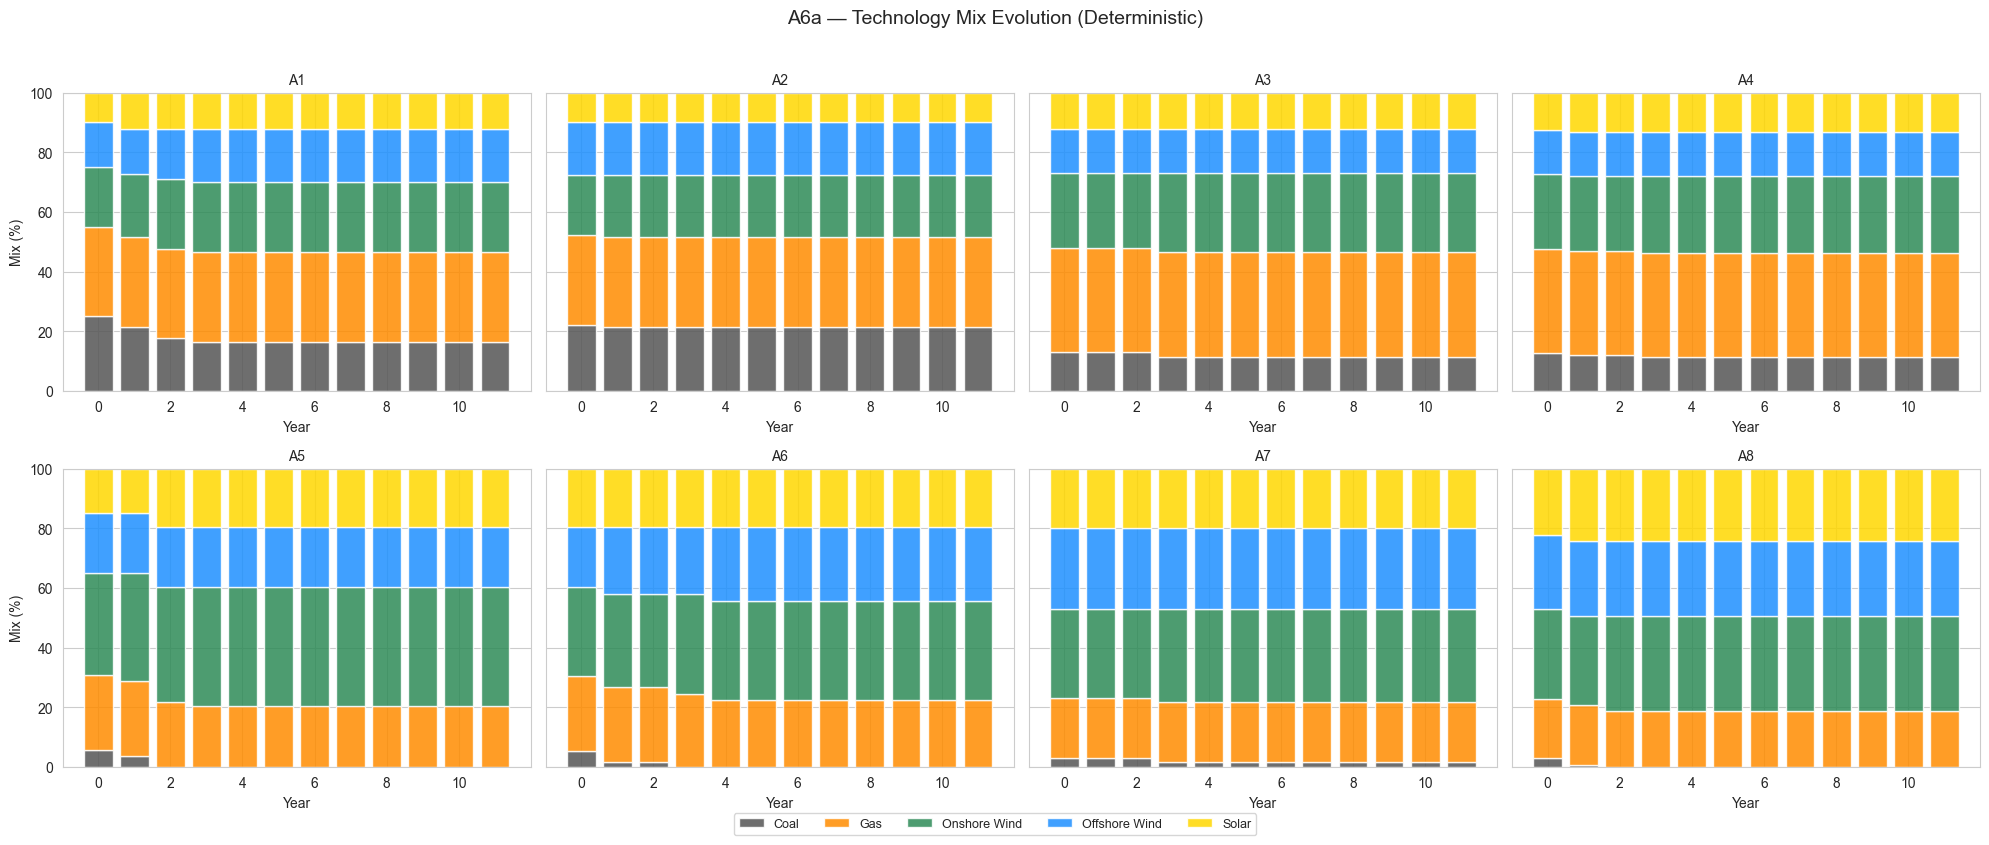

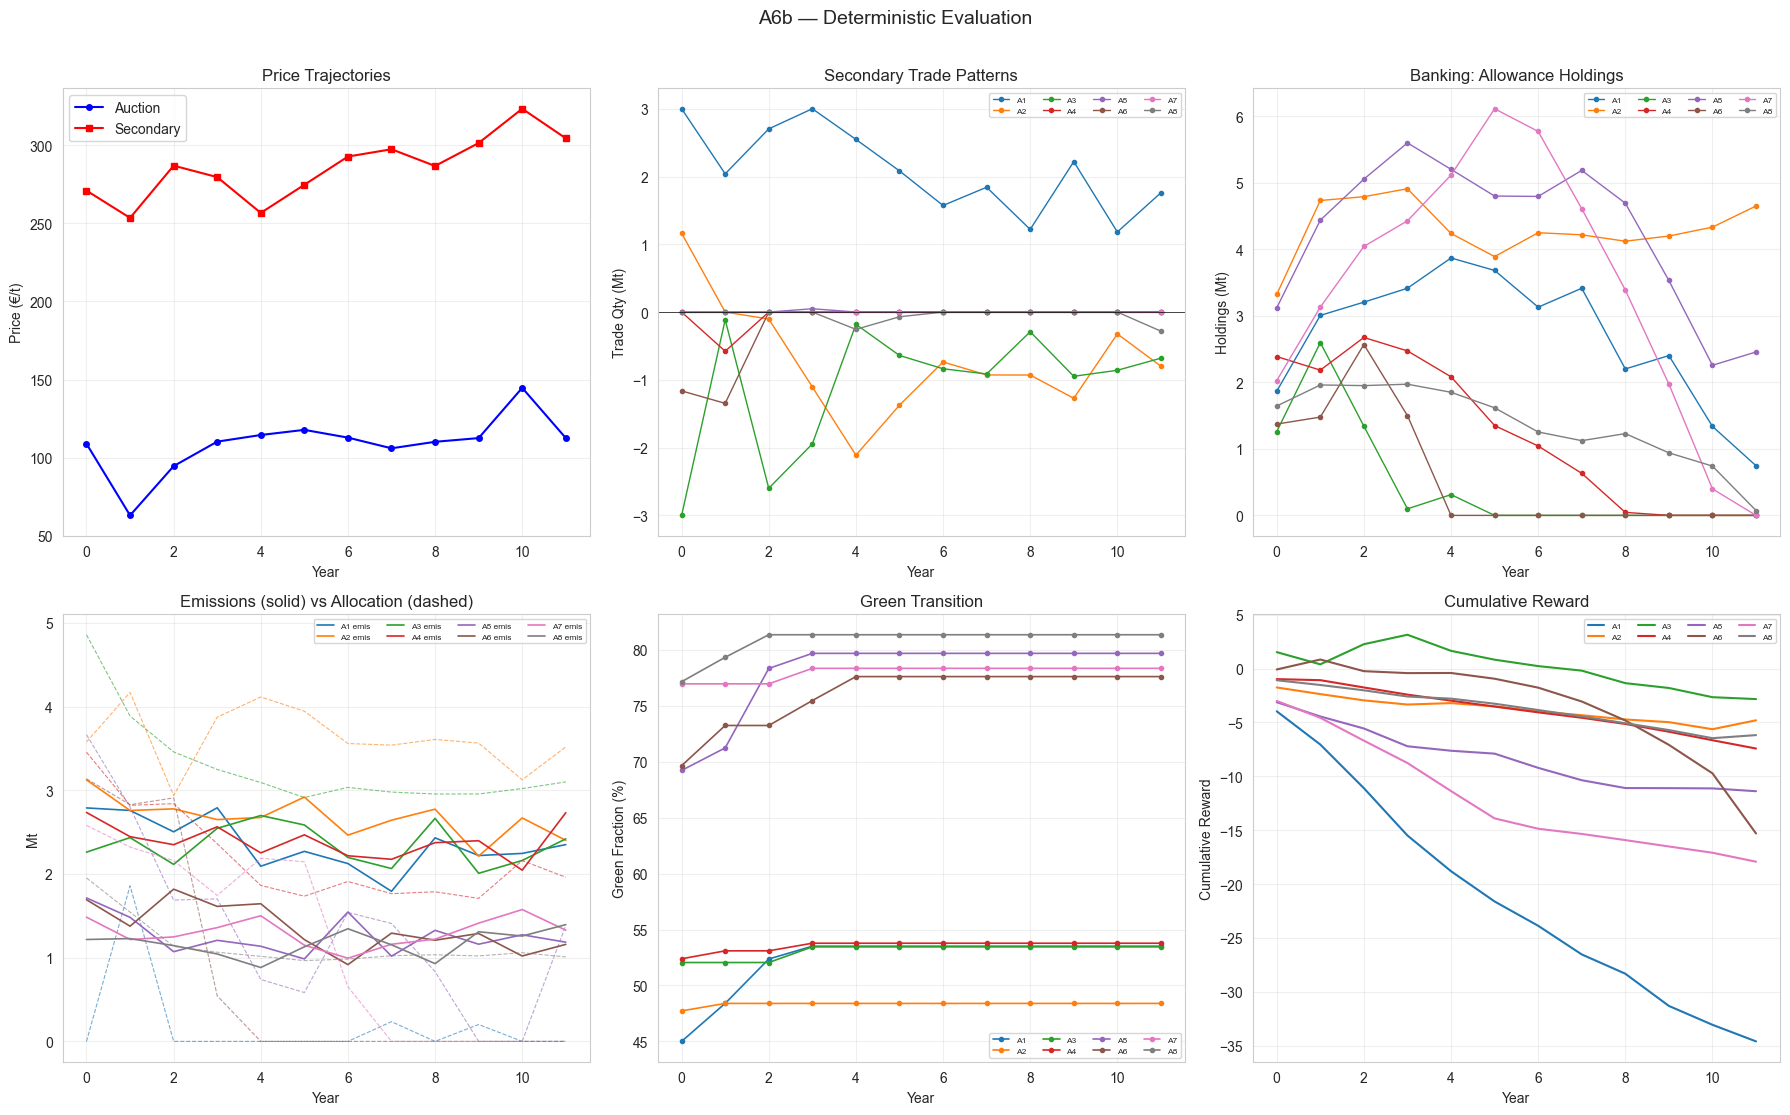

In [28]:
# ── A6 Deterministic Evaluation Plots ─────────────────────────────────
tech_colors = {'coal': '#555555', 'gas': '#FF8C00', 'onshore_wind': '#2E8B57',
               'offshore_wind': '#1E90FF', 'solar': '#FFD700'}

# --- Tech mix: one subplot per agent ---
ncols = min(4, n_agents)
nrows_tech = (n_agents + ncols - 1) // ncols
fig_tech, axes_tech = plt.subplots(nrows_tech, ncols, figsize=(5*ncols, 4*nrows_tech), sharey=True)
axes_tech = np.atleast_1d(axes_tech).flatten()

for i in range(n_agents):
    ax = axes_tech[i]
    bottom_v = np.zeros(len(eval_df))
    for t in range(5):
        vals = eval_df[f'mix_A{i+1}_{tech_names[t]}'].values * 100
        ax.bar(eval_df['year'], vals, bottom=bottom_v,
               color=tech_colors[tech_names[t]], alpha=0.85,
               label=tech_names[t].replace('_', ' ').title())
        bottom_v += vals
    ax.set_title(f'{agent_labels[i]}', fontsize=10)
    ax.set_ylim(0, 100)
    if i % ncols == 0:
        ax.set_ylabel('Mix (%)')
    ax.set_xlabel('Year')

for j in range(n_agents, len(axes_tech)):
    axes_tech[j].set_visible(False)

handles, labels = axes_tech[0].get_legend_handles_labels()
fig_tech.legend(handles, labels, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig_tech.suptitle('A6a — Technology Mix Evolution (Deterministic)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# --- Key strategy plots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Prices
ax = axes[0, 0]
ax.plot(eval_df['year'], eval_df['price'], 'b-o', ms=4, label='Auction', lw=1.5)
ax.plot(eval_df['year'], eval_df['secondary_price'], 'r-s', ms=4, label='Secondary', lw=1.5)
ax.set_xlabel('Year'); ax.set_ylabel('Price (\u20ac/t)')
ax.set_title('Price Trajectories'); ax.legend(); ax.grid(True, alpha=0.3)

# 2 — Trade patterns
ax = axes[0, 1]
for i in range(n_agents):
    ax.plot(eval_df['year'], eval_df[f'trade_qty_A{i+1}'], color=agent_colors[i],
            marker='o', ms=3, lw=1, label=f'A{i+1}')
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Trade Qty (Mt)')
ax.set_title('Secondary Trade Patterns')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Holdings
ax = axes[0, 2]
for i in range(n_agents):
    ax.plot(eval_df['year'], eval_df[f'holdings_A{i+1}'], color=agent_colors[i],
            marker='o', ms=3, lw=1, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Holdings (Mt)')
ax.set_title('Banking: Allowance Holdings')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Emissions vs Allocations
ax = axes[1, 0]
for i in range(n_agents):
    ax.plot(eval_df['year'], eval_df[f'emissions_A{i+1}'], color=agent_colors[i],
            ls='-', lw=1.2, label=f'A{i+1} emis')
    ax.plot(eval_df['year'], eval_df[f'alloc_A{i+1}'], color=agent_colors[i],
            ls='--', lw=0.8, alpha=0.6)
ax.set_xlabel('Year'); ax.set_ylabel('Mt')
ax.set_title('Emissions (solid) vs Allocation (dashed)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Green fraction
ax = axes[1, 1]
for i in range(n_agents):
    ax.plot(eval_df['year'], eval_df[f'green_A{i+1}'] * 100, color=agent_colors[i],
            marker='o', ms=3, lw=1.2, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Green Fraction (%)')
ax.set_title('Green Transition'); ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Cumulative reward
ax = axes[1, 2]
for i in range(n_agents):
    cum_rew = eval_df[f'reward_A{i+1}'].cumsum()
    ax.plot(eval_df['year'], cum_rew, color=agent_colors[i], lw=1.5, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative Reward')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A6b — Deterministic Evaluation', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A7. Learned Agents vs Heuristic Bots (Sanity Check)

This section compares learned agents and heuristic bots directly, and labels each participant by the objective weights used in the environment reward function.

What it reports:

- Per-agent outcomes split by controller (`learned` vs `bot`)
- Objective label from config reward weights (`financial`, `green`, `balanced`)
- Group-level learned-vs-bot head-to-head performance

> Note: if bot columns are absent in your current CSV logs, that means they were not logged in that run. The trainer has now been patched so future runs include all bot metrics.

In [29]:
# ── A7a Behavior-Intent Spreadsheet (bots only: A9-A16) ─────────────────────
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Reuse already loaded logs; fallback to resolved results directory only if needed.
if "ep_df" not in globals() or ep_df is None:
    _rdir = _resolve_results_dir(42) if "_resolve_results_dir" in globals() else Path("results")
    ep_path = Path(_rdir) / "training_log_s42.csv"
    ep_df = pd.read_csv(ep_path) if ep_path.exists() else pd.DataFrame()
if "yr_df" not in globals() or yr_df is None:
    _rdir = _resolve_results_dir(42) if "_resolve_results_dir" in globals() else Path("results")
    yr_path = Path(_rdir) / "year_log_s42.csv"
    yr_df = pd.read_csv(yr_path) if yr_path.exists() else pd.DataFrame()

if ep_df.empty and yr_df.empty:
    print("A7a: No training/year logs found. Skipping behavior-intent spreadsheet.")
    behavior_sheet = pd.DataFrame()
else:
    last_n_local = LAST_N if "LAST_N" in globals() else min(200, max(20, len(ep_df) // 4 if len(ep_df) else 20))

    if not ep_df.empty and "episode" in ep_df.columns:
        recent_eps_local = ep_df["episode"].dropna().unique()[-last_n_local:]
        recent_ep_local = ep_df[ep_df["episode"].isin(recent_eps_local)].copy()
    else:
        recent_ep_local = pd.DataFrame()

    if not yr_df.empty and "episode" in yr_df.columns:
        eps_for_yr = recent_ep_local["episode"].unique() if "episode" in recent_ep_local.columns else yr_df["episode"].dropna().unique()[-last_n_local:]
        recent_yr_local = yr_df[yr_df["episode"].isin(eps_for_yr)].copy()
    else:
        recent_yr_local = pd.DataFrame()

    # Infer number of logged participants from any reward_A* columns (episode log preferred).
    reward_cols_local = []
    if not ep_df.empty:
        reward_cols_local = [c for c in ep_df.columns if c.startswith("reward_A")]
    if (not reward_cols_local) and (not yr_df.empty):
        reward_cols_local = [c for c in yr_df.columns if c.startswith("reward_A")]

    if not reward_cols_local:
        print("A7a: No reward_A* columns found. Cannot infer bot IDs; spreadsheet is empty.")
        behavior_sheet = pd.DataFrame()
    else:
        n_total_local = max(int(c.split("_A")[1]) for c in reward_cols_local)

        bot_ids_target = list(range(9, 17))
        bot_ids_logged = [i for i in bot_ids_target if i <= n_total_local]

        if not bot_ids_logged:
            print("A7a: Bot IDs A9-A16 are not present in this log. Spreadsheet is empty.")
            behavior_sheet = pd.DataFrame()
        else:
            def mean_col(df, col):
                if df.empty or col not in df.columns:
                    return np.nan
                return float(pd.to_numeric(df[col], errors="coerce").mean())

            rows = []
            for i in bot_ids_logged:
                avg_bid_mult = mean_col(recent_ep_local, f"avg_bid_mult_A{i}")
                avg_bid_cov = mean_col(recent_ep_local, f"avg_bid_coverage_A{i}")
                sec_buy_share = mean_col(recent_ep_local, f"sec_buy_intent_share_A{i}")
                sec_sell_share = mean_col(recent_ep_local, f"sec_sell_intent_share_A{i}")

                inv_on = mean_col(recent_ep_local, f"inv_onshore_share_A{i}")
                inv_off = mean_col(recent_ep_local, f"inv_offshore_share_A{i}")
                inv_sol = mean_col(recent_ep_local, f"inv_solar_share_A{i}")

                # Year-level diagnostics from newly added columns (if available).
                bid_to_reserve = mean_col(recent_yr_local, f"bid_to_reserve_A{i}")
                est_need = mean_col(recent_yr_local, f"estimate_need_A{i}")

                # Fallback for coverage if new column is unavailable.
                if pd.isna(avg_bid_cov):
                    alloc_col = f"alloc_A{i}"
                    emis_col = f"emissions_A{i}"
                    if (not recent_yr_local.empty and alloc_col in recent_yr_local.columns and emis_col in recent_yr_local.columns):
                        denom = pd.to_numeric(recent_yr_local[emis_col], errors="coerce").replace(0, np.nan)
                        num = pd.to_numeric(recent_yr_local[alloc_col], errors="coerce")
                        avg_bid_cov = float((num / denom).mean())

                # Human-readable intent labels.
                if pd.notna(sec_buy_share) and pd.notna(sec_sell_share):
                    if sec_buy_share - sec_sell_share > 0.10:
                        sec_intent = "buy-leaning"
                    elif sec_sell_share - sec_buy_share > 0.10:
                        sec_intent = "sell-leaning"
                    else:
                        sec_intent = "balanced/hold"
                else:
                    sec_intent = "n/a"

                tech_shares = {
                    "onshore": inv_on,
                    "offshore": inv_off,
                    "solar": inv_sol,
                }
                if all(pd.isna(v) for v in tech_shares.values()):
                    invest_pref = "n/a"
                else:
                    invest_pref = max(tech_shares.items(), key=lambda kv: (-1 if pd.isna(kv[1]) else kv[1]))[0]

                rows.append({
                    "Agent": f"A{i}",
                    "AgentId": i,
                    "Controller": "bot",
                    "AvgBidMultiplier": avg_bid_mult,
                    "AvgBidCoverage": avg_bid_cov,
                    "BidToReserveRatio": bid_to_reserve,
                    "AvgEstimatedNeedMt": est_need,
                    "SecBuyIntentShare": sec_buy_share,
                    "SecSellIntentShare": sec_sell_share,
                    "SecondaryIntent": sec_intent,
                    "InvestPref": invest_pref,
                    "InvOnshoreShare": inv_on,
                    "InvOffshoreShare": inv_off,
                    "InvSolarShare": inv_sol,
                })

            behavior_sheet = pd.DataFrame(rows)

            print("=" * 110)
            print("A7a BEHAVIOR-INTENT SPREADSHEET (BOTS ONLY: A9-A16)")
            print("=" * 110)

            if behavior_sheet.empty:
                print("No bot rows available for behavior-intent spreadsheet.")
            else:
                display_cols = [
                    "Agent", "Controller", "AvgBidMultiplier", "AvgBidCoverage", "BidToReserveRatio",
                    "AvgEstimatedNeedMt", "SecBuyIntentShare", "SecSellIntentShare",
                    "SecondaryIntent", "InvestPref", "InvOnshoreShare", "InvOffshoreShare", "InvSolarShare"
                ]
                display(
                    behavior_sheet
                    .sort_values("AgentId")
                    .reset_index(drop=True)[display_cols]
                )

                missing_new_ep = [
                    c for c in ["avg_bid_mult_A9", "avg_bid_coverage_A9", "sec_buy_intent_share_A9",
                                "inv_onshore_share_A9", "inv_offshore_share_A9", "inv_solar_share_A9"]
                    if c not in recent_ep_local.columns
                ]
                missing_new_yr = [
                    c for c in ["bid_to_reserve_A9", "estimate_need_A9"]
                    if c not in recent_yr_local.columns
                ]
                if missing_new_ep or missing_new_yr:
                    print("\nNote: Some new behavior columns are missing in this run; fallback values were used where possible.")

A7a: Bot IDs A9-A16 are not present in this log. Spreadsheet is empty.


In [30]:
# ── A7 Learned vs Heuristic Bot Evaluation (single-row bots, actual rewards) ──
import yaml

# Reuse loaded log tables from the common data-loading cell.
if "ep_df" not in globals() or "yr_df" not in globals():
    _rdir = _resolve_results_dir(42) if "_resolve_results_dir" in globals() else Path("results")
    ep_df = pd.read_csv(Path(_rdir) / "training_log_s42.csv")
    yr_df = pd.read_csv(Path(_rdir) / "year_log_s42.csv")

LAST_N = LAST_N if "LAST_N" in globals() else min(200, max(20, len(ep_df) // 4))
recent_eps = ep_df["episode"].unique()[-LAST_N:]
recent_ep = ep_df[ep_df["episode"].isin(recent_eps)].copy()
recent_yr = yr_df[yr_df["episode"].isin(recent_eps)].copy()

reward_cols = sorted([c for c in ep_df.columns if c.startswith("reward_A")], key=lambda c: int(c.split("_A")[1]))
n_total = max([int(c.split("_A")[1]) for c in reward_cols], default=0)

with open(CONFIG_PATH, encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

n_learning_cfg = int(cfg.get("companies", {}).get("n_agents", 8))
n_learning = min(n_learning_cfg, n_total)
n_bot = max(0, n_total - n_learning)

labels = agent_labels if ("agent_labels" in globals() and len(agent_labels) >= n_total) else [f"A{i+1}" for i in range(n_total)]
weights = list(cfg.get("companies", {}).get("reward_weights", [])[:n_learning_cfg])

def obj_label(wf, wg):
    if pd.notna(wf) and pd.notna(wg):
        if wf >= 0.60 and wf > wg:
            return "financial"
        if wg >= 0.60 and wg > wf:
            return "green"
        return "balanced"
    return "unknown"

# Build bot parity templates from learned-agent objectives so bot labels
# match the same learned objective taxonomy for this run.
learned_pairs = []
for idx in range(min(n_learning, len(weights))):
    try:
        learned_pairs.append((float(weights[idx][0]), float(weights[idx][1])))
    except Exception:
        pass

fin_pool = [(a, b) for a, b in learned_pairs if obj_label(a, b) == "financial"]
nonfin_pool = [(a, b) for a, b in learned_pairs if obj_label(a, b) != "financial"]
fin_tpl = tuple(np.mean(fin_pool, axis=0)) if fin_pool else (1.0, 0.0)
nonfin_tpl = tuple(np.mean(nonfin_pool, axis=0)) if nonfin_pool else (0.5, 0.5)

def bot_weights(agent_id):
    # even bot IDs -> learned financial template
    # odd bot IDs -> learned non-financial template
    return fin_tpl if agent_id % 2 == 0 else nonfin_tpl

ep_ix = recent_ep.set_index("episode")
yr_g = recent_yr.groupby("episode")
start_year = int(recent_yr["year"].min()) if len(recent_yr) else 0

def ep_s(col, default=0.0):
    return ep_ix[col] if col in ep_ix.columns else pd.Series(default, index=ep_ix.index.unique())

def yr_s(col, agg="sum", default=0.0):
    if col not in recent_yr.columns:
        return pd.Series(default, index=ep_ix.index.unique())
    g = yr_g[col]
    return g.mean() if agg == "mean" else g.sum()

rows = []
for i in range(1, n_total + 1):
    idx = i - 1
    controller = "learned" if i <= n_learning else "bot"

    if controller == "learned":
        wf, wg = (float(weights[idx][0]), float(weights[idx][1])) if idx < len(weights) else (np.nan, np.nan)
    else:
        wf, wg = bot_weights(i)
    objective = obj_label(wf, wg)

    r = ep_s(f"reward_A{i}")
    g = ep_s(f"green_frac_A{i}")
    p = ep_s(f"penalty_A{i}")
    sf = ep_s(f"shortfall_A{i}")

    net_trade = yr_s(f"trade_qty_A{i}", "sum", 0.0).mean() if f"trade_qty_A{i}" in recent_yr.columns else 0.0
    sec_role = "Net Buyer" if net_trade > 0.1 else ("Net Seller" if net_trade < -0.1 else "Balanced")

    start_green = (
        recent_yr.loc[recent_yr["year"] == start_year, f"green_frac_A{i}"].mean()
        if f"green_frac_A{i}" in recent_yr.columns else np.nan
    )

    rows.append({
        "Agent": labels[idx] if idx < len(labels) else f"A{i}",
        "AgentId": i,
        "Controller": controller,
        "Objective": objective,
        "Weight_financial": wf,
        "Weight_green": wg,
        "MeanReward": float(r.mean()),
        "RewardStd": float(r.std()),
        "AvgGreen": float(g.mean()),
        "StartGreenMix": float(start_green) if pd.notna(start_green) else np.nan,
        "Penalty": float(p.mean()),
        "Shortfall": float(sf.mean()),
        "SecRole": sec_role,
        "SecNet": float(net_trade),
    })

bot_eval_df = pd.DataFrame(rows)
bot_eval_df["Rank"] = bot_eval_df["MeanReward"].rank(ascending=False, method="min").round().astype("Int64")

summary = bot_eval_df.groupby(["Controller", "Objective"])[["MeanReward", "AvgGreen", "StartGreenMix", "Penalty", "Shortfall"]].mean().round(4)

# Head-to-head check (actual logged rewards only)
learned_ids = list(range(1, n_learning + 1))
bot_ids = list(range(n_learning + 1, n_learning + n_bot + 1))
eps_ix = pd.Index(recent_ep["episode"].drop_duplicates(), name="episode")

def avg_reward(ids):
    if not ids:
        return pd.Series(np.nan, index=eps_ix)
    cols = [f"reward_A{i}" for i in ids if f"reward_A{i}" in recent_ep.columns]
    if not cols:
        return pd.Series(np.nan, index=eps_ix)
    return recent_ep.set_index("episode")[cols].reindex(eps_ix).fillna(0).mean(axis=1)

h2h = pd.DataFrame({"learned": avg_reward(learned_ids), "bot": avg_reward(bot_ids)}).dropna()
win_rate = float((h2h["learned"] > h2h["bot"]).mean()) if len(h2h) else np.nan
gap = float((h2h["learned"] - h2h["bot"]).mean()) if len(h2h) else np.nan

print("=" * 100)
print("A7 LEARNED VS HEURISTIC BOTS (CONVERGED WINDOW)")
print("=" * 100)
print(f"Agents in logs: {n_total} | Learned: {n_learning} | Bots: {n_bot} | Start year used for mix: {start_year}")
print("Bot objective rule: even bot IDs = learned financial template, odd bot IDs = learned non-financial template.")
print(f"Learned templates: financial={tuple(round(float(x), 3) for x in fin_tpl)}, non-financial={tuple(round(float(x), 3) for x in nonfin_tpl)}")

display_cols = ["Rank", "Agent", "Controller", "Objective", "MeanReward", "StartGreenMix", "AvgGreen", "RewardStd", "Penalty", "Shortfall", "SecRole"]

# Abbreviate long values in rows while keeping headers descriptive.
tbl = bot_eval_df[display_cols].copy()
tbl["Controller"] = tbl["Controller"].map({"learned": "Lrn", "bot": "Bot"}).fillna(tbl["Controller"])
tbl["Objective"] = tbl["Objective"].map({
    "financial": "Fin",
    "green": "Green",
    "balanced": "Bal",
    "unknown": "Unk"
}).fillna(tbl["Objective"])
tbl["SecRole"] = tbl["SecRole"].map({"Net Buyer": "N-Buy", "Net Seller": "N-Sell", "Balanced": "Bal"}).fillna(tbl["SecRole"])

table_headers = {
    "StartGreenMix": "Start Green Mix",
    "MeanReward": "Mean Reward",
    "AvgGreen": "Avg Green",
    "RewardStd": "Reward Std",
    "SecRole": "Secondary Role"
}

print("\nPer-agent table (cleaned; sorted by MeanReward):")
print(
    tbl.sort_values(["MeanReward", "Rank"], ascending=[False, True])
    .rename(columns=table_headers)
    .to_string(index=False, float_format=lambda x: f"{x:,.3f}")
)

print("\nGroup means:")
print(summary.to_string())

print("\nHead-to-head (episode average, actual rewards):")
print(f"- Learned win rate: {win_rate*100:.1f}%" if pd.notna(win_rate) else "- Learned win rate: n/a")
print(f"- Mean reward gap (learned - bots): {gap:+.3f}" if pd.notna(gap) else "- Mean reward gap: n/a")

A7 LEARNED VS HEURISTIC BOTS (CONVERGED WINDOW)
Agents in logs: 8 | Learned: 8 | Bots: 0 | Start year used for mix: 0
Bot objective rule: even bot IDs = learned financial template, odd bot IDs = learned non-financial template.
Learned templates: financial=(1.0, 0.0), non-financial=(0.5, 0.5)

Per-agent table (cleaned; sorted by MeanReward):
 Rank Agent Controller Objective  Mean Reward  Start Green Mix  Avg Green  Reward Std   Penalty  Shortfall Secondary Role
    1    A3        Lrn       Fin       13.268            0.525      0.627       9.459    11.499      0.070         N-Sell
    2    A5        Lrn       Fin        1.931            0.678      0.731       8.591   246.709      1.481         N-Sell
    3    A8        Lrn       Bal       -0.046            0.779      0.900       5.891   703.427      4.172         N-Sell
    4    A4        Lrn       Bal       -6.476            0.524      0.576       2.112   298.854      1.760         N-Sell
    5    A2        Lrn       Bal      -11.521  

### Summary Statistics

Key metrics for thesis reporting.

In [31]:
print('=' * 90)
print('TRAINING SUMMARY (converged: last {} episodes)'.format(LAST_N))
print('=' * 90)

# Per-agent summary
rows = []
for i in range(n_agents):
    row = {
        'Agent': agent_labels[i],
        'Reward': f"{recent_ep[f'reward_A{i+1}'].mean():.1f} \u00b1 {recent_ep[f'reward_A{i+1}'].std():.1f}",
        'Green%': f"{recent_ep[f'green_frac_A{i+1}'].mean()*100:.1f}%",
        'Penalty': f"{recent_ep[f'penalty_A{i+1}'].mean():.2f}",
        'Shortfall': f"{recent_ep[f'shortfall_A{i+1}'].mean():.3f}",
        'BidPrice': f"{recent_ep[f'bid_price_A{i+1}'].mean():.0f}\u20ac",
    }
    # Secondary market role
    net_trade = recent_yr[recent_yr['episode'].isin(last_episodes)].groupby('episode')[f'trade_qty_A{i+1}'].sum()
    mean_net = net_trade.mean()
    row['SecRole'] = 'Buyer' if mean_net > 0.1 else 'Seller' if mean_net < -0.1 else 'Balanced'
    row['SecNetMt'] = f"{mean_net:+.2f}"
    rows.append(row)

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

print()
print(f"Mean clearing price (last year): {recent_ep['clearing_price_last'].mean():.1f} \u00b1 {recent_ep['clearing_price_last'].std():.1f} \u20ac/t")
print(f"Secondary match rate:            {recent_ep['secondary_match_rate'].mean()*100:.0f}%")
print(f"Secondary volume:                {recent_ep['secondary_volume'].mean():.1f} Mt/ep")
print(f"Mean system reward:              {recent_ep[[f'reward_A{i+1}' for i in range(n_agents)]].sum(axis=1).mean():.1f}")

TRAINING SUMMARY (converged: last 200 episodes)
Agent      Reward Green% Penalty Shortfall BidPrice  SecRole SecNetMt
   A1 -27.2 ± 3.5  52.6%   20.64     0.133     240€    Buyer   +13.70
   A2 -11.5 ± 2.6  52.6%   38.62     0.225      67€    Buyer   +15.67
   A3  13.3 ± 9.5  62.7%   11.50     0.070     230€   Seller   -25.69
   A4  -6.5 ± 2.1  57.6%  298.85     1.760     241€   Seller    -0.17
   A5   1.9 ± 8.6  73.1%  246.71     1.481     243€   Seller   -11.10
   A6 -16.9 ± 3.5  73.6%  333.93     1.984      49€    Buyer   +12.70
   A7 -12.5 ± 3.5  83.2% 1556.19     9.826     236€ Balanced    +0.10
   A8  -0.0 ± 5.9  90.0%  703.43     4.172     149€   Seller    -5.20

Mean clearing price (last year): 93.9 ± 64.1 €/t
Secondary match rate:            95%
Secondary volume:                53.2 Mt/ep
Mean system reward:              -59.5


### Final Troubleshooting Digest

High-detail, JSON-first troubleshooting summary aligned to the current v6.0 setup: 8 learning agents + 8 heuristic bots, inflation-aware penalties/costs, carry-forward compliance, and terminal value rewards.

This block includes config consistency checks, inflation-path diagnostics (from yearly logs), market microstructure checks, learned-vs-bot comparisons, and warning telemetry prioritization.

In [32]:
# ── Final Troubleshooting Digest (v6.0, expanded for handoff) ──────────────────
import json
from pathlib import Path
import numpy as np
import pandas as pd
import yaml

# Reuse already-loaded globals when available.
if "ep_df" not in globals() or "yr_df" not in globals():
    seed = int(globals().get("SEED", 42))
    _rdir = _resolve_results_dir(seed) if "_resolve_results_dir" in globals() else Path("results")
    ep_df = pd.read_csv(Path(_rdir) / f"training_log_s{seed}.csv")
    yr_df = pd.read_csv(Path(_rdir) / f"year_log_s{seed}.csv")
if "config" not in globals():
    with open(CONFIG_PATH, encoding="utf-8") as f:
        config = yaml.safe_load(f)

def _safe_mean(df, col):
    return float(pd.to_numeric(df[col], errors="coerce").mean()) if col in df.columns else np.nan

def _safe_std(df, col):
    return float(pd.to_numeric(df[col], errors="coerce").std()) if col in df.columns else np.nan

def _role_from_net(net):
    if pd.isna(net):
        return "unknown"
    if net > 0.10:
        return "net_buyer"
    if net < -0.10:
        return "net_seller"
    return "balanced"

def _objective_from_weights(wf, wg):
    if pd.isna(wf) or pd.isna(wg):
        return "unknown"
    if wf >= 0.60 and wf > wg:
        return "financial"
    if wg >= 0.60 and wg > wf:
        return "green"
    return "balanced"

# Window selection
episodes_total = int(ep_df["episode"].nunique()) if "episode" in ep_df.columns else 0
last_n_default = min(200, max(20, episodes_total // 4 if episodes_total else 20))
last_n = int(globals().get("LAST_N", last_n_default))
last_eps = ep_df["episode"].dropna().unique()[-last_n:] if "episode" in ep_df.columns else np.array([])
recent_ep = ep_df[ep_df["episode"].isin(last_eps)].copy() if len(last_eps) else ep_df.copy()
recent_yr = yr_df[yr_df["episode"].isin(last_eps)].copy() if (len(last_eps) and "episode" in yr_df.columns) else yr_df.copy()

latest_ep_id = int(ep_df["episode"].dropna().max()) if "episode" in ep_df.columns and len(ep_df) else None
latest_ep_years = yr_df[yr_df["episode"] == latest_ep_id].copy() if (latest_ep_id is not None and "episode" in yr_df.columns) else pd.DataFrame()

# Participant dimensions
n_learning_cfg = int(config.get("companies", {}).get("n_agents", 0))
n_bot_cfg = int(config.get("companies", {}).get("n_bot_agents", 0))
n_total_cfg = n_learning_cfg + n_bot_cfg

reward_cols = sorted([c for c in ep_df.columns if c.startswith("reward_A")], key=lambda c: int(c.split("_A")[1]))
n_total_logged = max(int(c.split("_A")[1]) for c in reward_cols) if reward_cols else 0

# Infer reward weights for learned agents if present
weights_cfg = config.get("companies", {}).get("reward_weights", [])
parsed_weights = []
for w in weights_cfg[:n_learning_cfg]:
    try:
        parsed_weights.append((float(w[0]), float(w[1])))
    except Exception:
        parsed_weights.append((np.nan, np.nan))

# Build per-agent summaries from converged window
agent_rows = []
for i in range(1, n_total_logged + 1):
    idx = i - 1
    controller = "learned" if i <= n_learning_cfg else "bot"

    if controller == "learned" and idx < len(parsed_weights):
        wf, wg = parsed_weights[idx]
    else:
        wf, wg = (np.nan, np.nan)
    objective = _objective_from_weights(wf, wg)

    r_col = f"reward_A{i}"
    g_col = f"green_frac_A{i}"
    p_col = f"penalty_A{i}"
    s_col = f"shortfall_A{i}"
    b_col = f"bid_price_A{i}"
    bm_col = f"avg_bid_mult_A{i}"
    bc_col = f"avg_bid_coverage_A{i}"
    buy_i_col = f"sec_buy_intent_share_A{i}"
    sell_i_col = f"sec_sell_intent_share_A{i}"
    inv_on_col = f"inv_onshore_share_A{i}"
    inv_off_col = f"inv_offshore_share_A{i}"
    inv_sol_col = f"inv_solar_share_A{i}"

    trade_col = f"trade_qty_A{i}"
    if not recent_yr.empty and trade_col in recent_yr.columns and "episode" in recent_yr.columns:
        net_ep = recent_yr.groupby("episode")[trade_col].sum()
        sec_net_mean = float(pd.to_numeric(net_ep, errors="coerce").mean())
    else:
        sec_net_mean = np.nan

    inv_on = _safe_mean(recent_ep, inv_on_col)
    inv_off = _safe_mean(recent_ep, inv_off_col)
    inv_sol = _safe_mean(recent_ep, inv_sol_col)
    inv_pref = "unknown"
    inv_map = {"onshore": inv_on, "offshore": inv_off, "solar": inv_sol}
    valid_inv = {k: v for k, v in inv_map.items() if pd.notna(v)}
    if valid_inv:
        inv_pref = max(valid_inv.items(), key=lambda kv: kv[1])[0]

    agent_rows.append({
        "agent": f"A{i}",
        "agent_id": i,
        "controller": controller,
        "objective": objective,
        "weight_financial": None if pd.isna(wf) else float(wf),
        "weight_green": None if pd.isna(wg) else float(wg),
        "reward_mean": _safe_mean(recent_ep, r_col),
        "reward_std": _safe_std(recent_ep, r_col),
        "green_frac_mean": _safe_mean(recent_ep, g_col),
        "penalty_mean": _safe_mean(recent_ep, p_col),
        "shortfall_mean": _safe_mean(recent_ep, s_col),
        "bid_price_mean": _safe_mean(recent_ep, b_col),
        "bid_mult_mean": _safe_mean(recent_ep, bm_col),
        "bid_coverage_mean": _safe_mean(recent_ep, bc_col),
        "sec_buy_intent_mean": _safe_mean(recent_ep, buy_i_col),
        "sec_sell_intent_mean": _safe_mean(recent_ep, sell_i_col),
        "sec_net_mt_mean": sec_net_mean,
        "sec_role": _role_from_net(sec_net_mean),
        "invest_pref": inv_pref,
        "inv_onshore_mean": inv_on,
        "inv_offshore_mean": inv_off,
        "inv_solar_mean": inv_sol,
    })

agent_df = pd.DataFrame(agent_rows) if agent_rows else pd.DataFrame()

def _group_summary(df, controller):
    if df.empty:
        return {}
    g = df[df["controller"] == controller]
    if g.empty:
        return {}
    out = {
        "n_agents": int(len(g)),
        "reward_mean": float(pd.to_numeric(g["reward_mean"], errors="coerce").mean()),
        "green_frac_mean": float(pd.to_numeric(g["green_frac_mean"], errors="coerce").mean()),
        "penalty_mean": float(pd.to_numeric(g["penalty_mean"], errors="coerce").mean()),
        "shortfall_mean": float(pd.to_numeric(g["shortfall_mean"], errors="coerce").mean()),
        "bid_price_mean": float(pd.to_numeric(g["bid_price_mean"], errors="coerce").mean()),
        "bid_mult_mean": float(pd.to_numeric(g["bid_mult_mean"], errors="coerce").mean()),
        "bid_coverage_mean": float(pd.to_numeric(g["bid_coverage_mean"], errors="coerce").mean()),
        "sec_buy_intent_mean": float(pd.to_numeric(g["sec_buy_intent_mean"], errors="coerce").mean()),
        "sec_sell_intent_mean": float(pd.to_numeric(g["sec_sell_intent_mean"], errors="coerce").mean()),
        "sec_net_mt_mean": float(pd.to_numeric(g["sec_net_mt_mean"], errors="coerce").mean()),
        "inv_onshore_mean": float(pd.to_numeric(g["inv_onshore_mean"], errors="coerce").mean()),
        "inv_offshore_mean": float(pd.to_numeric(g["inv_offshore_mean"], errors="coerce").mean()),
        "inv_solar_mean": float(pd.to_numeric(g["inv_solar_mean"], errors="coerce").mean()),
    }
    return out

learned_group = _group_summary(agent_df, "learned")
bot_group = _group_summary(agent_df, "bot")

# Market-level by-year profile (window average by year index)
year_profile = []
if not recent_yr.empty and "year" in recent_yr.columns:
    ygrp = recent_yr.groupby("year")
    for y, block in ygrp:
        emiss_cols = [c for c in block.columns if c.startswith("emissions_A")]
        trade_cols = [c for c in block.columns if c.startswith("trade_qty_A")]

        if emiss_cols:
            emiss_num = block[emiss_cols].apply(pd.to_numeric, errors="coerce")
            total_emissions_mean = float(emiss_num.sum(axis=1).mean())
        else:
            total_emissions_mean = np.nan

        if trade_cols:
            trade_num = block[trade_cols].apply(pd.to_numeric, errors="coerce")
            secondary_abs_flow_mean = float(trade_num.abs().sum(axis=1).mean())
        else:
            secondary_abs_flow_mean = np.nan

        year_profile.append({
            "year": int(y),
            "clearing_price_mean": _safe_mean(block, "clearing_price"),
            "secondary_price_mean": _safe_mean(block, "secondary_price"),
            "cap_mean": _safe_mean(block, "cap"),
            "auction_volume_mean": _safe_mean(block, "auction_volume"),
            "tnac_mean": _safe_mean(block, "tnac"),
            "total_emissions_mean": total_emissions_mean,
            "secondary_abs_flow_mean": secondary_abs_flow_mean,
        })

# Latest episode path snapshot
latest_episode = {}
if not latest_ep_years.empty:
    price_path = pd.to_numeric(latest_ep_years.get("clearing_price", pd.Series(dtype=float)), errors="coerce").tolist()
    sec_price_path = pd.to_numeric(latest_ep_years.get("secondary_price", pd.Series(dtype=float)), errors="coerce").tolist()
    tnac_path = pd.to_numeric(latest_ep_years.get("tnac", pd.Series(dtype=float)), errors="coerce").tolist()
    auc_path = pd.to_numeric(latest_ep_years.get("auction_volume", pd.Series(dtype=float)), errors="coerce").tolist()
    latest_episode = {
        "episode": latest_ep_id,
        "n_years": int(len(latest_ep_years)),
        "clearing_price_path": [None if pd.isna(x) else float(x) for x in price_path],
        "secondary_price_path": [None if pd.isna(x) else float(x) for x in sec_price_path],
        "tnac_path": [None if pd.isna(x) else float(x) for x in tnac_path],
        "auction_volume_path": [None if pd.isna(x) else float(x) for x in auc_path],
        "price_start": None if not price_path else float(price_path[0]),
        "price_end": None if not price_path else float(price_path[-1]),
        "price_peak": None if not price_path else float(np.nanmax(price_path)),
        "tnac_end": None if not tnac_path else float(tnac_path[-1]),
    }

# Warning telemetry
warn_cols = [c for c in recent_ep.columns if c.startswith("warn_")]
warning_summary = {"available": False, "top": [], "totals": {}}
if warn_cols:
    totals = {c: int(pd.to_numeric(recent_ep[c], errors="coerce").fillna(0).sum()) for c in warn_cols}
    top = sorted(totals.items(), key=lambda kv: kv[1], reverse=True)[:12]
    warning_summary = {
        "available": True,
        "top": [{"warning": k, "count": v} for k, v in top],
        "totals": totals,
    }

# System metrics
reward_cols_recent = [f"reward_A{i}" for i in range(1, n_total_logged + 1) if f"reward_A{i}" in recent_ep.columns]
system_reward_series = recent_ep[reward_cols_recent].apply(pd.to_numeric, errors="coerce").sum(axis=1) if reward_cols_recent else pd.Series(dtype=float)

core_metrics = {
    "clearing_price_mean": _safe_mean(recent_ep, "clearing_price_last"),
    "clearing_price_std": _safe_std(recent_ep, "clearing_price_last"),
    "secondary_match_rate_mean": _safe_mean(recent_ep, "secondary_match_rate"),
    "secondary_volume_mean": _safe_mean(recent_ep, "secondary_volume"),
    "secondary_avg_price_mean": _safe_mean(recent_ep, "secondary_avg_price"),
    "entropy_coef_mean": _safe_mean(recent_ep, "entropy_coef"),
    "shaping_weight_mean": _safe_mean(recent_ep, "shaping_weight"),
    "epsilon_mean": _safe_mean(recent_ep, "epsilon"),
    "system_reward_mean": float(system_reward_series.mean()) if len(system_reward_series) else np.nan,
    "system_reward_std": float(system_reward_series.std()) if len(system_reward_series) else np.nan,
}

# Key findings for quick handoff
findings = []
if n_total_cfg > 0 and n_total_logged != n_total_cfg:
    findings.append("Logged participant count differs from config total (n_agents + n_bot_agents).")
if pd.notna(core_metrics["secondary_match_rate_mean"]) and core_metrics["secondary_match_rate_mean"] < 0.15:
    findings.append("Secondary market matching is very low (<15% years with trades).")
if pd.notna(core_metrics["clearing_price_std"]) and core_metrics["clearing_price_std"] > 60:
    findings.append("Clearing prices remain highly volatile in the convergence window.")
if warning_summary["available"] and warning_summary["top"] and warning_summary["top"][0]["count"] > 0:
    findings.append(f"Most frequent warning: {warning_summary['top'][0]['warning']} ({warning_summary['top'][0]['count']} occurrences).")
if agent_df.empty:
    findings.append("No per-agent rows could be constructed from the current logs.")
if not findings:
    findings.append("No critical red flags from automated diagnostics; behavior appears internally consistent.")

report = {
    "report_version": "v6.0-expanded-handoff",
    "generated_for": "AI-agent-handoff",
    "run_scope": {
        "episodes_total": episodes_total,
        "episodes_window_used": int(last_n),
        "latest_episode": latest_ep_id,
        "results_dir": str(globals().get("RESULTS_DIR", "unknown")),
    },
    "config_snapshot": {
        "n_learning_agents": n_learning_cfg,
        "n_bot_agents": n_bot_cfg,
        "n_total_configured": n_total_cfg,
        "n_total_logged": n_total_logged,
        "n_years": int(config.get("simulation", {}).get("n_years", 0)),
        "reserve_price": float(config.get("ets", {}).get("reserve_price", np.nan)),
        "auction_price_min": float(config.get("auction", {}).get("price_min", np.nan)),
        "auction_price_max": float(config.get("auction", {}).get("price_max", np.nan)),
        "secondary_price_min": float(config.get("trading", {}).get("sec_price_min", np.nan)),
        "secondary_price_max_mult": float(config.get("trading", {}).get("sec_price_max_mult", np.nan)),
        "penalty_rate": float(config.get("penalty", {}).get("rate", np.nan)),
        "penalty_inflation_rate": float(config.get("penalty", {}).get("inflation_rate", np.nan)),
    },
    "core_metrics": core_metrics,
    "warnings": warning_summary,
    "group_summary": {
        "learned": learned_group,
        "bots": bot_group,
    },
    "participant_summary": agent_rows,
    "year_profile_window_mean": year_profile,
    "latest_episode_path": latest_episode,
    "key_findings": findings,
}

print("=" * 120)
print("FINAL TROUBLESHOOTING DIGEST (v6.0, EXPANDED HANDOFF)")
print("=" * 120)
print(json.dumps(report, indent=2))
print("=" * 120)

if not agent_df.empty:
    top_agents = agent_df.sort_values("reward_mean", ascending=False).head(5)[["agent", "controller", "reward_mean", "green_frac_mean", "sec_role"]]
    print("Top 5 agents by mean reward (window):")
    print(top_agents.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))
    print("-" * 120)
print("Handoff digest complete.")

FINAL TROUBLESHOOTING DIGEST (v6.0, EXPANDED HANDOFF)
{
  "report_version": "v6.0-expanded-handoff",
  "generated_for": "AI-agent-handoff",
  "run_scope": {
    "episodes_total": 70000,
    "episodes_window_used": 200,
    "latest_episode": 69999,
    "results_dir": "C:\\Users\\danie\\Documents\\Python_Scripts\\Master Thesis\\Thesis-Energy-Auction\\results"
  },
  "config_snapshot": {
    "n_learning_agents": 8,
    "n_bot_agents": 0,
    "n_total_configured": 8,
    "n_total_logged": 8,
    "n_years": 12,
    "reserve_price": 45.0,
    "auction_price_min": 45.0,
    "auction_price_max": 250.0,
    "secondary_price_min": 45.0,
    "secondary_price_max_mult": 2.0,
    "penalty_rate": 138.75,
    "penalty_inflation_rate": 0.02
  },
  "core_metrics": {
    "clearing_price_mean": 93.9486918258667,
    "clearing_price_std": 64.13708564684309,
    "secondary_match_rate_mean": 0.946755,
    "secondary_volume_mean": 53.169356,
    "secondary_avg_price_mean": 306.4484,
    "entropy_coef_mean": 